In [1]:
import astropy
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from itables import show
import pprint

import itertools
from multiprocess import Pool
import multiprocess
from multiprocess import Manager
from threading import Thread

import os
import re
from tqdm import tqdm
from tqdm.contrib.concurrent import process_map  # or thread_map
import numpy as np
from scipy.interpolate import interp1d
# # from scipy.optimize import UnivariateSpline
from scipy.interpolate import interp1d, UnivariateSpline
import matplotlib.pyplot as plt
from astropy.io import fits
from FitsClass import FITSFile as myfits
from ObservationClass import ObservationManager as obsm
from SimulationClass import Simulations as sc

import specs as specs
from CCF import CCFclass

obs = obsm()

In [21]:
for i, star_name in enumerate(specs.star_names):
    print(f'{i} is {star_name}')

0 is Brey  70
1 is Brey  83
2 is HD  38029
3 is HD  37248
4 is Brey  95a
5 is MNM2014 LMC195-1
6 is HD  32125
7 is HD  37026
8 is HD 269818
9 is HD  38448
10 is HD  38030
11 is HD  37680
12 is Brey  58a
13 is HD  32228
14 is HD  32257
15 is HD 269888
16 is HD  36156
17 is H2013 LMCe  584
18 is RMC 140
19 is HD  32402
20 is Brey  70a
21 is Brey  16a
22 is Brey  93
23 is Brey  90a
24 is HD 269891


# Plotting spectra

## Plotting X-Shooter full spectra

In [3]:
obs = obsm()
star_name = specs.star_names[12]
print(f'I am working on {star_name}')
star = obs.load_star_instance(star_name)

I am working on Brey  58a


Data loaded from Data/Brey  58a/epoch3/COMBINED/combined_bands.fits


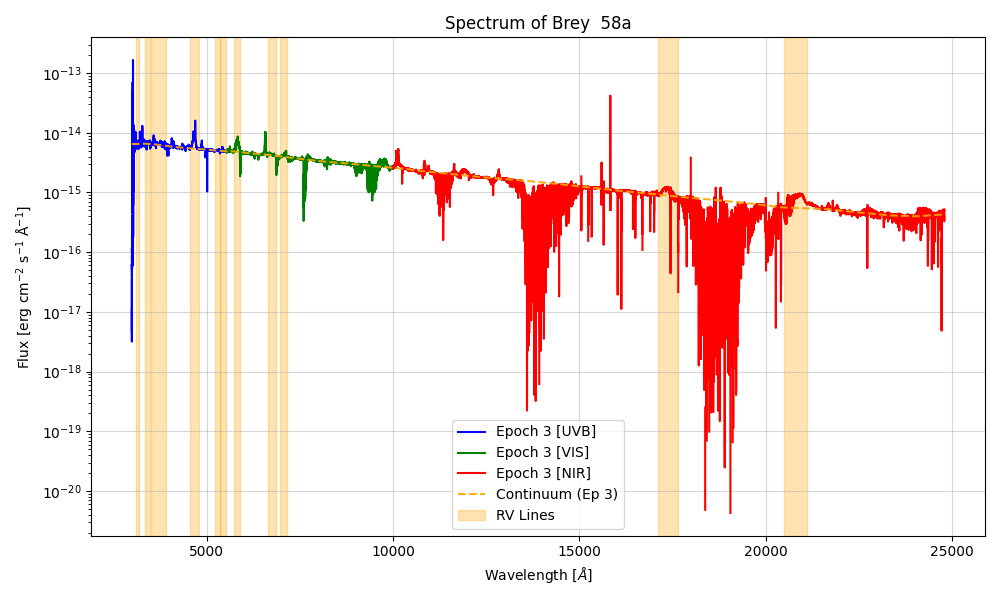

In [4]:
%matplotlib widget
# star.plot_spectra([3],['UVB','VIS','NIR'],normalize=False,Rest_frame=False)
star.plot_spectra([3],['COMBINED'],normalize=False,Rest_frame=False,color_combined=True,log=True,add_continuum=True,add_RV_emission_lines=True)


## Plotting normalizied spectra

In [5]:
import matplotlib
matplotlib.get_backend()


'widget'

HD  36156


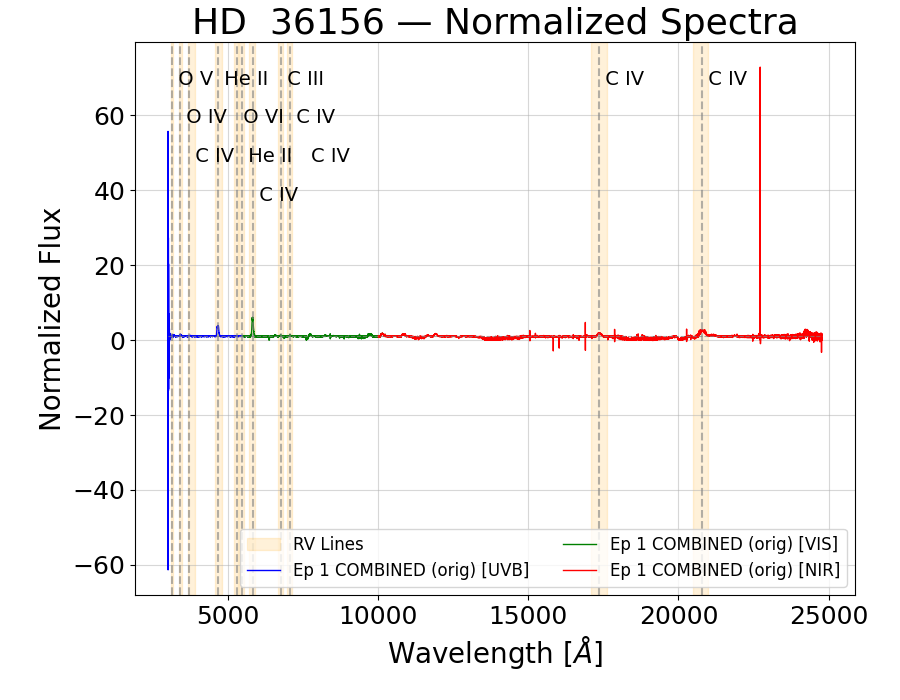

In [3]:
%matplotlib widget
star_name = specs.star_names[16]
print(star_name)
star = obs.load_star_instance(star_name)
epoch_nums = [1,2,3,5,6]
epoch_nums = [1]
# epoch_nums = None
EL_annotate = [5808]
EL_annotate=True
star.plot_normalized_spectra(bands = 'COMBINED',compare=False,separation=0,bin_window=0,bary_correction=False,epoch_nums=epoch_nums,add_RV_emission_lines=True,
                             color_combined=True, add_continuum=True,for_presentation=True,EL_annotate=EL_annotate,separate=False)
# star.plot_normalized_spectrum(3,['UVB','VIS','NIR'])

Brey  83


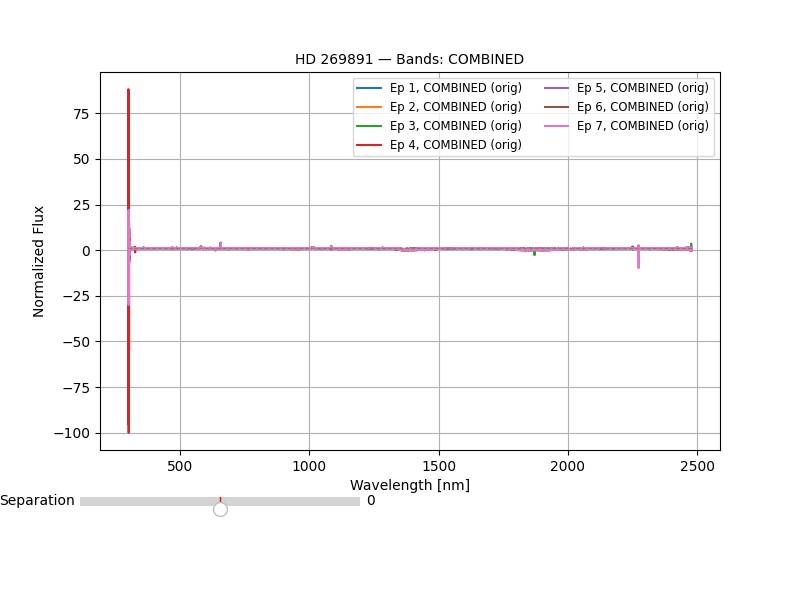

In [23]:
star_name = specs.star_names[1]
print(star_name)
star = obs.load_star_instance(star_name)
flux1 = star.load_property(epoch_num=1,band='COMBINED',property_name='cleaned_normalized_flux')['normalized_flux']
flux2 = star.load_property(epoch_num=2,band='COMBINED',property_name='cleaned_normalized_flux')['normalized_flux']
wave = star.load_property(epoch_num=1,band='COMBINED',property_name='cleaned_normalized_flux')['wavelengths']


window1 = flux1[(575 < wave)& (wave <595)]
window2 = flux2[(575 < wave)& (wave <595)]

plt.scatter(window1, window2)
plt.show()

Brey  70
No file or folder named 'cleaned_normalized_flux' found in 'Data/Brey  70/epoch1/COMBINED/output'.


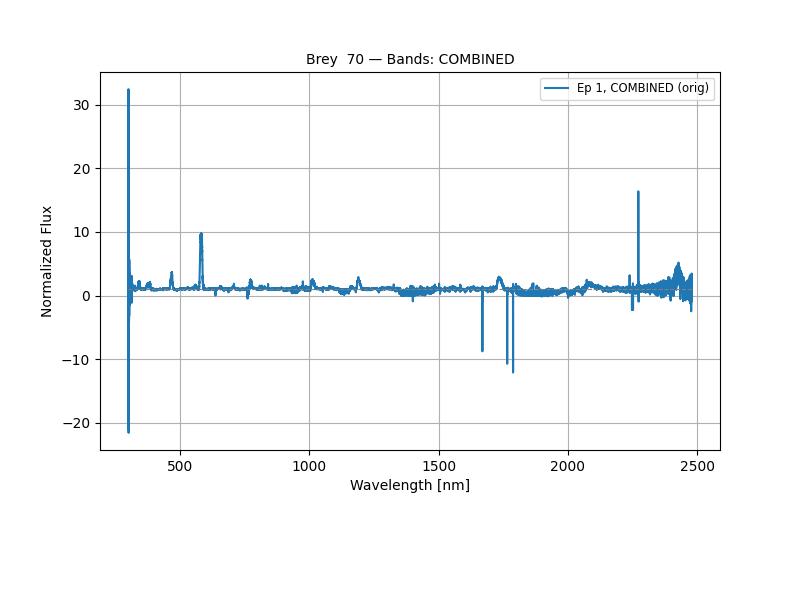

In [9]:
%matplotlib widget
star_name = specs.star_names[0]
print(star_name)
star = obs.load_star_instance(star_name)
star.plot_normalized_spectra(bands = 'COMBINED',compare=False,separation=0,bin_window=0,bary_correction=False,epoch_nums=[1])
# star.plot_normalized_spectrum(3,['UVB','VIS','NIR'])

In [24]:
emission_lines = {
    'O V 3100-3175': [310., 317.5],
    'O IV 3350-3480': [335,348],
    'C IV 3650-3900': [365.,390],
    'He II 4686':  [456., 480.],
    'C IV 5808-5812': [570., 590],
    'O VI 5210-5340': [521,534],
    'C IV 5350-5540': [535,554],
    'C III 6700-6800': [667.,684.],
    'C III 7000- 7100': [700,714],
    # 'idk1': [1715,1755],
    # 'idk2': [2050,2110],
    # 'telurics1': [1340,1495],
    # 'telurics2': [1795,1985],
    'He I 17100-17650': [1710,1765],
    'Mystery 20500-21000': [2050,2100]
}

for i, star_name in enumerate(specs.star_names):
    print(f'\'{star_name}\':')
    print('{')
    for key in emission_lines.keys():
    # print(f'{i} is {star_name}')
        print(f'"{key}": ,')
    print('}')

'Brey  70':
{
"O V 3100-3175": ,
"O IV 3350-3480": ,
"C IV 3650-3900": ,
"He II 4686": ,
"C IV 5808-5812": ,
"O VI 5210-5340": ,
"C IV 5350-5540": ,
"C III 6700-6800": ,
"C III 7000- 7100": ,
"He I 17100-17650": ,
"Mystery 20500-21000": ,
}
'Brey  83':
{
"O V 3100-3175": ,
"O IV 3350-3480": ,
"C IV 3650-3900": ,
"He II 4686": ,
"C IV 5808-5812": ,
"O VI 5210-5340": ,
"C IV 5350-5540": ,
"C III 6700-6800": ,
"C III 7000- 7100": ,
"He I 17100-17650": ,
"Mystery 20500-21000": ,
}
'HD  38029':
{
"O V 3100-3175": ,
"O IV 3350-3480": ,
"C IV 3650-3900": ,
"He II 4686": ,
"C IV 5808-5812": ,
"O VI 5210-5340": ,
"C IV 5350-5540": ,
"C III 6700-6800": ,
"C III 7000- 7100": ,
"He I 17100-17650": ,
"Mystery 20500-21000": ,
}
'HD  37248':
{
"O V 3100-3175": ,
"O IV 3350-3480": ,
"C IV 3650-3900": ,
"He II 4686": ,
"C IV 5808-5812": ,
"O VI 5210-5340": ,
"C IV 5350-5540": ,
"C III 6700-6800": ,
"C III 7000- 7100": ,
"He I 17100-17650": ,
"Mystery 20500-21000": ,
}
'Brey  95a':
{
"O V 3100-3175": ,


In [3]:
for i, star_name in enumerate(specs.star_names):
    print(f'{i} is {star_name}')

0 is Brey  70
1 is Brey  83
2 is HD  38029
3 is HD  37248
4 is Brey  95a
5 is MNM2014 LMC195-1
6 is HD  32125
7 is HD  37026
8 is HD 269818
9 is HD  38448
10 is HD  38030
11 is HD  37680
12 is Brey  58a
13 is HD  32228
14 is HD  32257
15 is HD 269888
16 is HD  36156
17 is H2013 LMCe  584
18 is RMC 140
19 is HD  32402
20 is Brey  70a
21 is Brey  16a
22 is Brey  93
23 is Brey  90a
24 is HD 269891


### Plot highest and lowest RVs fluxes

In [2]:
# Air wavelengths in Å (μm shown in labels only for readability)
# Sources noted below; optical values are the standard air rest wavelengths.
O_STAR_ABS_LINES_AIR = [
    # ── Optical (≈3800–7100 Å) ───────────────────────────────────────────
    ("Hδ 4101.74", 4101.74),
    ("He II 4200", 4199.83),
    ("Hγ 4340.47", 4340.47),
    ("He I 4387.93", 4387.93),
    ("He I 4471.48", 4471.48),
    ("He II 4541.59", 4541.59),
    ("N III 4640", 4640.64),   # blend (4634–4641)
    ("He II 4686", 4685.68),
    ("He I 4713.15", 4713.15),
    ("Hβ 4861.33", 4861.33),
    ("He I 4921.93", 4921.93),
    ("He II 5411.52", 5411.52),
    ("O III 5592", 5592.26),
    # C IV “λ5808” = 5801.33 + 5811.98 (kept as split doublet for RV work)
    ("C IV 5801.33", 5801.33),
    ("C IV 5811.98", 5811.98),
    ("He I 5875.62", 5875.62),
    ("Hα 6562.80", 6562.80),
    ("He I 6678.15", 6678.15),
    ("He I 7065.18", 7065.18),

    # ── J band (≈1.0–1.35 μm) ────────────────────────────────────────────
    ("He II 1.0124 μm", 10123.6),
    ("He I 1.0830 μm (comp.)", 10829.09),  # triplet fine-structure components
    ("He I 1.0830 μm (comp.)", 10830.25),
    ("He I 1.0830 μm (comp.)", 10830.34),
    ("Paγ 1.0938 μm", 10938.1),
    ("Paβ 1.2818 μm", 12818.1),

    # ── H band (≈1.5–1.8 μm) ─────────────────────────────────────────────
    ("Br12 1.6412 μm", 16412.0),
    ("Br11 1.6811 μm", 16811.0),
    ("He II 1.693 μm", 16930.0),
    ("He I 1.700 μm", 17002.47),  # precise NIST value

    # ── K band (≈2.0–2.4 μm) ─────────────────────────────────────────────
    ("He I 2.0581 μm", 20581.3),
    ("C IV 2.069 μm", 20690.0),
    ("C IV 2.078 μm", 20780.0),
    ("C IV 2.083 μm", 20830.0),
    ("He I 2.1127 μm", 21127.0),
    ("He I 2.1138 μm", 21138.0),
    ("Brγ 2.166 μm", 21655.0),   # air; vacuum is 21661 Å
    ("He II 2.1885 μm", 21885.0),
    # Optional Paschen-α in the gap between H/K if you cover it:
    ("Paα 1.8751 μm", 18751.0),
]

O_STAR_UVB_EXTRA_LINES = [
    # ── Balmer upper members (blueward of Hγ) ─────────────────────
    ("Hκ 3750.15", 3750.15),
    ("Hι 3770.63", 3770.63),
    ("Hθ 3797.90", 3797.90),
    ("Hη 3835.38", 3835.38),
    ("Hζ 3889.05", 3889.05),     # blends with He I 3889
    ("Hε 3970.07", 3970.07),     # blends with Ca II H 3968.47

    # ── He I (UVB-rich multiplets) ─────────────────────────────────
    ("He I 3819.61", 3819.61),
    ("He I 3889.75", 3889.75),   # (triplet) near Hζ
    ("He I 3926.54", 3926.54),
    ("He I 3964.73", 3964.73),
    ("He I 4009.26", 4009.26),
    ("He I 4026.19", 4026.19),
    ("He I 4120.82", 4120.82),
    ("He I 4143.76", 4143.76),
    ("He I 4168.97", 4168.97),
    ("He I 4387.93", 4387.93),
    ("He I 4437.55", 4437.55),
    ("He I 4471.48", 4471.48),
    ("He I 4713.15", 4713.15),
    ("He I 4921.93", 4921.93),
    ("He I 5015.68", 5015.68),
    ("He I 5047.74", 5047.74),

    # ── He II (blue/UVB + one Pickering near Hβ) ──────────────────
    ("He II 4200.47", 4200.47),
    ("He II 4541.59", 4541.59),
    ("He II 4685.68", 4685.68),
    ("He II 4859.32 (Pick.)", 4859.32),  # blends with Hβ 4861.33

    # ── Silicon ────────────────────────────────────────────────────
    ("Si IV 4088.86", 4088.86),
    ("Si IV 4116.10", 4116.10),
    ("Si II 3856.02", 3856.02),
    ("Si II 3862.60", 3862.60),
    ("Si II 4128.05", 4128.05),
    ("Si II 4130.89", 4130.89),
    ("Si III 4552.62", 4552.62),
    ("Si III 4567.84", 4567.84),
    ("Si III 4574.76", 4574.76),
    ("Si III 4813.33", 4813.33),
    ("Si III 4819.72", 4819.72),
    ("Si III 4829.07", 4829.07),

    # ── Oxygen (O II forest) ───────────────────────────────────────
    ("O II 4072.16", 4072.16),
    ("O II 4075.86", 4075.86),
    ("O II 4317.14", 4317.14),
    ("O II 4319.63", 4319.63),
    ("O II 4349.43", 4349.43),
    ("O II 4351.26", 4351.26),
    ("O II 4366.89", 4366.89),
    ("O II 4414.90", 4414.90),
    ("O II 4416.98", 4416.98),
    ("O II 4661.63", 4661.63),
    ("O II 4676.24", 4676.24),

    # ── Nitrogen ───────────────────────────────────────────────────
    ("N II 3995.00", 3995.00),
    ("N II 4041.31", 4041.31),
    ("N II 4043.53", 4043.53),
    ("N III 4097.33", 4097.33),
    ("N III 4510.89", 4510.89),
    ("N III 4514.85", 4514.85),
    ("N III 4518.15", 4518.15),
    ("N II 4601.48", 4601.48),
    ("N II 4607.16", 4607.16),
    ("N II 4613.87", 4613.87),
    ("N II 4621.39", 4621.39),
    ("N II 4630.54", 4630.54),
    ("N II 4643.08", 4643.08),

    # ── Carbon ─────────────────────────────────────────────────────
    ("C II 3918.97", 3918.97),
    ("C II 3920.69", 3920.69),
    ("C II 4267.00", 4267.00),
    ("C III 4070.26", 4070.26),
    ("C III 4152.52", 4152.52),
    ("C III 4162.88", 4162.88),
    ("C III 4186.90", 4186.90),
    ("C III 4516.77", 4516.77),
    ("C III 4647.42", 4647.42),
    ("C III 4650.25", 4650.25),
    ("C III 4651.47", 4651.47),

    # ── Magnesium (late-O / early-B discriminator) ─────────────────
    ("Mg II 4481.13", 4481.13),

    # ── Optional ISM anchors in the blue end ───────────────────────
    ("Ca II K 3933.66", 3933.66),
    ("Ca II H 3968.47", 3968.47),
]

TARGET_UVB_LINES = [
    # 3890 region: Balmer Hζ + He I blend
    ("H I Hζ 3889.05", 3889.05),
    ("He I 3889.75",   3889.75),

    # 4026 He I
    ("He I 4026.19",   4026.19),

    # 4100 region: Hδ (and a nearby helper if you want it)
    ("H I Hδ 4101.74", 4101.74),
    ("N III 4097.33",  4097.33),    # optional context line

    # 4200 He II
    ("He II 4200.47",  4200.47),

    # 4341 region: Hγ (air + vacuum alias if you like to see both)
    ("H I Hγ 4340.47", 4340.47),
    ("H I Hγ (vac) 4341.68", 4341.68),  # optional alias label

    # --- ADDED: H-beta is often the red-end anchor for the UVB arm ---
    ("H I Hβ 4861.33", 4861.33),
]


# Updated species_filter
species_filter=("H I", "Hα", "Hβ", "Hγ", "Hδ", "Hε", 
                "He I", "He II", "O II", "O III", "C II", 
                "C III", "C IV", "N II", "N III", "Si II", 
                "Si III", "Si IV", "Mg II", "Ca II")

MNM2014 LMC195-1
BAT99 identifier not found. The indexes were: -1 and 39. It found sion="1.0" encoding="UTF-8" ?>


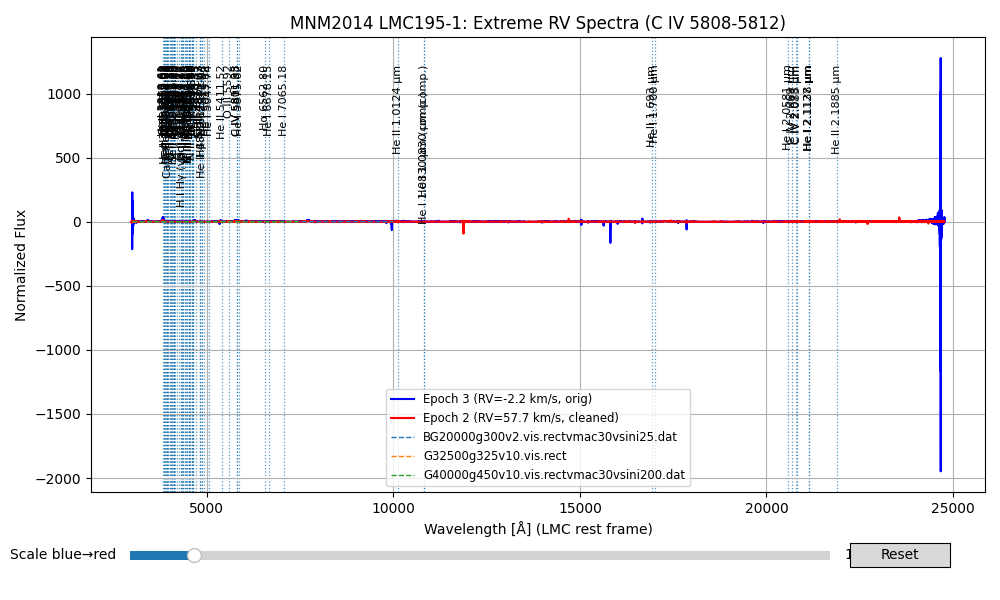

In [3]:
%matplotlib widget
models = [
    'BG20000g300v2.vis.rectvmac30vsini25.dat',
    # 'G32500g325v10.uv.rectvmac20vsini100.dat',
    'G32500g325v10.vis.rect',
    'G40000g450v10.vis.rectvmac30vsini200.dat']
O_STAR_ABS_LINES_AIR_EXT = (O_STAR_ABS_LINES_AIR + O_STAR_UVB_EXTRA_LINES + TARGET_UVB_LINES)
star_name = specs.star_names[5]
print(star_name)
star = obs.load_star_instance(star_name)
emission_line = 'C III 6700-6800'
emission_line = 'C IV 5808-5812'
# emission_line = 'He II 4686'
star.plot_extreme_rv_spectra(emission_line = emission_line,to_plot=True,models = models,correct_lmc=True,species_filter=species_filter, auto_annotate=True,even_emission_line=False,line_list = O_STAR_ABS_LINES_AIR_EXT)

HD 269891
Loaded property from: Data/HD 269891/epoch1/COMBINED/output/RVs.npz
Loaded property from: Data/HD 269891/epoch2/COMBINED/output/RVs.npz
Loaded property from: Data/HD 269891/epoch3/COMBINED/output/RVs.npz
Loaded property from: Data/HD 269891/epoch4/COMBINED/output/RVs.npz
Loaded property from: Data/HD 269891/epoch5/COMBINED/output/RVs.npz
Loaded property from: Data/HD 269891/epoch6/COMBINED/output/RVs.npz
Loaded property from: Data/HD 269891/epoch7/COMBINED/output/RVs.npz
Property 'cleaned_normalized_flux' not found
Loaded property from: Data/HD 269891/epoch5/COMBINED/output/normalized_flux.npz
Property 'cleaned_normalized_flux' not found
Loaded property from: Data/HD 269891/epoch3/COMBINED/output/normalized_flux.npz


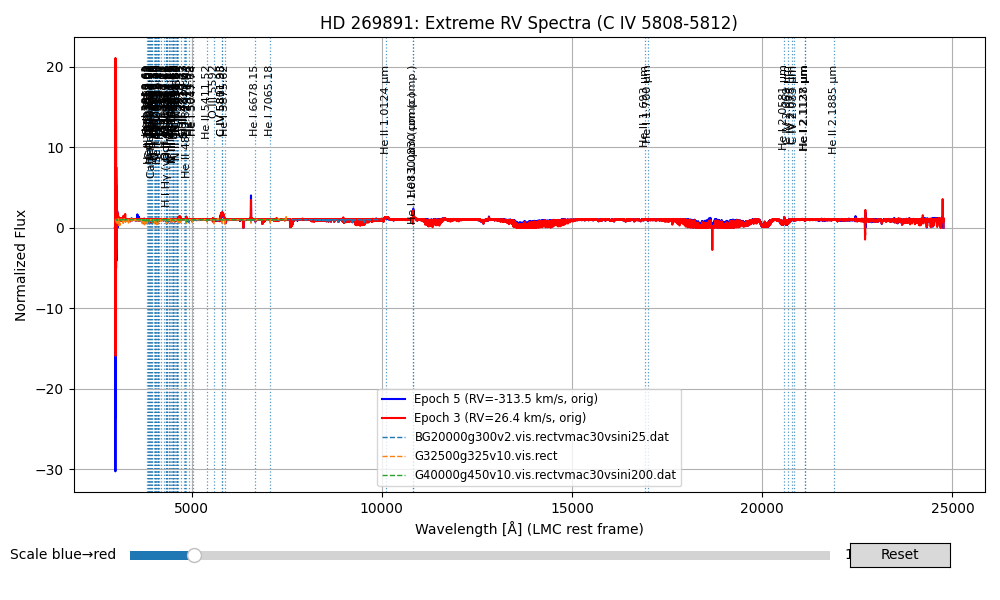

In [11]:
%matplotlib widget
models = [
    'BG20000g300v2.vis.rectvmac30vsini25.dat',
    # 'G32500g325v10.uv.rectvmac20vsini100.dat',
    'G32500g325v10.vis.rect',
    'G40000g450v10.vis.rectvmac30vsini200.dat']
O_STAR_ABS_LINES_AIR_EXT = (O_STAR_ABS_LINES_AIR + O_STAR_UVB_EXTRA_LINES + TARGET_UVB_LINES)
star_name = specs.star_names[24]
print(star_name)
star = obs.load_star_instance(star_name)
emission_line = 'C III 6700-6800'
emission_line = 'C IV 5808-5812'
# emission_line = 'He II 4686'
star.plot_extreme_rv_spectra(emission_line = emission_line,to_plot=True,models = models,correct_lmc=True,species_filter=species_filter, auto_annotate=True,even_emission_line=False,line_list = O_STAR_ABS_LINES_AIR_EXT)

### Plotting backuped up spectra vs new spectra

HD  38029
Loaded property from: Data/HD  38029/epoch1/COMBINED/output/cleaned_normalized_flux.npz
Loaded property from: Data/HD  38029/epoch1/COMBINED/output/cleaned_normalized_flux.npz
/Users/guyshtainer/Library/CloudStorage/OneDrive-Tel-AvivUniversity/תואר שני!/Thesis/Codes

Found backup files in 'overwritten' folder:
1. cleaned_normalized_flux_backup_05_08_2025__19_05_48.npz
2. cleaned_normalized_flux_backup_19_05_2025__18_07_04.npz
3. cleaned_normalized_flux_backup_19_05_2025__18_12_07.npz
4. cleaned_normalized_flux_backup_19_08_2025__18_20_29.npz
5. cleaned_normalized_flux_backup_21_08_2025__16_09_43.npz
6. cleaned_normalized_flux_backup_21_08_2025__16_12_47.npz
7. cleaned_normalized_flux_backup_31_05_2025__18_57_00.npz

Enter the number of the backup file to load (or 0 to cancel)


 5


Loaded backup file: cleaned_normalized_flux_backup_21_08_2025__16_09_43.npz


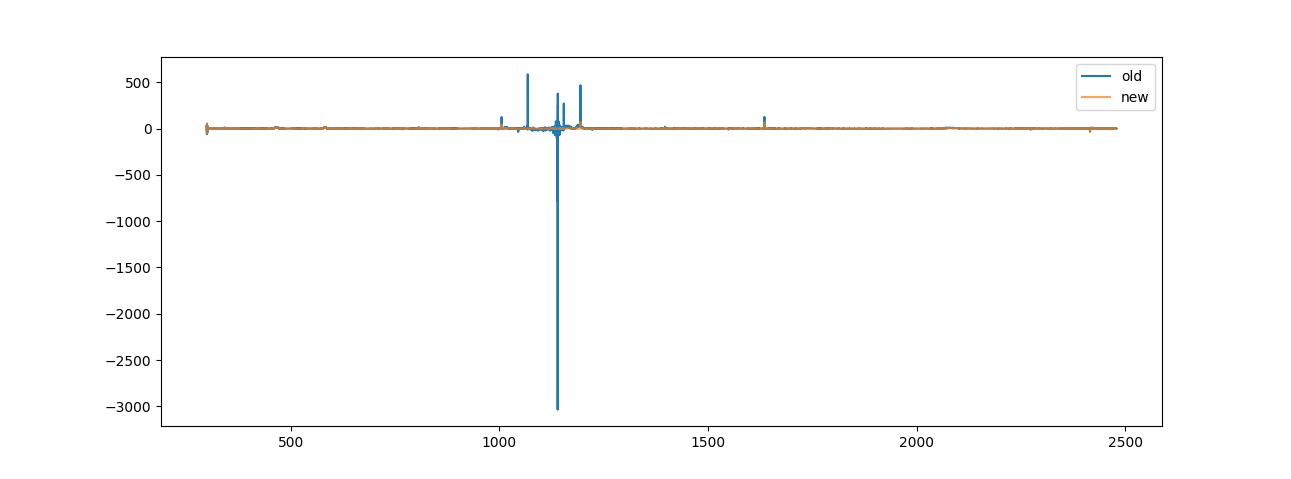

In [9]:
%matplotlib widget
plt.clf()
star_name = specs.star_names[2]
print(star_name)
star = obs.load_star_instance(star_name)
spectra = star.load_property(epoch_num=1,band='COMBINED',property_name='cleaned_normalized_flux')
new_flux = (spectra['normalized_flux']-1)*16/7 +1
new_wave = star.load_property(epoch_num=1,band='COMBINED',property_name='cleaned_normalized_flux')['wavelengths']
old_spectra = star.load_property(epoch_num=1,band='COMBINED',property_name='cleaned_normalized_flux',from_backup=True)
old_flux = old_spectra['normalized_flux']
old_wave = old_spectra['wavelengths']
plt.plot(old_wave,old_flux,label='old')
plt.plot(new_wave,new_flux,label='new',alpha=0.7)
plt.legend()
plt.show()

### Preview SNR snitch for cleaned normalized flux

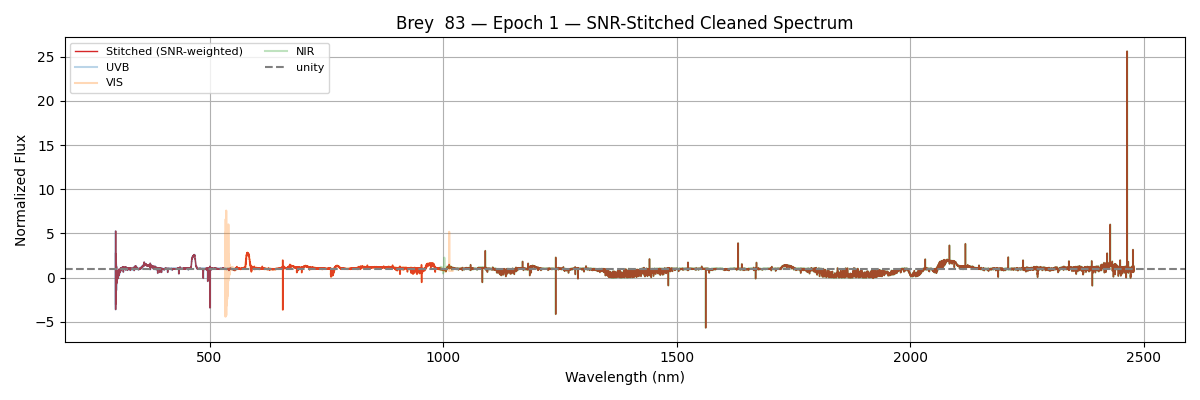

In [8]:
%matplotlib widget
star.preview_snr_stitch_cleaned_normalized(1)
# data = star.load_property('cleaned_normalized_flux',4,'NIR')
# flux = data['normalized_flux']
# wave = data['wavelengths']
# print(len(flux))
# print(len(wave))

## Plotting NRES spectra

### plotting normalized spectra

BAT99 not found properly. Indices -1, 39. Found sion="1.0" encoding="UTF-8" ?>


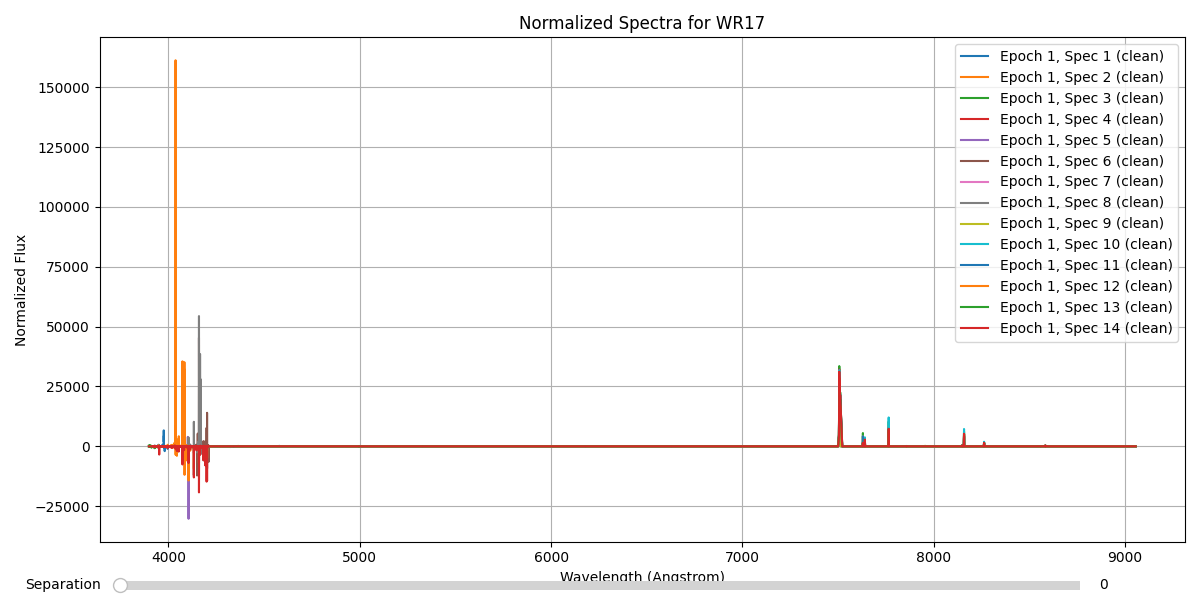

In [14]:
%matplotlib widget
star_names = ['WR 52','WR17']
star_name = star_names[1]
star = obs.load_star_instance(star_name)
spectra_list = [1,2,3,4,5,6,7,8,9,10,11,12,13,14]
# spectra_list = [1,2,3]
star.plot_normalized_spectra(1,spectra_list,bin_window=20,clean=True,initial_separation=0)
# star_name = star_names[0]
# star = obs.load_star_instance(star_name)
# star.plot_normalized_spectra([1,2,3],[1,3])
# star.plot_normalized_spectra2(1,1)

### Plotting raw spectra

Data loaded from Data/WR 52/epoch1/1/1D/cptnrs03-fa13-20250103-0050-e92-1d.fits.fz


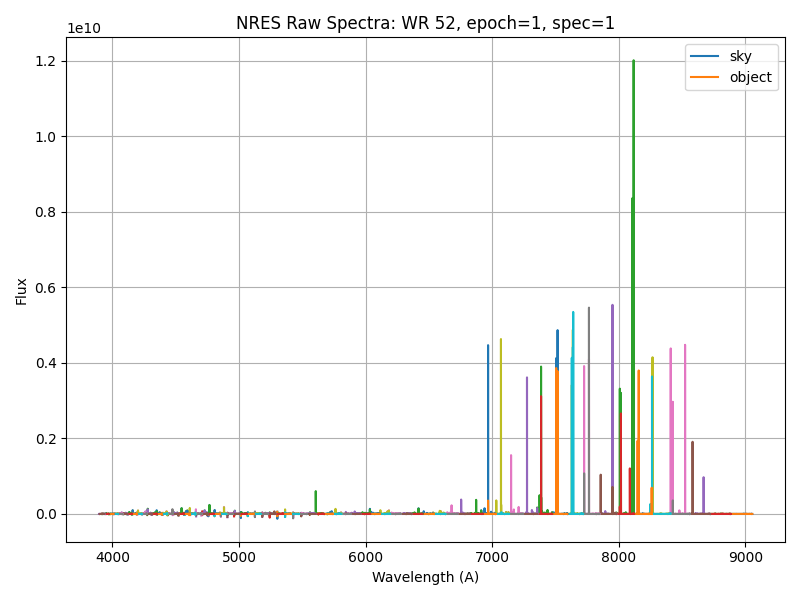

In [4]:
%matplotlib widget
star = obs.load_star_instance('WR17')
plt.clf()
normalized_data = star.load_property('nornormalized_data')
wave = normalized_data

### plotting SNR

{'wavelength': array([3897.88485403, 3897.9067727 , 3897.9286876 , ..., 9054.98743181,
       9055.01691123, 9055.04638386]), 'flux': array([-1.16903305e+05, -6.15583200e+04,  1.22863903e+05, ...,
        3.48336815e+05, -4.04723991e+05, -4.84475906e+01]), 'SNR': array([0.70149219, 0.59653747, 0.53779571, ..., 0.61453935, 0.54707681,
       0.52778694])}


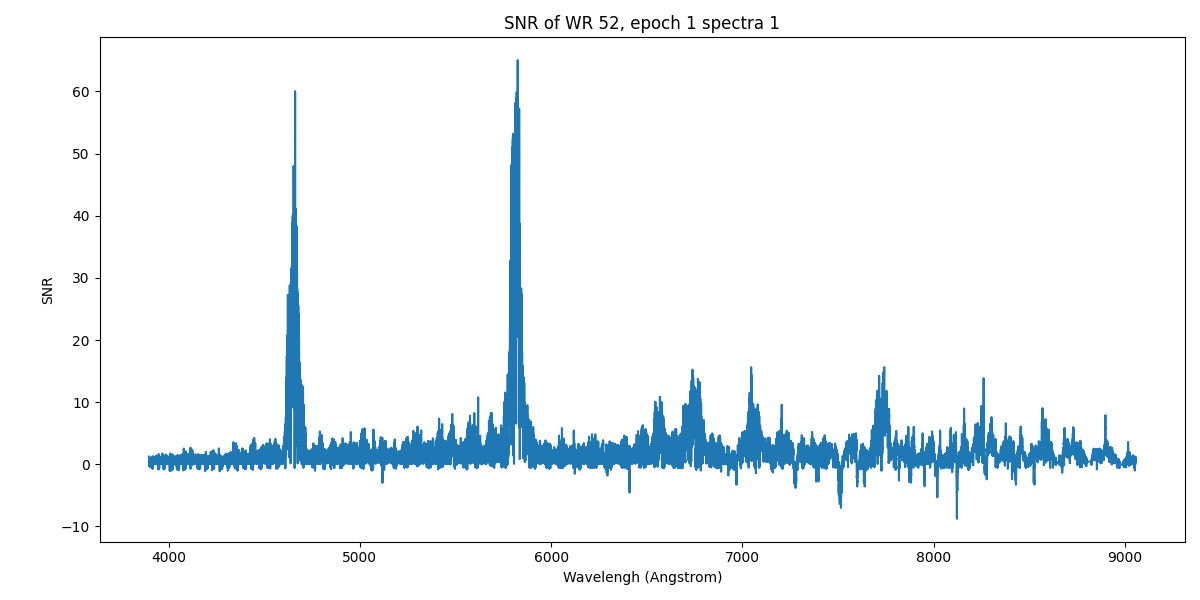

In [17]:
%matplotlib widget

# star.list_available_properties()
star = obs.load_star_instance(star_names[0])
combined_flux = star.load_property('combined_flux',1,1)
wave = combined_flux['wavelength']
flux = combined_flux['flux']
print(combined_flux)
SNR = combined_flux['SNR']
plt.clf()
plt.plot(wave,SNR)
plt.title(f'SNR of {star_names[0]}, epoch 1 spectra 1')
plt.xlabel('Wavelengh (Angstrom)')
plt.ylabel(f'SNR')
plt.show()

Data loaded from Data/WR17/epoch1/12/1D/cptnrs03-fa13-20250103-0044-e92-1d.fits.fz


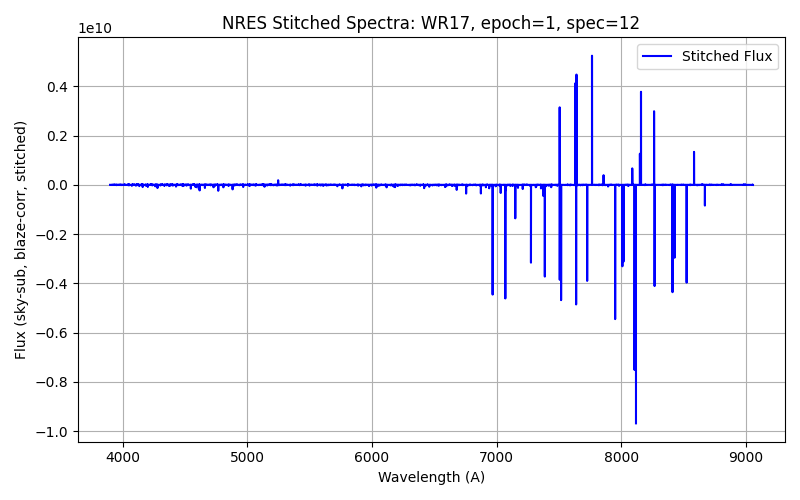

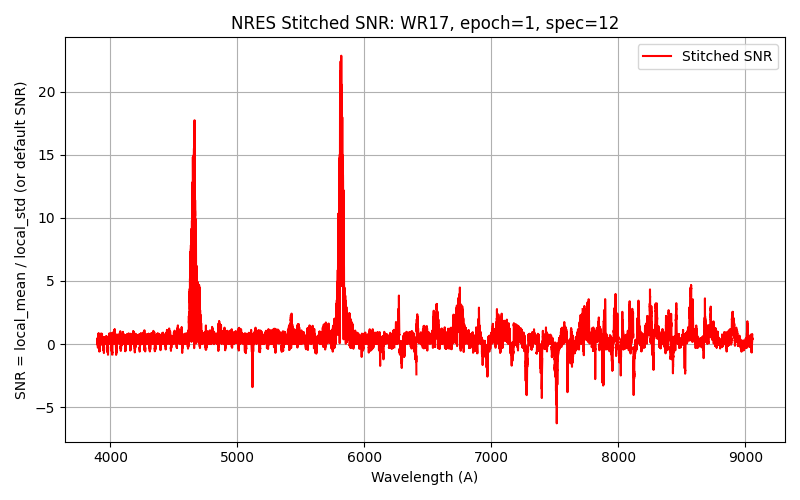

In [14]:
%matplotlib widget
wave,flux,snr = star.plot_stitched_spectra(1,12,my_SNR = True,plot_SNR=True,window_size = 20)

Data loaded from Data/WR17/epoch1/12/1D/cptnrs03-fa13-20250103-0044-e92-1d.fits.fz
[0. 0. 0. 0. 0. 0. 0. 0. 0.]


/var/folders/hm/f5s7jhns5qvgrw2hxpgfn5w80000gn/T/ipykernel_6267/2644009448.py:9: RuntimeWarning: invalid value encountered in divide
  plt.plot(wave[start + 1],flux[start + 1]/blaze[start + 1])
/var/folders/hm/f5s7jhns5qvgrw2hxpgfn5w80000gn/T/ipykernel_6267/2644009448.py:10: RuntimeWarning: invalid value encountered in divide
  plt.plot(wave[start + 3],flux[start + 3]/blaze[start + 3])
/var/folders/hm/f5s7jhns5qvgrw2hxpgfn5w80000gn/T/ipykernel_6267/2644009448.py:11: RuntimeWarning: invalid value encountered in divide
  plt.plot(wave[start + 5],flux[start + 5]/blaze[start + 5])
/var/folders/hm/f5s7jhns5qvgrw2hxpgfn5w80000gn/T/ipykernel_6267/2644009448.py:12: RuntimeWarning: invalid value encountered in divide
  plt.plot(wave[start + 7],flux[start + 7]/blaze[start + 7])


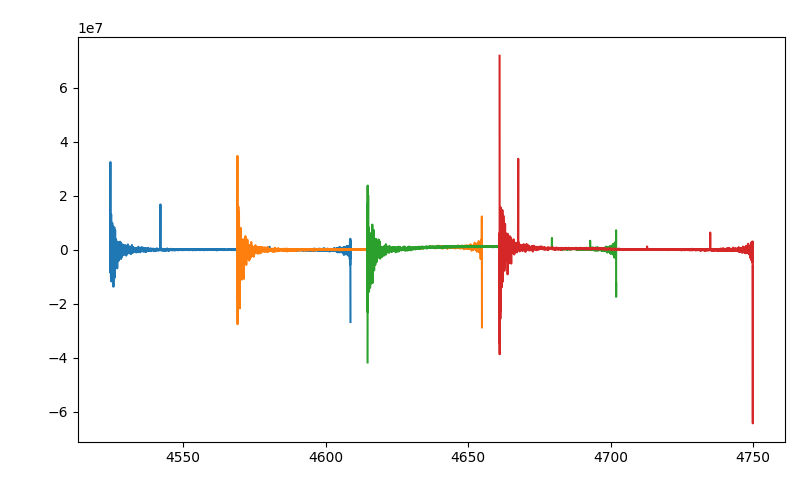

In [5]:
%matplotlib widget
data = star.load_observation(1,12).data
flux = np.flip(data['flux'])
blaze = np.flip(data['blaze'])
wave = np.flip(data['wavelength'])
print(wave[1][10:19])
start = 33
plt.clf()
plt.plot(wave[start + 1],flux[start + 1]/blaze[start + 1])
plt.plot(wave[start + 3],flux[start + 3]/blaze[start + 3])
plt.plot(wave[start + 5],flux[start + 5]/blaze[start + 5])
plt.plot(wave[start + 7],flux[start + 7]/blaze[start + 7])
# plt.plot(wave[1],flux[1])
# plt.plot(wave[3],flux[3])
plt.show()

Data loaded from Data/WR17/epoch1/12/1D/cptnrs03-fa13-20250103-0044-e92-1d.fits.fz


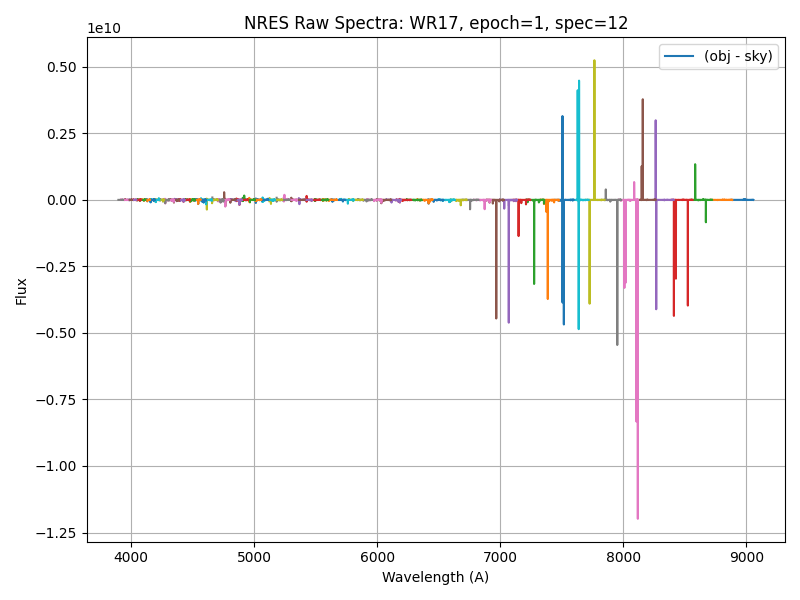

In [17]:
%matplotlib widget
blaze_correction = True
star.plot_raw_spectra(1,12,blaze_correction=blaze_correction,subtract_sky=True,just_sky = False,just_target=True)
emissions = [(4550,4800),(5700,5900)]
plt.xlim(emissions[1])
if blaze_correction:
    plt.ylim((-1e7,0.5e7))
else:
    plt.ylim((-100,1000))

In [4]:
obs = obsm()
star_name = specs.star_names[0]
star = obs.load_star_instance(star_name)
norm = star.load_property('normalized_flux',1,'COMBINED')
print(norm)
points = star.load_property('norm_anchor_wavelengths',1,'COMBINED')
print(points)

{'wavelengths': array([ 298.92,  298.94,  298.96, ..., 2478.84, 2478.9 , 2478.96],
      dtype='>f8'), 'normalized_flux': array([ 0.09609028, -0.05070256,  0.01819126, ...,  0.51625229,
        0.27221397,  0.        ])}
[ 309.52  317.76  332.42  350.58  364.2   387.58  398.84  404.9   412.8
  429.6   475.92  494.38  507.92  520.18  535.68  552.4   568.92  607.92
  631.68  667.96  695.46  714.22  750.68  809.56  849.8   860.22  876.46
  903.5   921.12  992.72 1044.06 1067.82 1103.7  1176.9  1222.8  1331.76
 1521.06 1651.62 1759.2  1985.46 2135.88 2259.66 2396.58 2468.88]


# Plotting RV binary analasys data

## analysing the correlations of the results of each emission line

### old

In [2]:
%matplotlib widget
# === ΔRV Analysis: Full Dashboard (User-Defined Weighting Logic) ===

import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import matplotlib.ticker as ticker
from matplotlib.markers import MarkerStyle
import textwrap
import ipywidgets as widgets
from IPython.display import display, clear_output
from scipy.stats import pearsonr

# ---------------- 1. SETUP & CONFIG ----------------
SETTINGS_PATH = "ccf_settings_with_global_lines.json"
try:
    with open(SETTINGS_PATH, "r") as f:
        SETTINGS = json.load(f)
except FileNotFoundError:
    print(f"WARNING: Could not find {SETTINGS_PATH}. Using empty settings.")
    SETTINGS = {}

STAR_CFG = {s["star_name"]: s for s in SETTINGS.get("stars", [])}
LINES_DEFAULT = SETTINGS.get("emission_lines_default", {}) 

# --- PRESENTATION MODE ---
for_presentation = True

# Config
CIV_KEY = "C IV 5808-5812"
THRESH_KMS = 10.0
MAX_RV_THRESH = 400 
EXTRA_ABOVE = 3  
BAR_FIGSIZE = (12, 6)
FIGSIZE_FRAC = (12, 6)
FIGSIZE_THRESH_PLOT = (10, 5)
FIGSIZE_AGREEMENT = (12, 7)
FIGSIZE_FBIN_BAR = (12, 6)
FAIL_FRAC_THRESH = 0.40
MIN_STARS_FOR_CORR = 8   
MAX_POSSIBLE_STARS = 25  
KNOWN_ERR_KEYS = ("full_RV_err", "full_err", "sigma", "err", "RV_err", "RV_sigma")
MEAN_COL = "Mean ΔRV"
STD_COL  = "Std ΔRV"

# Globals for storage
epoch_ew_data = {}        
ew_fail_stats = {}   
rv_epoch_cache = {} 
drverr_map = {} 
equiv_thresholds_map = {} 

# ---------------- 2. DATA PROCESSING HELPERS ----------------

def _is_clean_star(star):
    try:
        for ep in star.get_all_epoch_numbers():
            flux = star.load_property('cleaned_normalized_flux', ep, 'COMBINED')
            if flux is not None: 
                return False 
        return True 
    except Exception: 
        return True 

def _ew_record_for(star, epoch_num, line_key):
    try:
        EWs = star.load_property('EWs', epoch_num, 'COMBINED')
    except Exception: return None
    if EWs is None: return None
    try: rec = EWs.get(line_key)
    except Exception: return None
    if rec is None: return None
    try: rec_dict = rec.item()
    except Exception: return None
    if not isinstance(rec_dict, dict): return None

    def _to_float(x):
        try: return float(x)
        except Exception: return np.nan

    return {
        "EW": _to_float(rec_dict.get("EW")),
        "sigma_EW": _to_float(rec_dict.get("sigma_EW")),
        "SNR": _to_float(rec_dict.get("SNR")),
        "detected": rec_dict.get("detected")
    }

def _extract_full_rv(cell):
    try:
        if isinstance(cell, dict): return cell.get('full_RV', None)
        if hasattr(cell, "item"):
            v = cell.item()
            if isinstance(v, dict): return v.get('full_RV', None)
        if hasattr(cell, "get"): return cell.get('full_RV', None)
    except Exception: pass
    return None

def _extract_full_rv_err(cell):
    try:
        if isinstance(cell, dict):
            for k in KNOWN_ERR_KEYS:
                if k in cell and cell[k] is not None: return float(cell[k])
        if hasattr(cell, "item"):
            v = cell.item()
            if isinstance(v, dict):
                for k in KNOWN_ERR_KEYS:
                    if k in v and v[k] is not None: return float(v[k])
        if hasattr(cell, "get"):
            for k in KNOWN_ERR_KEYS:
                val = cell.get(k, None)
                if val is not None: return float(val)
    except Exception: pass
    return np.nan

def _is_epoch_skipped_for_line(star_name, line_key, ep):
    cfg = STAR_CFG.get(star_name, {})
    if ep in set(cfg.get("skip_epochs", [])): return True
    sl = cfg.get("skip_emission_lines", {})
    if line_key in sl:
        skip_eps = sl[line_key]
        if isinstance(skip_eps, (int, np.integer)): skip_eps = [skip_eps]
        if 0 in skip_eps or ep in skip_eps: return True
        return False

def _line_delta_rv_for_star(star, line_key):
    rv_vals, cache = [], []
    sname = star.star_name

    for ep in star.get_all_epoch_numbers():
        if _is_epoch_skipped_for_line(sname, line_key, ep):
            cache.append((ep, np.nan, np.nan, False))
            continue

        ewrec = _ew_record_for(star, ep, line_key)
        if ewrec is not None:
            epoch_ew_data[(sname, line_key, ep)] = ewrec

        RVs = star.load_property('RVs', ep, 'COMBINED')
        if not RVs or line_key not in RVs:
            cache.append((ep, np.nan, np.nan, False))
            continue

        cell = RVs[line_key]
        rv = _extract_full_rv(cell)

        if rv is None:
            cache.append((ep, np.nan, np.nan, False))
            continue

        try: rv = float(rv)
        except Exception:
            cache.append((ep, np.nan, np.nan, False))
            continue

        err = _extract_full_rv_err(cell)
        rv_vals.append((ep, rv, err))
        cache.append((ep, rv, err, True))

    rv_epoch_cache[(sname, line_key)] = cache

    if len(rv_vals) == 0:
        drverr_map[(sname, line_key)] = np.nan
        return np.nan

    ep_min, rv_min, err_min = min(rv_vals, key=lambda t: t[1])
    ep_max, rv_max, err_max = max(rv_vals, key=lambda t: t[1])
    dRV = abs(rv_max - rv_min)

    if np.isfinite(err_min) and np.isfinite(err_max):
        sigma_A = float(np.sqrt(err_min**2 + err_max**2))
    else:
        sigma_A = np.nan

    drverr_map[(sname, line_key)] = sigma_A
    return dRV

def _is_significant_binary(star_name: str, line_key: str, drv_val: float, threshold_val: float) -> bool:
    if not (pd.notna(drv_val) and np.isfinite(drv_val)): return False
    sigma_A = drverr_map.get((star_name, line_key), np.nan)
    if not np.isfinite(sigma_A): return False
    return (float(drv_val) >= threshold_val) and ((float(drv_val) - threshold_val) >= 4.0 * float(sigma_A))

def _compute_ew_fail_stats(star, line_key):
    sname = star.star_name
    considered = []
    failed = 0
    for ep in star.get_all_epoch_numbers():
        if _is_epoch_skipped_for_line(sname, line_key, ep): continue
        considered.append(ep)
        rec = epoch_ew_data.get((sname, line_key, ep))
        if isinstance(rec, dict):
            det = rec.get("detected")
            if det is False: failed += 1
    n_considered = len(considered)
    frac = (failed / n_considered) if n_considered > 0 else 0.0
    return failed, n_considered, frac

# ---------------- 3. LOAD DATA & BUILD DATAFRAME ----------------
rows = []
ordered_lines = list(LINES_DEFAULT.keys())

for star_name in specs.star_names:
    star = obs.load_star_instance(star_name, to_print=False)
    is_clean_bool = _is_clean_star(star)
    row = {"Star": star_name, "Clean": "✓" if is_clean_bool else "X", "is_clean_bool": is_clean_bool}
    
    for lk in ordered_lines: 
        dval = _line_delta_rv_for_star(star, lk)
        ew_fail_stats[(star_name, lk)] = _compute_ew_fail_stats(star, lk)
        row[f"dRV | {lk}"] = dval
    drvs = [v for k, v in row.items() if isinstance(k, str) and k.startswith("dRV | ")]
    row[MEAN_COL] = float(np.nanmean(drvs)) if np.isfinite(np.nanmean(drvs)) else np.nan
    row[STD_COL]  = float(np.nanstd(drvs))  if np.isfinite(np.nanstd(drvs))  else np.nan
    rows.append(row)

df = pd.DataFrame(rows)

# ---------------- 4. CALCULATE THRESHOLDS ----------------
def calculate_equivalent_thresholds(df_in):
    if CIV_KEY not in ordered_lines: return
    ref_col = f"dRV | {CIV_KEY}"
    civ_vals = []
    
    for i in range(len(df_in)):
        sname = df_in.at[i, "Star"]
        _, _, frac = ew_fail_stats.get((sname, CIV_KEY), (0,0,0))
        if frac > FAIL_FRAC_THRESH: continue
        val = df_in.at[i, ref_col]
        if pd.notna(val) and np.isfinite(float(val)):
            civ_vals.append((sname, float(val)))
            
    n_above = 0
    for s, v in civ_vals:
        if _is_significant_binary(s, CIV_KEY, v, 20.0):
            n_above += 1
    
    num = n_above + EXTRA_ABOVE
    den = len(civ_vals) + EXTRA_ABOVE
    f_ref = num / den if den > 0 else 0
    
    equiv_thresholds_map.clear()
    search_space = np.arange(1, MAX_RV_THRESH + 1, 1)
    
    for lk in ordered_lines:
        col = f"dRV | {lk}"
        if col not in df_in.columns: continue
        line_vals = []
        for i in range(len(df_in)):
            sname = df_in.at[i, "Star"]
            _, _, frac = ew_fail_stats.get((sname, lk), (0,0,0))
            if frac > FAIL_FRAC_THRESH: continue
            val = df_in.at[i, col]
            if pd.notna(val) and np.isfinite(float(val)):
                line_vals.append((sname, float(val)))
        
        total_line = len(line_vals)
        if total_line == 0:
            equiv_thresholds_map[lk] = np.nan
            continue
            
        best_T = 20.0
        min_diff = 999.0
        
        for T in search_space:
            cnt = 0
            for s, v in line_vals:
                if _is_significant_binary(s, lk, v, T): cnt += 1
            f_curr = (cnt + EXTRA_ABOVE) / (total_line + EXTRA_ABOVE)
            diff = abs(f_curr - f_ref)
            if diff < min_diff:
                min_diff = diff
                best_T = float(T)
        equiv_thresholds_map[lk] = best_T

calculate_equivalent_thresholds(df)

ordered_cols = ["Star", "Clean", MEAN_COL, STD_COL] + [f"dRV | {lk}" for lk in ordered_lines if f"dRV | {lk}" in df.columns]
if f"dRV | {CIV_KEY}" in df.columns:
    df = df.sort_values(f"dRV | {CIV_KEY}", ascending=False, na_position="last").reset_index(drop=True)

# ---------------- 5. HELPER FOR CLASSIFICATION & FITTING ----------------
def get_star_classification_data(df_in, use_equiv):
    results = {}
    for i in range(len(df_in)):
        sname = df_in.at[i, "Star"]
        if not isinstance(sname, str) or sname == "f_bin": continue
        is_clean = bool(df_in.at[i, "is_clean_bool"])
        votes_bin = 0
        votes_single = 0
        civ_status = None
        valid_lines = 0
        for lk in ordered_lines:
            _, _, frac = ew_fail_stats.get((sname, lk), (0,0,0))
            if frac > FAIL_FRAC_THRESH: continue
            col_name = f"dRV | {lk}"
            if col_name not in df_in.columns: continue
            val = df_in.at[i, col_name]
            if pd.isna(val) or not np.isfinite(float(val)): continue
            t_use = THRESH_KMS
            if use_equiv:
                t_eq = equiv_thresholds_map.get(lk, np.nan)
                if np.isfinite(t_eq): t_use = t_eq
            is_bin = _is_significant_binary(sname, lk, float(val), t_use)
            if is_bin: votes_bin += 1
            else: votes_single += 1
            if lk == CIV_KEY: civ_status = is_bin
            valid_lines += 1
        if valid_lines == 0: continue
        agreement = max(votes_bin, votes_single) / valid_lines
        if agreement > 0.90: grade = 'Golden'
        elif agreement > 0.70: grade = 'Silver'
        else: grade = 'Bronze'
        if votes_bin > votes_single: final_bin = True
        elif votes_single > votes_bin: final_bin = False
        else: final_bin = civ_status if civ_status is not None else False
        results[sname] = {'grade': grade, 'is_binary': final_bin, 'is_clean': is_clean}
    return results

# === Chi-Squared 2-Segment Linear Fit ===
def _fit_two_segment_linear_weighted(x, y, y_err):
    if len(x) < 5: return None 
    w = 1.0 / (y_err**2)
    w[~np.isfinite(w)] = 0.0001
    best_chi2 = np.inf
    best_res = None
    for i in range(2, len(x) - 2):
        x1, y1, w1 = x[:i], y[:i], w[:i]
        x2, y2, w2 = x[i:], y[i:], w[i:]
        try:
            p1 = np.polyfit(x1, y1, 1, w=np.sqrt(w1)) 
            fit1 = np.polyval(p1, x1)
            chi2_1 = np.sum(w1 * (y1 - fit1)**2)
        except:
            chi2_1 = np.inf
            p1 = [0,0]
        try:
            p2 = np.polyfit(x2, y2, 1, w=np.sqrt(w2))
            fit2 = np.polyval(p2, x2)
            chi2_2 = np.sum(w2 * (y2 - fit2)**2)
        except:
            chi2_2 = np.inf
            p2 = [0,0]
        total_chi2 = chi2_1 + chi2_2
        if total_chi2 < best_chi2:
            best_chi2 = total_chi2
            m1, c1 = p1
            m2, c2 = p2
            if abs(m1 - m2) > 1e-9:
                elbow_x = (c2 - c1) / (m1 - m2)
                elbow_y = m1 * elbow_x + c1
            else:
                elbow_x = x[i]
                elbow_y = y[i]
            best_res = {
                'elbow_x': elbow_x, 'elbow_y': elbow_y,
                'p1': p1, 'p2': p2, 'break_idx': i,
                'range1': (x[0], elbow_x),
                'range2': (elbow_x, x[-1]),
                'chi2': best_chi2
            }
    return best_res

# ---------------- 6. PLOTTING LOGIC ----------------

def wrap_header(colname: str) -> str:
    if colname in ("Star", "Clean", MEAN_COL, STD_COL): return colname
    return "\n".join(textwrap.wrap(colname.replace("dRV | ", "dRV\n"), width=12, break_long_words=True))

def wrap_str(s, width):
    if pd.isna(s): return s
    return "\n".join(textwrap.wrap(str(s), width=width, break_long_words=True)) or str(s)

def wilson_score_interval(k, n, z=1.0):
    if n == 0: return 0.0, 0.0
    p = k / n
    denominator = 1 + z**2/n
    center_adjusted_probability = (p + z**2 / (2*n)) / denominator
    error_margin = (z * np.sqrt((p*(1-p)/n) + (z**2/(4*n**2)))) / denominator
    low = center_adjusted_probability - error_margin
    high = center_adjusted_probability + error_margin
    return max(0.0, low), min(1.0, high)

# === UPDATED: Returns (frac, err_low, err_high) for internal logic ===
def _calc_fbin_stats_internal(base_with, line_key, use_equiv_thresh):
    colname = f"dRV | {line_key}"
    if colname not in base_with.columns: return 0.0, 0.0, 0.0
    thresh_to_use = THRESH_KMS
    if use_equiv_thresh:
        t = equiv_thresholds_map.get(line_key, THRESH_KMS)
        if np.isfinite(t): thresh_to_use = t

    vals = base_with[colname]
    idx_with_drv = []
    for i in range(0, len(base_with)):
        star_name = base_with.at[i, "Star"]
        if not isinstance(star_name, str) or star_name == "f_bin": continue
        _, _, frac = ew_fail_stats.get((star_name, line_key), (0, 0, 0.0))
        if frac > FAIL_FRAC_THRESH: continue
        try:
            v = vals.iat[i]
            if pd.notna(v) and np.isfinite(float(v)): idx_with_drv.append(i)
        except Exception: pass

    n_total = len(idx_with_drv)
    if n_total == 0: return 0.0, 0.0, 0.0
    n_above = 0
    for i in idx_with_drv:
        star_name = base_with.at[i, "Star"]
        dval = float(vals.iat[i])
        if _is_significant_binary(star_name, line_key, dval, thresh_to_use): n_above += 1
        
    n_total_adj = n_total + EXTRA_ABOVE
    n_above_adj = n_above + EXTRA_ABOVE
    frac_adj = n_above_adj / n_total_adj
    
    low, high = wilson_score_interval(n_above_adj, n_total_adj, z=1.0)
    err_low = frac_adj - low
    err_high = high - frac_adj
    return frac_adj, err_low, err_high, n_above_adj, n_total_adj

# === UPDATED: Returns formatted string WITH errors ===
def _get_fbin_simple(base_with, line_key, use_equiv_thresh):
    frac, el, eh, num, den = _calc_fbin_stats_internal(base_with, line_key, use_equiv_thresh)
    if den == 0: return "0/0 (—)"
    # Format: 5/10 (50% +10/-5)
    return f"{num}/{den} ({frac:.0%} +{eh:.0%}/-{el:.0%})"

def _get_fbin_float(base_with, line_key, use_equiv_thresh):
    f, _, _, _, _ = _calc_fbin_stats_internal(base_with, line_key, use_equiv_thresh)
    return f * 100.0

def _calc_ew_stats_for_line(line_key):
    failed = 0
    considered = 0
    all_ews = []
    
    for sname in STAR_CFG.keys():
        n_fail, n_cons, _ = ew_fail_stats.get((sname, line_key), (0, 0, 0))
        failed += n_fail
        considered += n_cons
    
    for (sname, lk, ep), rec in epoch_ew_data.items():
        if lk == line_key and isinstance(rec, dict):
            val = rec.get("EW")
            if val is not None and np.isfinite(val):
                all_ews.append(val)

    if considered > 0:
        success_rate = 1.0 - (failed / considered)
    else:
        success_rate = 0.0
        
    if len(all_ews) > 0:
        mean_ew = np.nanmean(all_ews)
        sem_ew = np.nanstd(all_ews) / np.sqrt(len(all_ews))
    else:
        mean_ew = np.nan
        sem_ew = np.nan
        
    return success_rate, mean_ew, sem_ew

def _get_wavelength(name):
    match = re.search(r"(\d+)", name)
    if match:
        return float(match.group(1))
    return 999999.0

def render_plots(sort_col, ascending):
    # --- STYLE SETTINGS ---
    if for_presentation:
        plt.rcParams.update({
            'font.size': 14,
            'axes.titlesize': 16,
            'axes.labelsize': 14,
            'xtick.labelsize': 12,
            'ytick.labelsize': 12,
            'legend.fontsize': 12
        })
        FS_NOTE = 12
        FS_TINY = 11
        FS_AXIS_LBL = 14
        FS_BAR_VAL = 12
        FS_BOX_STAT = 8
        FS_PIE_LABEL = 14
        FS_LIST_TEXT = 11
    else:
        plt.rcParams.update({
            'font.size': 10,
            'axes.titlesize': 12,
            'axes.labelsize': 10,
            'xtick.labelsize': 10,
            'ytick.labelsize': 10,
            'legend.fontsize': 10
        })
        FS_NOTE = 9
        FS_TINY = 8
        FS_AXIS_LBL = 10
        FS_BAR_VAL = 9
        FS_BOX_STAT = 7
        FS_PIE_LABEL = 11
        FS_LIST_TEXT = 9

    # Masking logic
    base = df.copy()[ordered_cols]
    masked = base.copy()
    for col in [c for c in masked.columns if c.startswith("dRV | ")]:
        line_key = col.replace("dRV | ", "")
        for i in range(len(masked)):
            sname = masked.at[i, "Star"]
            if not isinstance(sname, str) or sname == "f_bin": continue
            n_fail, n_cons, frac = ew_fail_stats.get((sname, line_key), (0, 0, 0.0))
            if (n_cons > 0) and (frac > FAIL_FRAC_THRESH):
                if not state.get("force_show_low_detection", False):
                    masked.at[i, col] = np.nan

    sort_col_use = sort_col if sort_col in masked.columns else masked.columns[2]
    masked = masked.sort_values(sort_col_use, ascending=ascending, na_position="last").reset_index(drop=True)
    use_equiv = state.get("use_equiv_thresh", False)

    # --- PLOTS 1-6 ---
    vals = masked[sort_col_use].to_numpy()
    x = np.arange(len(masked))
    line_key_bar = sort_col_use.replace("dRV | ", "") if sort_col_use.startswith("dRV | ") else None
    current_thresh = THRESH_KMS
    if use_equiv and line_key_bar:
        t = equiv_thresholds_map.get(line_key_bar, THRESH_KMS)
        if np.isfinite(t): current_thresh = t
    colors = []
    yerrs = []
    for i in range(len(masked)):
        star_name = masked.at[i, "Star"]
        val = vals[i]
        if pd.isna(val): 
            colors.append("gray"); yerrs.append(0)
        elif line_key_bar: 
            is_sig = _is_significant_binary(star_name, line_key_bar, float(val), current_thresh)
            colors.append("green" if is_sig else "red")
            err = drverr_map.get((star_name, line_key_bar), 0)
            yerrs.append(err if np.isfinite(err) else 0)
        else: 
            colors.append("green" if val >= current_thresh else "red"); yerrs.append(0)
    plt.figure(figsize=BAR_FIGSIZE)
    plt.plot(x, vals, color='black', alpha=0.2, zorder=1)
    for i in range(len(x)):
        plt.errorbar(x[i], vals[i], yerr=yerrs[i], fmt='o', color=colors[i], ecolor=colors[i], capsize=3, zorder=2)
    plt.axhline(current_thresh, linestyle="--", linewidth=1, color='gray', label=f"Threshold {current_thresh:.1f} km/s")
    plt.xticks(x, [wrap_str(s, 10) for s in masked["Star"]], rotation=45, ha="right")
    plt.ylabel("|ΔRV| (km/s)")
    
    use_log = state.get("corner_log_scale", True)
    if use_log:
        plt.yscale('log')
        valid_pos = [v for v in vals if pd.notna(v) and v > 0]
        if valid_pos:
            plt.ylim(min(valid_pos)*0.5, max(valid_pos)*2.0)

    plt.title(f"Peak-to-peak |ΔRV| for {sort_col_use.replace('dRV | ', '')} ({'asc' if ascending else 'desc'})")
    plt.tight_layout()
    plt.show()

    if line_key_bar:
        valid_indices = []
        for i in range(len(masked)):
            sname = masked.at[i, "Star"]
            _, _, frac = ew_fail_stats.get((sname, line_key_bar), (0, 0, 0.0))
            if frac > FAIL_FRAC_THRESH: continue
            v = masked.at[i, sort_col_use]
            if pd.notna(v) and np.isfinite(float(v)): valid_indices.append(i)
        
        t_vals = np.arange(1, MAX_RV_THRESH + 1, 1)
        fractions = []
        err_lows = []
        err_highs = []
        
        for t in t_vals:
            n_pass = 0
            for idx in valid_indices:
                sname = masked.at[idx, "Star"]
                dval = float(masked.at[idx, sort_col_use])
                if _is_significant_binary(sname, line_key_bar, dval, t): n_pass += 1
            num = n_pass + EXTRA_ABOVE
            den = len(valid_indices) + EXTRA_ABOVE
            f = num / den if den > 0 else 0
            fractions.append(f)
            
            l, h = wilson_score_interval(num, den, z=1.0)
            err_lows.append(f - l)
            err_highs.append(h - f)
        
        plt.figure(figsize=FIGSIZE_FRAC)
        
        frac_arr = np.array(fractions)
        low_bound = frac_arr - np.array(err_lows)
        high_bound = frac_arr + np.array(err_highs)
        
        plt.fill_between(t_vals, low_bound, high_bound, color='blue', alpha=0.15, label=r"68% Conf. Int. (Wilson)")
        plt.plot(t_vals, fractions, marker='.', color='blue', markersize=4, label="Data")
        
        if state.get("fit_elbow", True) and len(fractions) > 5:
            sigma_approx = (np.array(err_lows) + np.array(err_highs)) / 2.0
            sigma_approx[sigma_approx == 0] = 0.01 
            
            fit_res = _fit_two_segment_linear_weighted(t_vals, np.array(fractions), sigma_approx)
            
            if fit_res:
                x1_range = np.linspace(fit_res['range1'][0], fit_res['elbow_x'], 50)
                y1_range = np.polyval(fit_res['p1'], x1_range)
                plt.plot(x1_range, y1_range, color='orange', linewidth=2, label=f"Best $\chi^2$ Fit")
                
                x2_range = np.linspace(fit_res['elbow_x'], fit_res['range2'][1], 50)
                y2_range = np.polyval(fit_res['p2'], x2_range)
                plt.plot(x2_range, y2_range, color='orange', linewidth=2)
                
                plt.axvline(fit_res['elbow_x'], color='orange', linestyle='--', label=f"Elbow ({fit_res['elbow_x']:.1f} km/s)")

        plt.axvline(THRESH_KMS, color='red', linestyle='--', label=f'Hard Elbow ({THRESH_KMS} km/s)')
        if use_equiv and np.isfinite(current_thresh) and current_thresh != THRESH_KMS:
             plt.axvline(current_thresh, color='green', linestyle=':', label=f'Equiv ({current_thresh:.1f} km/s)')
             
        step_size = max(10, int(MAX_RV_THRESH / 10))
        plt.xticks(np.arange(0, MAX_RV_THRESH + 1, step_size))
        
        plt.yticks(np.arange(0, 1.1, 0.1))
        plt.xlabel("Threshold [km/s]")
        plt.ylabel(f"Binary Fraction ($f_{{\mathrm{{bin}}}}$)")
        plt.title(f"Binary Fraction vs Threshold for {line_key_bar}")
        plt.grid(True, alpha=0.3, which='both')
        plt.legend()
        plt.ylim(0, 1.05)
        plt.tight_layout()
        plt.show()

    lines_plot = []
    thresholds_plot = []
    for lk in ordered_lines:
        t = equiv_thresholds_map.get(lk, np.nan)
        lines_plot.append(lk)
        thresholds_plot.append(t)
    if len(lines_plot) > 0:
        plt.figure(figsize=FIGSIZE_THRESH_PLOT)
        plt.plot(lines_plot, thresholds_plot, marker='o', linestyle='-', color='purple')
        plt.xticks(rotation=45, ha='right')
        plt.ylabel("Equivalent Threshold [km/s]")
        plt.title(f"Thresholds yielding $f_{{\mathrm{{bin}}}}$ ≈ $f_{{\mathrm{{bin}}}}$(CIV, 20km/s)")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    show_names = state.get("show_corner_names", False)
    use_log = state.get("corner_log_scale", True)
    n_lines = len(ordered_lines)
    line_ranges = {}
    for lk in ordered_lines:
        col = f"dRV | {lk}"
        vals = []
        if use_equiv: t_val = equiv_thresholds_map.get(lk, THRESH_KMS)
        else: t_val = THRESH_KMS
        if np.isfinite(t_val): vals.append(t_val)
        if col in masked.columns:
            for i in range(len(masked)):
                sname = masked.at[i, "Star"]
                _, _, frac = ew_fail_stats.get((sname, lk), (0,0,0))
                if frac > FAIL_FRAC_THRESH: continue
                v = masked.at[i, col]
                if pd.notna(v) and np.isfinite(float(v)): vals.append(float(v))
        if not vals:
            line_ranges[lk] = (0.1, MAX_RV_THRESH)
            continue
        vmin, vmax = min(vals), max(vals)
        if use_log:
            pos_vals = [x for x in vals if x > 0]
            if pos_vals:
                vmin = min(pos_vals)
                log_min, log_max = np.log10(vmin), np.log10(vmax)
                span = log_max - log_min if log_max > log_min else 0.5
                vmin = 10**(log_min - 0.05*span)
                vmax = 10**(log_max + 0.05*span)
            else: vmin, vmax = 0.1, MAX_RV_THRESH
        else:
            span = vmax - vmin if vmax > vmin else 5.0
            vmin = vmin - 0.05*span
            vmax = vmax + 0.05*span
            if vmin < 0: vmin = 0 
        line_ranges[lk] = (vmin, vmax)
    if n_lines > 1:
        dim = max(16, 3 * n_lines)
        fig, axes = plt.subplots(n_lines, n_lines, figsize=(dim, dim), sharex='col')
        plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05, wspace=0, hspace=0)
        if n_lines == 1: axes = np.array([[axes]]) 
        trans_diagonal = mtransforms.Affine2D().rotate_deg(-45)
        for i in range(n_lines): 
            line_y_key = ordered_lines[i]
            y_min, y_max = line_ranges.get(line_y_key, (0.1, MAX_RV_THRESH))
            thresh_y = equiv_thresholds_map.get(line_y_key, THRESH_KMS) if use_equiv else THRESH_KMS
            for j in range(n_lines):
                ax = axes[i, j]
                line_x_key = ordered_lines[j]
                x_min, x_max = line_ranges.get(line_x_key, (0.1, MAX_RV_THRESH))
                thresh_x = equiv_thresholds_map.get(line_x_key, THRESH_KMS) if use_equiv else THRESH_KMS
                if use_log:
                    ax.set_xscale('log')
                    if i != j: ax.set_yscale('log')
                ax.set_xlim(x_min, x_max)
                if i != j: ax.set_ylim(y_min, y_max)
                if i < n_lines - 1: ax.tick_params(axis='x', labelbottom=False, length=0)
                if j > 0: ax.tick_params(axis='y', labelleft=False, length=0) 
                if j > i: ax.axis('off'); continue
                if i == j:
                    col_name = f"dRV | {line_y_key}"
                    if col_name in masked.columns:
                        vals_hist = []
                        for row_idx in range(len(masked)):
                            sname = masked.at[row_idx, "Star"]
                            _, _, frac = ew_fail_stats.get((sname, line_y_key), (0,0,0))
                            if frac > FAIL_FRAC_THRESH: continue
                            v = masked.at[row_idx, col_name]
                            if pd.notna(v) and np.isfinite(float(v)): vals_hist.append(float(v))
                        if len(vals_hist) > 0:
                            if use_log:
                                hv_min = max(x_min, min([v for v in vals_hist if v > 0]) if any(v>0 for v in vals_hist) else x_min)
                                hv_max = max(x_max, max(vals_hist))
                                bins = np.geomspace(hv_min, hv_max, 15)
                            else: bins = 15
                            ax.hist(vals_hist, bins=bins, color='gray', alpha=0.7, histtype='stepfilled', edgecolor='black')
                    ax.yaxis.set_visible(False); continue
                x_vals, y_vals, x_errs, y_errs = [], [], [], []
                c_topleft, c_botright = [], []
                names_to_plot = []
                col_x = f"dRV | {line_x_key}"
                col_y = f"dRV | {line_y_key}"
                if (col_x in masked.columns) and (col_y in masked.columns):
                    for row_idx in range(len(masked)):
                        sname = masked.at[row_idx, "Star"]
                        _, _, frac_x = ew_fail_stats.get((sname, line_x_key), (0,0,0))
                        _, _, frac_y = ew_fail_stats.get((sname, line_y_key), (0,0,0))
                        if (frac_x > FAIL_FRAC_THRESH) or (frac_y > FAIL_FRAC_THRESH): continue
                        vx = masked.at[row_idx, col_x]; vy = masked.at[row_idx, col_y]
                        if pd.notna(vx) and np.isfinite(float(vx)) and pd.notna(vy) and np.isfinite(float(vy)):
                            vx = float(vx); vy = float(vy)
                            if use_log and (vx <= 0 or vy <= 0): continue
                            x_vals.append(vx); y_vals.append(vy)
                            err_x = drverr_map.get((sname, line_x_key), 0.0)
                            err_y = drverr_map.get((sname, line_y_key), 0.0)
                            x_errs.append(err_x if np.isfinite(err_x) else 0.0)
                            y_errs.append(err_y if np.isfinite(err_y) else 0.0)
                            pass_y = _is_significant_binary(sname, line_y_key, vy, thresh_y)
                            c_topleft.append('green' if pass_y else 'red')
                            pass_x = _is_significant_binary(sname, line_x_key, vx, thresh_x)
                            c_botright.append('green' if pass_x else 'red')
                            names_to_plot.append(sname)
                if len(x_vals) > 0:
                    x_arr = np.array(x_vals); y_arr = np.array(y_vals)
                    x_err_arr = np.array(x_errs); y_err_arr = np.array(y_errs)
                    ax.axvline(thresh_x, color='black', linestyle=':', alpha=0.6, linewidth=1)
                    ax.axhline(thresh_y, color='black', linestyle=':', alpha=0.6, linewidth=1)
                    diag_min = max(x_min, y_min); diag_max = min(x_max, y_max)
                    ax.plot([diag_min, diag_max], [diag_min, diag_max], ls='--', color='gray', alpha=0.5, linewidth=1, zorder=0)
                    fbin_y_str = _get_fbin_simple(masked, line_y_key, use_equiv)
                    ax.text(0.05, 0.95, r"$f_{\mathrm{bin}}$(Y): " + fbin_y_str, transform=ax.transAxes, fontsize=FS_NOTE, va='top', ha='left', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))
                    fbin_x_str = _get_fbin_simple(masked, line_x_key, use_equiv)
                    ax.text(0.95, 0.05, r"$f_{\mathrm{bin}}$(X): " + fbin_x_str, transform=ax.transAxes, fontsize=FS_NOTE, va='bottom', ha='right', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))
                    ax.hlines(y_arr, x_arr - x_err_arr, x_arr + x_err_arr, colors=c_botright, lw=0.8, zorder=1)
                    ax.vlines(x_arr, y_arr - y_err_arr, y_arr + y_err_arr, colors=c_topleft, lw=0.8, zorder=1)
                    ax.scatter(x_vals, y_vals, c=c_botright, marker=MarkerStyle('o', fillstyle='right', transform=trans_diagonal), s=80, edgecolors='black', linewidth=0.5, zorder=2)
                    ax.scatter(x_vals, y_vals, c=c_topleft, marker=MarkerStyle('o', fillstyle='left', transform=trans_diagonal), s=80, edgecolors='black', linewidth=0.5, zorder=3)
                    if len(x_vals) > 1:
                        r_val, p_val = pearsonr(x_vals, y_vals)
                        ax.text(0.05, 0.85, f"r={r_val:.2f}\np={p_val:.2g}\nn={len(x_vals)}", transform=ax.transAxes, fontsize=FS_NOTE, va='top', ha='left', bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.8))
                    if show_names:
                        for k, nm in enumerate(names_to_plot):
                            ax.text(x_vals[k], y_vals[k], nm, fontsize=FS_TINY, alpha=0.8, clip_on=True, rotation=25)
                ax.grid(True, alpha=0.2, which='both')
        plt.show()

    drv_cols = [f"dRV | {lk}" for lk in ordered_lines if f"dRV | {lk}" in masked.columns]
    if len(drv_cols) > 1:
        cols_names = [c for c in drv_cols]
        adj_corr_df = pd.DataFrame(np.nan, index=cols_names, columns=cols_names)
        adj_pval_df = pd.DataFrame(np.nan, index=cols_names, columns=cols_names)
        adj_n_df    = pd.DataFrame(np.nan, index=cols_names, columns=cols_names)
        for i, c1 in enumerate(cols_names):
            data1 = masked[c1]
            for j, c2 in enumerate(cols_names):
                if i == j: continue 
                data2 = masked[c2]
                valid = data1.notna() & data2.notna()
                n_dots = valid.sum()
                if n_dots < MIN_STARS_FOR_CORR: continue
                r, p = pearsonr(data1[valid], data2[valid])
                adj_corr_df.at[c1, c2] = r 
                adj_pval_df.at[c1, c2] = p
                adj_n_df.at[c1, c2] = n_dots
        w_df = adj_n_df / MAX_POSSIBLE_STARS
        r_weighted_terms = adj_corr_df * w_df
        avg_scores_user = r_weighted_terms.sum(axis=1) / r_weighted_terms.count(axis=1)
        p_times_n = adj_pval_df * adj_n_df
        sum_n = adj_n_df.sum(axis=1)
        avg_pvals_std_weighted = p_times_n.sum(axis=1) / sum_n.replace(0, np.nan)
        best_friends, best_scores = [], []
        second_best_friends, second_best_scores = [], []
        stats_texts = []
        for idx_row, col in enumerate(cols_names):
            line_nm = col.replace("dRV | ", "")
            row_series = adj_corr_df.loc[col].sort_values(ascending=False)
            valid_friends = row_series.dropna()
            def _fmt_friend(friend_col, r_val):
                v = (masked[col].notna() & masked[friend_col].notna())
                n_count = v.sum()
                if n_count < 2: return "Err", np.nan
                _, p_val = pearsonr(masked[col][v], masked[friend_col][v])
                nm = friend_col.replace("dRV | ", "")
                return f"{nm}\nr={r_val:.2f} (p={p_val:.2g}, n={n_count})", r_val
            if len(valid_friends) > 0: b_lbl, b_val = _fmt_friend(valid_friends.index[0], valid_friends.iloc[0])
            else: b_val, b_lbl = np.nan, "None"
            if len(valid_friends) > 1: s_lbl, s_val = _fmt_friend(valid_friends.index[1], valid_friends.iloc[1])
            else: s_val, s_lbl = np.nan, ""
            best_scores.append(b_val); best_friends.append(b_lbl)
            second_best_scores.append(s_val); second_best_friends.append(s_lbl)
            fbin_txt = _get_fbin_simple(masked, line_nm, use_equiv)
            ew_succ, ew_mn, ew_sem = _calc_ew_stats_for_line(line_nm)
            stats_texts.append(r"$f_{\mathrm{bin}}$: " + f"{fbin_txt}\nEW%: {ew_succ:.0%}\nEW: {ew_mn:.2f}±{ew_sem:.2f}")
        plot_data = pd.DataFrame({
            "Line": [c.replace("dRV | ", "") for c in cols_names],
            "Score": avg_scores_user.values,
            "Avg_P_Weighted": avg_pvals_std_weighted.values,
            "Best_Score": best_scores,
            "Best_Friend": best_friends,
            "Second_Score": second_best_scores,
            "Second_Friend": second_best_friends,
            "Stats": stats_texts
        }).sort_values("Score", ascending=False, na_position='last').reset_index(drop=True)
        plt.figure(figsize=FIGSIZE_AGREEMENT)
        valid_plot = plot_data.dropna(subset=["Score"])
        if not valid_plot.empty:
            plt.plot(valid_plot.index, valid_plot["Score"], marker='o', linestyle='-', color='teal', linewidth=2, markersize=8, label=f"Avg Score (Weight = N/{MAX_POSSIBLE_STARS})")
        show_friends = state.get("show_friends", True)
        if show_friends:
            plt.scatter(plot_data.index, plot_data["Best_Score"], color='orange', s=80, marker='D', zorder=3, label="Max Correlation")
            plt.scatter(plot_data.index, plot_data["Second_Score"], color='lightgreen', s=70, marker='s', edgecolors='green', zorder=2, label="2nd Best Correlation")
        plt.xticks(plot_data.index, plot_data["Line"], rotation=45, ha="right")
        plt.ylabel("Agreement Score")
        plt.title(f"Agreement Ranking (Logic: r * n/25, N >= {MIN_STARS_FOR_CORR})")
        plt.grid(True, alpha=0.3, linestyle='--')
        for i in plot_data.index:
            score = plot_data.at[i, "Score"]
            avg_p_w = plot_data.at[i, "Avg_P_Weighted"]
            best = plot_data.at[i, "Best_Score"]
            friend = plot_data.at[i, "Best_Friend"]
            second = plot_data.at[i, "Second_Score"]
            sec_friend = plot_data.at[i, "Second_Friend"]
            stat_txt = plot_data.at[i, "Stats"]
            if pd.notna(score):
                p_text = f"(p_w={avg_p_w:.2g})" if pd.notna(avg_p_w) else ""
                plt.text(i, score - 0.02, f"{score:.3f}\n{p_text}", ha='center', va='top', fontsize=FS_NOTE, color='teal', fontweight='bold')
            if show_friends:
                if pd.notna(best): plt.text(i, best + 0.01, friend, ha='center', va='bottom', fontsize=FS_TINY, color='darkorange', rotation=25)
                if pd.notna(second): plt.text(i, second - 0.01, sec_friend, ha='center', va='top', fontsize=FS_TINY, color='green', rotation=25)
            ylim_min, ylim_max = plt.ylim()
            y_txt_pos = ylim_min + (ylim_max - ylim_min) * 0.05
            plt.text(i, y_txt_pos, stat_txt, ha='center', va='bottom', fontsize=FS_BOX_STAT, bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="gray", alpha=0.7))
        plt.legend(loc='upper right')
        plt.tight_layout()
        plt.show()

        sort_by_agreement = state.get("sort_fbin_by_agreement", False)
        if sort_by_agreement and 'plot_data' in locals() and not plot_data.empty: sorted_lines_g6 = plot_data["Line"].tolist()
        else: sorted_lines_g6 = sorted(ordered_lines, key=_get_wavelength)
        
        # === UPDATED PLOT 6: Dot Plot with Error Bars ===
        fbin_vals = []
        err_lows = []
        err_highs = []
        g6_labels = []
        
        for lk in sorted_lines_g6:
             f, el, eh, _, _ = _calc_fbin_stats_internal(masked, lk, use_equiv)
             fbin_vals.append(f * 100.0)
             err_lows.append(el * 100.0)
             err_highs.append(eh * 100.0)
             g6_labels.append(lk)
             
        plt.figure(figsize=FIGSIZE_FBIN_BAR)
        
        # Plot Error Bars
        x_pos = np.arange(len(g6_labels))
        plt.errorbar(x_pos, fbin_vals, yerr=[err_lows, err_highs], fmt='o', color='cornflowerblue', ecolor='gray', capsize=5, elinewidth=2, markersize=8)
        
        plt.xticks(x_pos, g6_labels, rotation=45, ha='right')
        plt.ylabel("Binary Fraction (%)")
        plt.title(f"Binary Fraction per Emission Line ({'Sorted by Agreement Score' if sort_by_agreement else 'Sorted by Wavelength'})")
        plt.ylim(0, 105) 
        plt.grid(axis='y', alpha=0.3, linestyle='--')
        
        # Add text labels above points
        for i, v in enumerate(fbin_vals):
            plt.text(i, v + 2, f"{v:.0f}%", ha='center', va='bottom', fontsize=FS_BAR_VAL, fontweight='bold', color='black')
            
        plt.tight_layout()
        plt.show()
        # ================================================

    # --- PLOT 7: Confidence Grading (Golden/Silver/Bronze) ---
    star_results = get_star_classification_data(df, use_equiv)
    highlight_contam = state.get("highlight_contam", False)
    
    grades_data = {
        'Golden': {'bin_clean': [], 'bin_contam': [], 'sin_clean': [], 'sin_contam': []},
        'Silver': {'bin_clean': [], 'bin_contam': [], 'sin_clean': [], 'sin_contam': []},
        'Bronze': {'bin_clean': [], 'bin_contam': [], 'sin_clean': [], 'sin_contam': []}
    }
    
    for sname, info in star_results.items():
        grade = info['grade']
        is_bin = info['is_binary']
        is_clean = info['is_clean']
        if is_bin:
            if is_clean: grades_data[grade]['bin_clean'].append(sname)
            else: grades_data[grade]['bin_contam'].append(sname)
        else:
            if is_clean: grades_data[grade]['sin_clean'].append(sname)
            else: grades_data[grade]['sin_contam'].append(sname)
            
    fig, axes = plt.subplots(1, 3, figsize=(14, 8)) 
    theme_map = {
        'Golden': (['#FFD700', '#FFFACD'], '#DAA520'), 
        'Silver': (['#A9A9A9', '#DCDCDC'], 'gray'),    
        'Bronze': (['#CD853F', '#FFE4C4'], '#8B4513') 
    }
    
    grade_keys = ['Golden', 'Silver', 'Bronze']
    titles = [f"Golden (>90% Agree)", f"Silver (>70% Agree)", f"Bronze (Rest)"]
    
    for idx, g in enumerate(grade_keys):
        ax = axes[idx]
        data = grades_data[g]
        n_bin_clean = len(data['bin_clean'])
        n_bin_contam = len(data['bin_contam'])
        n_sin_clean = len(data['sin_clean'])
        n_sin_contam = len(data['sin_contam'])
        total = n_bin_clean + n_bin_contam + n_sin_clean + n_sin_contam
        
        colors_theme, title_col = theme_map[g]
        c_bin_main, c_sin_main = colors_theme
        
        if total > 0:
            if highlight_contam:
                # Nested Pie (Donut)
                # Outer Ring: Binary vs Single
                n_bin = n_bin_clean + n_bin_contam
                n_sin = n_sin_clean + n_sin_contam
                outer_sizes = [n_bin, n_sin]
                outer_labels = ["Binary", "Single"]
                outer_colors = [c_bin_main, c_sin_main]
                
                f_out_sizes, f_out_labels, f_out_colors = [], [], []
                for s, l, c in zip(outer_sizes, outer_labels, outer_colors):
                    if s > 0: f_out_sizes.append(s); f_out_labels.append(l); f_out_colors.append(c)
                
                # Outer Pie
                ax.pie(f_out_sizes, labels=f_out_labels, colors=f_out_colors, 
                       radius=1.0, wedgeprops=dict(width=0.3, edgecolor='w'), 
                       startangle=90, textprops={'fontsize': FS_PIE_LABEL, 'weight': 'bold'},
                       autopct='%1.1f%%', pctdistance=0.85)
                
                # Inner Ring: Breakdown (Bin-Clean, Bin-Contam, Sin-Clean, Sin-Contam)
                # Order must match Outer Ring (Binary then Single)
                inner_sizes = [n_bin_clean, n_bin_contam, n_sin_clean, n_sin_contam]
                # Colors: Main, Red, Main2, Red
                inner_colors = [c_bin_main, '#FF4444', c_sin_main, '#FF4444'] 
                
                f_in_sizes, f_in_colors = [], []
                for s, c in zip(inner_sizes, inner_colors):
                    if s > 0: f_in_sizes.append(s); f_in_colors.append(c)
                
                if f_in_sizes:
                    ax.pie(f_in_sizes, colors=f_in_colors, radius=0.7, 
                           wedgeprops=dict(width=0.7, edgecolor='w'), startangle=90,
                           autopct='%1.1f%%', pctdistance=0.6, textprops={'fontsize': FS_TINY})
            else:
                n_bin = n_bin_clean + n_bin_contam
                n_sin = n_sin_clean + n_sin_contam
                ax.pie([n_bin, n_sin], labels=[f"Binary\n{n_bin}", f"Single\n{n_sin}"], colors=colors_theme, autopct='%1.1f%%', startangle=90, textprops={'fontsize': FS_PIE_LABEL})
        else:
            ax.text(0.5, 0.5, "No Stars", ha='center', va='center', fontsize=FS_PIE_LABEL)
            ax.axis('off')
            
        ax.set_title(titles[idx], color=title_col, fontsize=FS_PIE_LABEL+2, fontweight='bold')
        
        def _get_wrapped(lst):
            if not lst: return ""
            return "\n".join(textwrap.wrap(", ".join(lst), width=20))
            
        bin_clean_txt = _get_wrapped(data['bin_clean'])
        bin_contam_txt = _get_wrapped(data['bin_contam'])
        sin_clean_txt = _get_wrapped(data['sin_clean'])
        sin_contam_txt = _get_wrapped(data['sin_contam'])
        
        # Binary Column
        ax.text(0.05, -0.05, f"$\\bf{{Binary:}}$", transform=ax.transAxes, ha='left', va='top', fontsize=FS_LIST_TEXT)
        current_y = -0.12
        if bin_clean_txt:
            ax.text(0.05, current_y, bin_clean_txt, transform=ax.transAxes, ha='left', va='top', fontsize=FS_LIST_TEXT, color='black')
            current_y -= (bin_clean_txt.count('\n') + 2) * 0.05
        if highlight_contam and bin_contam_txt:
            ax.text(0.05, current_y, bin_contam_txt, transform=ax.transAxes, ha='left', va='top', fontsize=FS_LIST_TEXT, color='red', fontweight='bold')
        elif not highlight_contam and bin_contam_txt:
            ax.text(0.05, current_y, bin_contam_txt, transform=ax.transAxes, ha='left', va='top', fontsize=FS_LIST_TEXT, color='black')

        # Single Column
        ax.text(0.55, -0.05, f"$\\bf{{Single:}}$", transform=ax.transAxes, ha='left', va='top', fontsize=FS_LIST_TEXT)
        current_y = -0.12
        if sin_clean_txt:
            ax.text(0.55, current_y, sin_clean_txt, transform=ax.transAxes, ha='left', va='top', fontsize=FS_LIST_TEXT, color='black')
            current_y -= (sin_clean_txt.count('\n') + 2) * 0.05
        if highlight_contam and sin_contam_txt:
            ax.text(0.55, current_y, sin_contam_txt, transform=ax.transAxes, ha='left', va='top', fontsize=FS_LIST_TEXT, color='red', fontweight='bold')
        elif not highlight_contam and sin_contam_txt:
            ax.text(0.55, current_y, sin_contam_txt, transform=ax.transAxes, ha='left', va='top', fontsize=FS_LIST_TEXT, color='black')

    plt.tight_layout()
    plt.show()
    
    # --- PLOT 8: All / Clean / Contaminated Comparison ---
    clean_counts = {'Binary': 0, 'Single': 0}
    contam_counts = {'Binary': 0, 'Single': 0}
    all_counts = {'Binary': 0, 'Single': 0}
    
    clean_lists = {'Binary': [], 'Single': []}
    contam_lists = {'Binary': [], 'Single': []}
    all_lists = {'Binary': [], 'Single': []}
    
    for sname, info in star_results.items():
        k = 'Binary' if info['is_binary'] else 'Single'
        # Add to All
        all_counts[k] += 1
        all_lists[k].append(sname)
        
        # Add to Specifics
        if info['is_clean']:
            clean_counts[k] += 1
            clean_lists[k].append(sname)
        else:
            contam_counts[k] += 1
            contam_lists[k].append(sname)
            
    fig, axes = plt.subplots(1, 3, figsize=(16, 8)) # 3 Columns now
    
    def plot_pie_with_lists(ax, counts, lists, title):
        n_bin = counts['Binary']
        n_sin = counts['Single']
        if (n_bin + n_sin) > 0:
            ax.pie([n_bin, n_sin], labels=[f"Binary\n{n_bin}", f"Single\n{n_sin}"],
                   colors=['cornflowerblue', 'lightgray'], autopct='%1.1f%%', startangle=90,
                   textprops={'fontsize': FS_PIE_LABEL})
        else:
            ax.text(0.5, 0.5, "No Data", ha='center', va='center', fontsize=FS_PIE_LABEL)
        ax.set_title(title, fontsize=FS_PIE_LABEL+2, fontweight='bold')
        
        # Add Lists
        def _wrp(l): return "\n".join(textwrap.wrap(", ".join(l), width=20))
        bin_txt = _wrp(lists['Binary'])
        sin_txt = _wrp(lists['Single'])
        
        # Binary Column (Side by side using x=0.05 and x=0.55)
        ax.text(0.05, -0.05, f"$\\bf{{Binary:}}$", transform=ax.transAxes, ha='left', va='top', fontsize=FS_LIST_TEXT)
        current_y = -0.12
        if bin_txt:
            ax.text(0.05, current_y, bin_txt, transform=ax.transAxes, ha='left', va='top', fontsize=FS_LIST_TEXT)
        
        # Single Column
        ax.text(0.55, -0.05, f"$\\bf{{Single:}}$", transform=ax.transAxes, ha='left', va='top', fontsize=FS_LIST_TEXT)
        current_y = -0.12
        if sin_txt:
            ax.text(0.55, current_y, sin_txt, transform=ax.transAxes, ha='left', va='top', fontsize=FS_LIST_TEXT)
        
    plot_pie_with_lists(axes[0], all_counts, all_lists, "All Stars Together")
    plot_pie_with_lists(axes[1], clean_counts, clean_lists, "Clean Stars")
    plot_pie_with_lists(axes[2], contam_counts, contam_lists, "Contaminated Stars")
    
    plt.tight_layout()
    plt.show()

# ---------------- 7. WIDGETS & DISPLAY ----------------
default_sort = f"dRV | {CIV_KEY}" if f"dRV | {CIV_KEY}" in df.columns else (MEAN_COL if MEAN_COL in df.columns else "Star")
state = {"sort_col": default_sort, "ascending": False, "force_show_low_detection": False, 
         "use_equiv_thresh": False, "show_corner_names": False, "corner_log_scale": True,
         "sort_fbin_by_agreement": False, "show_friends": True, "highlight_contam": False,
         "fit_elbow": True}
btn_for_col = {}

def update_buttons():
    for col, btn in btn_for_col.items():
        active = (col == state["sort_col"])
        arrow = "↑" if (active and state["ascending"]) else ("↓" if active else "")
        btn.description = f"{wrap_header(col)} {arrow}".rstrip()
        btn.button_style = "info" if active else ""

def on_click(col):
    def _handler(_):
        if col == state["sort_col"]: state["ascending"] = not state["ascending"]
        else: state["sort_col"] = col; state["ascending"] = False
        with out:
            clear_output(wait=True)
            render_plots(state["sort_col"], state["ascending"])
        update_buttons()
    return _handler

show_low_detect_chk = widgets.Checkbox(value=False, description="Show >40% EW failures", indent=False)
def on_toggle_low_detect(change):
    if change["name"] == "value":
        state["force_show_low_detection"] = bool(change["new"])
        with out: clear_output(wait=True); render_plots(state["sort_col"], state["ascending"])
show_low_detect_chk.observe(on_toggle_low_detect)

use_equiv_thresh_chk = widgets.Checkbox(value=False, description="Use Equivalent Thresholds", indent=False)
def on_toggle_equiv(change):
    if change["name"] == "value":
        state["use_equiv_thresh"] = bool(change["new"])
        with out: clear_output(wait=True); render_plots(state["sort_col"], state["ascending"])
use_equiv_thresh_chk.observe(on_toggle_equiv)

corner_names_chk = widgets.Checkbox(value=False, description="Corner Plot: Show Names", indent=False)
def on_toggle_corner_names(change):
    if change["name"] == "value":
        state["show_corner_names"] = bool(change["new"])
        with out: clear_output(wait=True); render_plots(state["sort_col"], state["ascending"])
corner_names_chk.observe(on_toggle_corner_names)

corner_log_chk = widgets.Checkbox(value=True, description="Log Scale (All Plots)", indent=False)
def on_toggle_corner_log(change):
    if change["name"] == "value":
        state["corner_log_scale"] = bool(change["new"])
        with out: clear_output(wait=True); render_plots(state["sort_col"], state["ascending"])
corner_log_chk.observe(on_toggle_corner_log)

sort_fbin_chk = widgets.Checkbox(value=False, description="Graph 6: Sort by Agreement Score", indent=False)
def on_toggle_fbin_sort(change):
    if change["name"] == "value":
        state["sort_fbin_by_agreement"] = bool(change["new"])
        with out: clear_output(wait=True); render_plots(state["sort_col"], state["ascending"])
sort_fbin_chk.observe(on_toggle_fbin_sort)

show_friends_chk = widgets.Checkbox(value=True, description="Graph 5: Show Correlations", indent=False)
def on_toggle_friends(change):
    if change["name"] == "value":
        state["show_friends"] = bool(change["new"])
        with out: clear_output(wait=True); render_plots(state["sort_col"], state["ascending"])
show_friends_chk.observe(on_toggle_friends)

highlight_contam_chk = widgets.Checkbox(value=False, description="Graph 7: Highlight Contaminated Stars", indent=False)
def on_toggle_contam(change):
    if change["name"] == "value":
        state["highlight_contam"] = bool(change["new"])
        with out: clear_output(wait=True); render_plots(state["sort_col"], state["ascending"])
highlight_contam_chk.observe(on_toggle_contam)

fit_elbow_chk = widgets.Checkbox(value=True, description="Fit Elbow (2-Line)", indent=False)
def on_toggle_fit_elbow(change):
    if change["name"] == "value":
        state["fit_elbow"] = bool(change["new"])
        with out: clear_output(wait=True); render_plots(state["sort_col"], state["ascending"])
fit_elbow_chk.observe(on_toggle_fit_elbow)

buttons = []
for col in ordered_cols:
    b = widgets.Button(description=wrap_header(col), tooltip=f"Sort by {col}", layout=widgets.Layout(width="auto"))
    b.on_click(on_click(col))
    btn_for_col[col] = b
    buttons.append(b)

controls = widgets.HBox([show_low_detect_chk, use_equiv_thresh_chk, corner_names_chk, corner_log_chk, sort_fbin_chk, show_friends_chk, highlight_contam_chk, fit_elbow_chk], layout=widgets.Layout(gap="12px", flex_flow="row wrap"))
headers = widgets.HBox(buttons, layout=widgets.Layout(flex_flow="row wrap", gap="6px"))
out = widgets.Output()

display(controls, headers, out)
with out:
    clear_output(wait=True)
    render_plots(state["sort_col"], state["ascending"])
update_buttons()

<>:611: SyntaxWarning: invalid escape sequence '\c'
<>:628: SyntaxWarning: invalid escape sequence '\m'
<>:647: SyntaxWarning: invalid escape sequence '\m'
<>:647: SyntaxWarning: invalid escape sequence '\m'
<>:611: SyntaxWarning: invalid escape sequence '\c'
<>:628: SyntaxWarning: invalid escape sequence '\m'
<>:647: SyntaxWarning: invalid escape sequence '\m'
<>:647: SyntaxWarning: invalid escape sequence '\m'
/var/folders/hm/f5s7jhns5qvgrw2hxpgfn5w80000gn/T/ipykernel_47101/2508856103.py:611: SyntaxWarning: invalid escape sequence '\c'
  plt.plot(x1_range, y1_range, color='orange', linewidth=2, label=f"Best $\chi^2$ Fit")
/var/folders/hm/f5s7jhns5qvgrw2hxpgfn5w80000gn/T/ipykernel_47101/2508856103.py:628: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel(f"Binary Fraction ($f_{{\mathrm{{bin}}}}$)")
/var/folders/hm/f5s7jhns5qvgrw2hxpgfn5w80000gn/T/ipykernel_47101/2508856103.py:647: SyntaxWarning: invalid escape sequence '\m'
  plt.title(f"Thresholds yielding $f_{{\mathrm{{bin}}}

Spectral type not found in the SIMBAD response.
BAT99 identifier not found. The indexes were: -1 and 39. It found sion="1.0" encoding="UTF-8" ?>
BAT99 identifier not found. The indexes were: -1 and 39. It found sion="1.0" encoding="UTF-8" ?>


Output()

### new

In [3]:
%matplotlib widget
# === ΔRV Analysis: Full Dashboard (User-Defined Weighting Logic) ===

import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import matplotlib.ticker as ticker
from matplotlib.markers import MarkerStyle
import textwrap
import ipywidgets as widgets
from IPython.display import display, clear_output
from scipy.stats import pearsonr

# ---------------- 1. SETUP & CONFIG ----------------
SETTINGS_PATH = "ccf_settings_with_global_lines.json"
try:
    with open(SETTINGS_PATH, "r") as f:
        SETTINGS = json.load(f)
except FileNotFoundError:
    print(f"WARNING: Could not find {SETTINGS_PATH}. Using empty settings.")
    SETTINGS = {}

STAR_CFG = {s["star_name"]: s for s in SETTINGS.get("stars", [])}
LINES_DEFAULT = SETTINGS.get("emission_lines_default", {}) 

# --- PRESENTATION MODE ---
for_presentation = True

# Config
CIV_KEY = "C IV 5808-5812"
THRESH_KMS = 10.0
MAX_RV_THRESH = 400 
EXTRA_ABOVE = 3  
BAR_FIGSIZE = (12, 6)
FIGSIZE_FRAC = (12, 8) # Increased height for the subplots
FIGSIZE_THRESH_PLOT = (10, 5)
FIGSIZE_AGREEMENT = (12, 7)
FIGSIZE_FBIN_BAR = (12, 6)
FAIL_FRAC_THRESH = 0.40
MIN_STARS_FOR_CORR = 8   
MAX_POSSIBLE_STARS = 25  
KNOWN_ERR_KEYS = ("full_RV_err", "full_err", "sigma", "err", "RV_err", "RV_sigma")
MEAN_COL = "Mean ΔRV"
STD_COL  = "Std ΔRV"

# Globals for storage
epoch_ew_data = {}        
ew_fail_stats = {}    
rv_epoch_cache = {} 
drverr_map = {} 
equiv_thresholds_map = {} 

# ---------------- 2. DATA PROCESSING HELPERS ----------------

def _is_clean_star(star):
    try:
        for ep in star.get_all_epoch_numbers():
            flux = star.load_property('cleaned_normalized_flux', ep, 'COMBINED')
            if flux is not None: 
                return False 
        return True 
    except Exception: 
        return True 

def _ew_record_for(star, epoch_num, line_key):
    try:
        EWs = star.load_property('EWs', epoch_num, 'COMBINED')
    except Exception: return None
    if EWs is None: return None
    try: rec = EWs.get(line_key)
    except Exception: return None
    if rec is None: return None
    try: rec_dict = rec.item()
    except Exception: return None
    if not isinstance(rec_dict, dict): return None

    def _to_float(x):
        try: return float(x)
        except Exception: return np.nan

    return {
        "EW": _to_float(rec_dict.get("EW")),
        "sigma_EW": _to_float(rec_dict.get("sigma_EW")),
        "SNR": _to_float(rec_dict.get("SNR")),
        "detected": rec_dict.get("detected")
    }

def _extract_full_rv(cell):
    try:
        if isinstance(cell, dict): return cell.get('full_RV', None)
        if hasattr(cell, "item"):
            v = cell.item()
            if isinstance(v, dict): return v.get('full_RV', None)
        if hasattr(cell, "get"): return cell.get('full_RV', None)
    except Exception: pass
    return None

def _extract_full_rv_err(cell):
    try:
        if isinstance(cell, dict):
            for k in KNOWN_ERR_KEYS:
                if k in cell and cell[k] is not None: return float(cell[k])
        if hasattr(cell, "item"):
            v = cell.item()
            if isinstance(v, dict):
                for k in KNOWN_ERR_KEYS:
                    if k in v and v[k] is not None: return float(v[k])
        if hasattr(cell, "get"):
            for k in KNOWN_ERR_KEYS:
                val = cell.get(k, None)
                if val is not None: return float(val)
    except Exception: pass
    return np.nan

def _is_epoch_skipped_for_line(star_name, line_key, ep):
    cfg = STAR_CFG.get(star_name, {})
    if ep in set(cfg.get("skip_epochs", [])): return True
    sl = cfg.get("skip_emission_lines", {})
    if line_key in sl:
        skip_eps = sl[line_key]
        if isinstance(skip_eps, (int, np.integer)): skip_eps = [skip_eps]
        if 0 in skip_eps or ep in skip_eps: return True
        return False

def _line_delta_rv_for_star(star, line_key):
    rv_vals, cache = [], []
    sname = star.star_name

    for ep in star.get_all_epoch_numbers():
        if _is_epoch_skipped_for_line(sname, line_key, ep):
            cache.append((ep, np.nan, np.nan, False))
            continue

        ewrec = _ew_record_for(star, ep, line_key)
        if ewrec is not None:
            epoch_ew_data[(sname, line_key, ep)] = ewrec

        RVs = star.load_property('RVs', ep, 'COMBINED')
        if not RVs or line_key not in RVs:
            cache.append((ep, np.nan, np.nan, False))
            continue

        cell = RVs[line_key]
        rv = _extract_full_rv(cell)

        if rv is None:
            cache.append((ep, np.nan, np.nan, False))
            continue

        try: rv = float(rv)
        except Exception:
            cache.append((ep, np.nan, np.nan, False))
            continue

        err = _extract_full_rv_err(cell)
        rv_vals.append((ep, rv, err))
        cache.append((ep, rv, err, True))

    rv_epoch_cache[(sname, line_key)] = cache

    if len(rv_vals) == 0:
        drverr_map[(sname, line_key)] = np.nan
        return np.nan

    ep_min, rv_min, err_min = min(rv_vals, key=lambda t: t[1])
    ep_max, rv_max, err_max = max(rv_vals, key=lambda t: t[1])
    dRV = abs(rv_max - rv_min)

    if np.isfinite(err_min) and np.isfinite(err_max):
        sigma_A = float(np.sqrt(err_min**2 + err_max**2))
    else:
        sigma_A = np.nan

    drverr_map[(sname, line_key)] = sigma_A
    return dRV

def _is_significant_binary(star_name: str, line_key: str, drv_val: float, threshold_val: float) -> bool:
    if not (pd.notna(drv_val) and np.isfinite(drv_val)): return False
    sigma_A = drverr_map.get((star_name, line_key), np.nan)
    if not np.isfinite(sigma_A): return False
    return (float(drv_val) >= threshold_val) and ((float(drv_val) - threshold_val) >= 4.0 * float(sigma_A))

def _compute_ew_fail_stats(star, line_key):
    sname = star.star_name
    considered = []
    failed = 0
    for ep in star.get_all_epoch_numbers():
        if _is_epoch_skipped_for_line(sname, line_key, ep): continue
        considered.append(ep)
        rec = epoch_ew_data.get((sname, line_key, ep))
        if isinstance(rec, dict):
            det = rec.get("detected")
            if det is False: failed += 1
    n_considered = len(considered)
    frac = (failed / n_considered) if n_considered > 0 else 0.0
    return failed, n_considered, frac

# ---------------- 3. LOAD DATA & BUILD DATAFRAME ----------------
rows = []
ordered_lines = list(LINES_DEFAULT.keys())

for star_name in specs.star_names:
    star = obs.load_star_instance(star_name, to_print=False)
    is_clean_bool = _is_clean_star(star)
    row = {"Star": star_name, "Clean": "✓" if is_clean_bool else "X", "is_clean_bool": is_clean_bool}
    
    for lk in ordered_lines: 
        dval = _line_delta_rv_for_star(star, lk)
        ew_fail_stats[(star_name, lk)] = _compute_ew_fail_stats(star, lk)
        row[f"dRV | {lk}"] = dval
    drvs = [v for k, v in row.items() if isinstance(k, str) and k.startswith("dRV | ")]
    row[MEAN_COL] = float(np.nanmean(drvs)) if np.isfinite(np.nanmean(drvs)) else np.nan
    row[STD_COL]  = float(np.nanstd(drvs))  if np.isfinite(np.nanstd(drvs))  else np.nan
    rows.append(row)

df = pd.DataFrame(rows)

# ---------------- 4. CALCULATE THRESHOLDS ----------------
def calculate_equivalent_thresholds(df_in):
    if CIV_KEY not in ordered_lines: return
    ref_col = f"dRV | {CIV_KEY}"
    civ_vals = []
    
    for i in range(len(df_in)):
        sname = df_in.at[i, "Star"]
        _, _, frac = ew_fail_stats.get((sname, CIV_KEY), (0,0,0))
        if frac > FAIL_FRAC_THRESH: continue
        val = df_in.at[i, ref_col]
        if pd.notna(val) and np.isfinite(float(val)):
            civ_vals.append((sname, float(val)))
            
    n_above = 0
    for s, v in civ_vals:
        if _is_significant_binary(s, CIV_KEY, v, 20.0):
            n_above += 1
    
    num = n_above + EXTRA_ABOVE
    den = len(civ_vals) + EXTRA_ABOVE
    f_ref = num / den if den > 0 else 0
    
    equiv_thresholds_map.clear()
    search_space = np.arange(1, MAX_RV_THRESH + 1, 1)
    
    for lk in ordered_lines:
        col = f"dRV | {lk}"
        if col not in df_in.columns: continue
        line_vals = []
        for i in range(len(df_in)):
            sname = df_in.at[i, "Star"]
            _, _, frac = ew_fail_stats.get((sname, lk), (0,0,0))
            if frac > FAIL_FRAC_THRESH: continue
            val = df_in.at[i, col]
            if pd.notna(val) and np.isfinite(float(val)):
                line_vals.append((sname, float(val)))
        
        total_line = len(line_vals)
        if total_line == 0:
            equiv_thresholds_map[lk] = np.nan
            continue
            
        best_T = 20.0
        min_diff = 999.0
        
        for T in search_space:
            cnt = 0
            for s, v in line_vals:
                if _is_significant_binary(s, lk, v, T): cnt += 1
            f_curr = (cnt + EXTRA_ABOVE) / (total_line + EXTRA_ABOVE)
            diff = abs(f_curr - f_ref)
            if diff < min_diff:
                min_diff = diff
                best_T = float(T)
        equiv_thresholds_map[lk] = best_T

calculate_equivalent_thresholds(df)

ordered_cols = ["Star", "Clean", MEAN_COL, STD_COL] + [f"dRV | {lk}" for lk in ordered_lines if f"dRV | {lk}" in df.columns]
if f"dRV | {CIV_KEY}" in df.columns:
    df = df.sort_values(f"dRV | {CIV_KEY}", ascending=False, na_position="last").reset_index(drop=True)

# ---------------- 5. HELPER FOR CLASSIFICATION & FITTING ----------------
def get_star_classification_data(df_in, use_equiv):
    results = {}
    for i in range(len(df_in)):
        sname = df_in.at[i, "Star"]
        if not isinstance(sname, str) or sname == "f_bin": continue
        is_clean = bool(df_in.at[i, "is_clean_bool"])
        votes_bin = 0
        votes_single = 0
        civ_status = None
        valid_lines = 0
        for lk in ordered_lines:
            _, _, frac = ew_fail_stats.get((sname, lk), (0,0,0))
            if frac > FAIL_FRAC_THRESH: continue
            col_name = f"dRV | {lk}"
            if col_name not in df_in.columns: continue
            val = df_in.at[i, col_name]
            if pd.isna(val) or not np.isfinite(float(val)): continue
            t_use = THRESH_KMS
            if use_equiv:
                t_eq = equiv_thresholds_map.get(lk, np.nan)
                if np.isfinite(t_eq): t_use = t_eq
            is_bin = _is_significant_binary(sname, lk, float(val), t_use)
            if is_bin: votes_bin += 1
            else: votes_single += 1
            if lk == CIV_KEY: civ_status = is_bin
            valid_lines += 1
        if valid_lines == 0: continue
        agreement = max(votes_bin, votes_single) / valid_lines
        if agreement > 0.90: grade = 'Golden'
        elif agreement > 0.70: grade = 'Silver'
        else: grade = 'Bronze'
        if votes_bin > votes_single: final_bin = True
        elif votes_single > votes_bin: final_bin = False
        else: final_bin = civ_status if civ_status is not None else False
        results[sname] = {'grade': grade, 'is_binary': final_bin, 'is_clean': is_clean}
    return results

# === Chi-Squared 2-Segment Linear Fit ===
def _fit_two_segment_linear_weighted(x, y, y_err):
    if len(x) < 5: return None 
    w = 1.0 / (y_err**2)
    w[~np.isfinite(w)] = 0.0001
    best_chi2 = np.inf
    best_res = None
    for i in range(2, len(x) - 2):
        x1, y1, w1 = x[:i], y[:i], w[:i]
        x2, y2, w2 = x[i:], y[i:], w[i:]
        try:
            p1 = np.polyfit(x1, y1, 1, w=np.sqrt(w1)) 
            fit1 = np.polyval(p1, x1)
            chi2_1 = np.sum(w1 * (y1 - fit1)**2)
        except:
            chi2_1 = np.inf
            p1 = [0,0]
        try:
            p2 = np.polyfit(x2, y2, 1, w=np.sqrt(w2))
            fit2 = np.polyval(p2, x2)
            chi2_2 = np.sum(w2 * (y2 - fit2)**2)
        except:
            chi2_2 = np.inf
            p2 = [0,0]
        total_chi2 = chi2_1 + chi2_2
        if total_chi2 < best_chi2:
            best_chi2 = total_chi2
            m1, c1 = p1
            m2, c2 = p2
            if abs(m1 - m2) > 1e-9:
                elbow_x = (c2 - c1) / (m1 - m2)
                elbow_y = m1 * elbow_x + c1
            else:
                elbow_x = x[i]
                elbow_y = y[i]
            best_res = {
                'elbow_x': elbow_x, 'elbow_y': elbow_y,
                'p1': p1, 'p2': p2, 'break_idx': i,
                'range1': (x[0], elbow_x),
                'range2': (elbow_x, x[-1]),
                'chi2': best_chi2
            }
    return best_res

# ---------------- 6. PLOTTING LOGIC ----------------

def wrap_header(colname: str) -> str:
    if colname in ("Star", "Clean", MEAN_COL, STD_COL): return colname
    return "\n".join(textwrap.wrap(colname.replace("dRV | ", "dRV\n"), width=12, break_long_words=True))

def wrap_str(s, width):
    if pd.isna(s): return s
    return "\n".join(textwrap.wrap(str(s), width=width, break_long_words=True)) or str(s)

def wilson_score_interval(k, n, z=1.0):
    if n == 0: return 0.0, 0.0
    p = k / n
    denominator = 1 + z**2/n
    center_adjusted_probability = (p + z**2 / (2*n)) / denominator
    error_margin = (z * np.sqrt((p*(1-p)/n) + (z**2/(4*n**2)))) / denominator
    low = center_adjusted_probability - error_margin
    high = center_adjusted_probability + error_margin
    return max(0.0, low), min(1.0, high)

# === UPDATED: Returns (frac, err_low, err_high) for internal logic ===
def _calc_fbin_stats_internal(base_with, line_key, use_equiv_thresh):
    colname = f"dRV | {line_key}"
    if colname not in base_with.columns: return 0.0, 0.0, 0.0
    thresh_to_use = THRESH_KMS
    if use_equiv_thresh:
        t = equiv_thresholds_map.get(line_key, THRESH_KMS)
        if np.isfinite(t): thresh_to_use = t

    vals = base_with[colname]
    idx_with_drv = []
    for i in range(0, len(base_with)):
        star_name = base_with.at[i, "Star"]
        if not isinstance(star_name, str) or star_name == "f_bin": continue
        _, _, frac = ew_fail_stats.get((star_name, line_key), (0, 0, 0.0))
        if frac > FAIL_FRAC_THRESH: continue
        try:
            v = vals.iat[i]
            if pd.notna(v) and np.isfinite(float(v)): idx_with_drv.append(i)
        except Exception: pass

    n_total = len(idx_with_drv)
    if n_total == 0: return 0.0, 0.0, 0.0
    n_above = 0
    for i in idx_with_drv:
        star_name = base_with.at[i, "Star"]
        dval = float(vals.iat[i])
        if _is_significant_binary(star_name, line_key, dval, thresh_to_use): n_above += 1
        
    n_total_adj = n_total + EXTRA_ABOVE
    n_above_adj = n_above + EXTRA_ABOVE
    frac_adj = n_above_adj / n_total_adj
    
    low, high = wilson_score_interval(n_above_adj, n_total_adj, z=1.0)
    err_low = frac_adj - low
    err_high = high - frac_adj
    return frac_adj, err_low, err_high, n_above_adj, n_total_adj

# === UPDATED: Returns formatted string WITH errors ===
def _get_fbin_simple(base_with, line_key, use_equiv_thresh):
    frac, el, eh, num, den = _calc_fbin_stats_internal(base_with, line_key, use_equiv_thresh)
    if den == 0: return "0/0 (—)"
    # Format: 5/10 (50% +10/-5)
    return f"{num}/{den} ({frac:.0%} +{eh:.0%}/-{el:.0%})"

def _get_fbin_float(base_with, line_key, use_equiv_thresh):
    f, _, _, _, _ = _calc_fbin_stats_internal(base_with, line_key, use_equiv_thresh)
    return f * 100.0

def _calc_ew_stats_for_line(line_key):
    failed = 0
    considered = 0
    all_ews = []
    
    for sname in STAR_CFG.keys():
        n_fail, n_cons, _ = ew_fail_stats.get((sname, line_key), (0, 0, 0))
        failed += n_fail
        considered += n_cons
    
    for (sname, lk, ep), rec in epoch_ew_data.items():
        if lk == line_key and isinstance(rec, dict):
            val = rec.get("EW")
            if val is not None and np.isfinite(val):
                all_ews.append(val)

    if considered > 0:
        success_rate = 1.0 - (failed / considered)
    else:
        success_rate = 0.0
        
    if len(all_ews) > 0:
        mean_ew = np.nanmean(all_ews)
        sem_ew = np.nanstd(all_ews) / np.sqrt(len(all_ews))
    else:
        mean_ew = np.nan
        sem_ew = np.nan
        
    return success_rate, mean_ew, sem_ew

def _get_wavelength(name):
    match = re.search(r"(\d+)", name)
    if match:
        return float(match.group(1))
    return 999999.0

def render_plots(sort_col, ascending):
    # --- STYLE SETTINGS ---
    if for_presentation:
        plt.rcParams.update({
            'font.size': 14,
            'axes.titlesize': 16,
            'axes.labelsize': 14,
            'xtick.labelsize': 12,
            'ytick.labelsize': 12,
            'legend.fontsize': 12
        })
        FS_NOTE = 12
        FS_TINY = 11
        FS_AXIS_LBL = 14
        FS_BAR_VAL = 12
        FS_BOX_STAT = 8
        FS_PIE_LABEL = 14
        FS_LIST_TEXT = 11
    else:
        plt.rcParams.update({
            'font.size': 10,
            'axes.titlesize': 12,
            'axes.labelsize': 10,
            'xtick.labelsize': 10,
            'ytick.labelsize': 10,
            'legend.fontsize': 10
        })
        FS_NOTE = 9
        FS_TINY = 8
        FS_AXIS_LBL = 10
        FS_BAR_VAL = 9
        FS_BOX_STAT = 7
        FS_PIE_LABEL = 11
        FS_LIST_TEXT = 9

    # Masking logic
    base = df.copy()[ordered_cols]
    masked = base.copy()
    for col in [c for c in masked.columns if c.startswith("dRV | ")]:
        line_key = col.replace("dRV | ", "")
        for i in range(len(masked)):
            sname = masked.at[i, "Star"]
            if not isinstance(sname, str) or sname == "f_bin": continue
            n_fail, n_cons, frac = ew_fail_stats.get((sname, line_key), (0, 0, 0.0))
            if (n_cons > 0) and (frac > FAIL_FRAC_THRESH):
                if not state.get("force_show_low_detection", False):
                    masked.at[i, col] = np.nan

    sort_col_use = sort_col if sort_col in masked.columns else masked.columns[2]
    masked = masked.sort_values(sort_col_use, ascending=ascending, na_position="last").reset_index(drop=True)
    use_equiv = state.get("use_equiv_thresh", False)

    # --- PLOTS 1-6 ---
    vals = masked[sort_col_use].to_numpy()
    x = np.arange(len(masked))
    line_key_bar = sort_col_use.replace("dRV | ", "") if sort_col_use.startswith("dRV | ") else None
    current_thresh = THRESH_KMS
    if use_equiv and line_key_bar:
        t = equiv_thresholds_map.get(line_key_bar, THRESH_KMS)
        if np.isfinite(t): current_thresh = t
    colors = []
    yerrs = []
    for i in range(len(masked)):
        star_name = masked.at[i, "Star"]
        val = vals[i]
        if pd.isna(val): 
            colors.append("gray"); yerrs.append(0)
        elif line_key_bar: 
            is_sig = _is_significant_binary(star_name, line_key_bar, float(val), current_thresh)
            colors.append("green" if is_sig else "red")
            err = drverr_map.get((star_name, line_key_bar), 0)
            yerrs.append(err if np.isfinite(err) else 0)
        else: 
            colors.append("green" if val >= current_thresh else "red"); yerrs.append(0)
    plt.figure(figsize=BAR_FIGSIZE)
    plt.plot(x, vals, color='black', alpha=0.2, zorder=1)
    for i in range(len(x)):
        plt.errorbar(x[i], vals[i], yerr=yerrs[i], fmt='o', color=colors[i], ecolor=colors[i], capsize=3, zorder=2)
    plt.axhline(current_thresh, linestyle="--", linewidth=1, color='gray', label=f"Threshold {current_thresh:.1f} km/s")
    plt.xticks(x, [wrap_str(s, 10) for s in masked["Star"]], rotation=45, ha="right")
    plt.ylabel("|ΔRV| (km/s)")
    
    use_log = state.get("corner_log_scale", True)
    if use_log:
        plt.yscale('log')
        valid_pos = [v for v in vals if pd.notna(v) and v > 0]
        if valid_pos:
            plt.ylim(min(valid_pos)*0.5, max(valid_pos)*2.0)

    plt.title(f"Peak-to-peak |ΔRV| for {sort_col_use.replace('dRV | ', '')} ({'asc' if ascending else 'desc'})")
    plt.tight_layout()
    plt.show()

    # =========================================================
    #  MODIFIED SECTION: Binary Fraction vs Threshold + 2nd Deriv
    # =========================================================
    if line_key_bar:
        valid_indices = []
        for i in range(len(masked)):
            sname = masked.at[i, "Star"]
            _, _, frac = ew_fail_stats.get((sname, line_key_bar), (0, 0, 0.0))
            if frac > FAIL_FRAC_THRESH: continue
            v = masked.at[i, sort_col_use]
            if pd.notna(v) and np.isfinite(float(v)): valid_indices.append(i)
        
        t_vals = np.arange(1, MAX_RV_THRESH + 1, 1)
        fractions = []
        err_lows = []
        err_highs = []
        
        for t in t_vals:
            n_pass = 0
            for idx in valid_indices:
                sname = masked.at[idx, "Star"]
                dval = float(masked.at[idx, sort_col_use])
                if _is_significant_binary(sname, line_key_bar, dval, t): n_pass += 1
            num = n_pass + EXTRA_ABOVE
            den = len(valid_indices) + EXTRA_ABOVE
            f = num / den if den > 0 else 0
            fractions.append(f)
            
            l, h = wilson_score_interval(num, den, z=1.0)
            err_lows.append(f - l)
            err_highs.append(h - f)
        
        # --- Create Subplots ---
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=FIGSIZE_FRAC, sharex=True, 
                                       gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.1})
        
        frac_arr = np.array(fractions)
        low_bound = frac_arr - np.array(err_lows)
        high_bound = frac_arr + np.array(err_highs)
        
        # 1. Main Plot
        ax1.fill_between(t_vals, low_bound, high_bound, color='blue', alpha=0.15, label=r"68% Conf. Int. (Wilson)")
        ax1.plot(t_vals, fractions, marker='.', color='blue', markersize=4, linestyle='none', label="Data")
        
        # Approx sigma for weighting
        sigma_approx = (np.array(err_lows) + np.array(err_highs)) / 2.0
        sigma_approx[sigma_approx == 0] = 0.01

        # A. Existing 2-Segment Fit
        if state.get("fit_elbow", True) and len(fractions) > 5:
            fit_res = _fit_two_segment_linear_weighted(t_vals, np.array(fractions), sigma_approx)
            if fit_res:
                x1_range = np.linspace(fit_res['range1'][0], fit_res['elbow_x'], 50)
                y1_range = np.polyval(fit_res['p1'], x1_range)
                ax1.plot(x1_range, y1_range, color='orange', linewidth=2, linestyle='--', label=f"2-Seg Fit")
                x2_range = np.linspace(fit_res['elbow_x'], fit_res['range2'][1], 50)
                y2_range = np.polyval(fit_res['p2'], x2_range)
                ax1.plot(x2_range, y2_range, color='orange', linewidth=2, linestyle='--')
                ax1.axvline(fit_res['elbow_x'], color='orange', linestyle=':', label=f"Elbow (Linear) ({fit_res['elbow_x']:.1f})")

        # B. Polynomial Fit & Derivatives
        poly_deg = state.get("poly_deg", 3)
        if len(fractions) > poly_deg + 1:
            try:
                # Weighted polynomial fit
                w_poly = 1.0 / (sigma_approx**2)
                coeffs = np.polyfit(t_vals, fractions, poly_deg, w=np.sqrt(w_poly))
                
                # Evaluation (Smooth)
                t_smooth = np.linspace(t_vals.min(), t_vals.max(), 200)
                y_poly = np.polyval(coeffs, t_smooth)
                ax1.plot(t_smooth, y_poly, color='magenta', linewidth=2, label=f"Poly Fit (Deg {poly_deg})")
                
                # Analytic 2nd Derivative of Fit
                # np.polyder returns coefficients of derivative
                d2_coeffs = np.polyder(coeffs, 2)
                y_d2_poly = np.polyval(d2_coeffs, t_smooth)
                
                # Discrete 2nd Derivative of Data Points
                # We use gradient twice. Note: t_vals are integers, spacing=1 usually.
                grad1 = np.gradient(fractions, t_vals)
                grad2 = np.gradient(grad1, t_vals)
                
                # Find "Elbow" in Polynomial (Max 2nd Derivative magnitude)
                # Usually we look for the point of maximum curvature.
                # Since the curve flattens out, the curvature is highest near the "bend".
                idx_max_d2 = np.argmax(np.abs(y_d2_poly))
                elbow_poly_x = t_smooth[idx_max_d2]
                
                ax1.axvline(elbow_poly_x, color='magenta', linestyle='-.', alpha=0.7, label=f"Elbow (Poly) ({elbow_poly_x:.1f})")
                ax1.plot(elbow_poly_x, y_poly[idx_max_d2], 'kx', markersize=10)

                # 2. Residuals / Derivative Plot
                ax2.plot(t_smooth, y_d2_poly, color='magenta', linewidth=2, label=f"Analytic 2nd Deriv (Poly)")
                ax2.plot(t_vals, grad2, color='blue', alpha=0.3, marker='.', linestyle='none', markersize=3, label="Discrete 2nd Deriv (Data)")
                ax2.axhline(0, color='black', linewidth=1, linestyle='-')
                
                # Mark peak
                ax2.axvline(elbow_poly_x, color='magenta', linestyle='-.', alpha=0.5)
                
            except Exception as e:
                print(f"Poly fit failed: {e}")

        # Finalize Plots
        ax1.axvline(THRESH_KMS, color='red', linestyle='--', label=f'Hard ({THRESH_KMS} km/s)')
        if use_equiv and np.isfinite(current_thresh) and current_thresh != THRESH_KMS:
             ax1.axvline(current_thresh, color='green', linestyle=':', label=f'Equiv ({current_thresh:.1f})')
             
        step_size = max(10, int(MAX_RV_THRESH / 10))
        ax1.set_xticks(np.arange(0, MAX_RV_THRESH + 1, step_size))
        ax1.set_yticks(np.arange(0, 1.1, 0.1))
        ax1.set_ylabel(f"$f_{{\mathrm{{bin}}}}$")
        ax1.set_title(f"Binary Fraction vs Threshold: {line_key_bar}")
        ax1.grid(True, alpha=0.3, which='both')
        ax1.legend(loc='upper right')
        ax1.set_ylim(0, 1.05)
        
        ax2.set_ylabel(r"$d^2y/dx^2$")
        ax2.set_xlabel("Threshold [km/s]")
        ax2.grid(True, alpha=0.3)
        ax2.legend(loc='lower right', fontsize=FS_TINY)
        
        plt.tight_layout()
        plt.show()

    lines_plot = []
    thresholds_plot = []
    for lk in ordered_lines:
        t = equiv_thresholds_map.get(lk, np.nan)
        lines_plot.append(lk)
        thresholds_plot.append(t)
    if len(lines_plot) > 0:
        plt.figure(figsize=FIGSIZE_THRESH_PLOT)
        plt.plot(lines_plot, thresholds_plot, marker='o', linestyle='-', color='purple')
        plt.xticks(rotation=45, ha='right')
        plt.ylabel("Equivalent Threshold [km/s]")
        plt.title(f"Thresholds yielding $f_{{\mathrm{{bin}}}}$ ≈ $f_{{\mathrm{{bin}}}}$(CIV, 20km/s)")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    show_names = state.get("show_corner_names", False)
    use_log = state.get("corner_log_scale", True)
    n_lines = len(ordered_lines)
    line_ranges = {}
    for lk in ordered_lines:
        col = f"dRV | {lk}"
        vals = []
        if use_equiv: t_val = equiv_thresholds_map.get(lk, THRESH_KMS)
        else: t_val = THRESH_KMS
        if np.isfinite(t_val): vals.append(t_val)
        if col in masked.columns:
            for i in range(len(masked)):
                sname = masked.at[i, "Star"]
                _, _, frac = ew_fail_stats.get((sname, lk), (0,0,0))
                if frac > FAIL_FRAC_THRESH: continue
                v = masked.at[i, col]
                if pd.notna(v) and np.isfinite(float(v)): vals.append(float(v))
        if not vals:
            line_ranges[lk] = (0.1, MAX_RV_THRESH)
            continue
        vmin, vmax = min(vals), max(vals)
        if use_log:
            pos_vals = [x for x in vals if x > 0]
            if pos_vals:
                vmin = min(pos_vals)
                log_min, log_max = np.log10(vmin), np.log10(vmax)
                span = log_max - log_min if log_max > log_min else 0.5
                vmin = 10**(log_min - 0.05*span)
                vmax = 10**(log_max + 0.05*span)
            else: vmin, vmax = 0.1, MAX_RV_THRESH
        else:
            span = vmax - vmin if vmax > vmin else 5.0
            vmin = vmin - 0.05*span
            vmax = vmax + 0.05*span
            if vmin < 0: vmin = 0 
        line_ranges[lk] = (vmin, vmax)
    if n_lines > 1:
        dim = max(16, 3 * n_lines)
        fig, axes = plt.subplots(n_lines, n_lines, figsize=(dim, dim), sharex='col')
        plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05, wspace=0, hspace=0)
        if n_lines == 1: axes = np.array([[axes]]) 
        trans_diagonal = mtransforms.Affine2D().rotate_deg(-45)
        for i in range(n_lines): 
            line_y_key = ordered_lines[i]
            y_min, y_max = line_ranges.get(line_y_key, (0.1, MAX_RV_THRESH))
            thresh_y = equiv_thresholds_map.get(line_y_key, THRESH_KMS) if use_equiv else THRESH_KMS
            for j in range(n_lines):
                ax = axes[i, j]
                line_x_key = ordered_lines[j]
                x_min, x_max = line_ranges.get(line_x_key, (0.1, MAX_RV_THRESH))
                thresh_x = equiv_thresholds_map.get(line_x_key, THRESH_KMS) if use_equiv else THRESH_KMS
                if use_log:
                    ax.set_xscale('log')
                    if i != j: ax.set_yscale('log')
                ax.set_xlim(x_min, x_max)
                if i != j: ax.set_ylim(y_min, y_max)
                if i < n_lines - 1: ax.tick_params(axis='x', labelbottom=False, length=0)
                if j > 0: ax.tick_params(axis='y', labelleft=False, length=0) 
                if j > i: ax.axis('off'); continue
                if i == j:
                    col_name = f"dRV | {line_y_key}"
                    if col_name in masked.columns:
                        vals_hist = []
                        for row_idx in range(len(masked)):
                            sname = masked.at[row_idx, "Star"]
                            _, _, frac = ew_fail_stats.get((sname, line_y_key), (0,0,0))
                            if frac > FAIL_FRAC_THRESH: continue
                            v = masked.at[row_idx, col_name]
                            if pd.notna(v) and np.isfinite(float(v)): vals_hist.append(float(v))
                        if len(vals_hist) > 0:
                            if use_log:
                                hv_min = max(x_min, min([v for v in vals_hist if v > 0]) if any(v>0 for v in vals_hist) else x_min)
                                hv_max = max(x_max, max(vals_hist))
                                bins = np.geomspace(hv_min, hv_max, 15)
                            else: bins = 15
                            ax.hist(vals_hist, bins=bins, color='gray', alpha=0.7, histtype='stepfilled', edgecolor='black')
                    ax.yaxis.set_visible(False); continue
                x_vals, y_vals, x_errs, y_errs = [], [], [], []
                c_topleft, c_botright = [], []
                names_to_plot = []
                col_x = f"dRV | {line_x_key}"
                col_y = f"dRV | {line_y_key}"
                if (col_x in masked.columns) and (col_y in masked.columns):
                    for row_idx in range(len(masked)):
                        sname = masked.at[row_idx, "Star"]
                        _, _, frac_x = ew_fail_stats.get((sname, line_x_key), (0,0,0))
                        _, _, frac_y = ew_fail_stats.get((sname, line_y_key), (0,0,0))
                        if (frac_x > FAIL_FRAC_THRESH) or (frac_y > FAIL_FRAC_THRESH): continue
                        vx = masked.at[row_idx, col_x]; vy = masked.at[row_idx, col_y]
                        if pd.notna(vx) and np.isfinite(float(vx)) and pd.notna(vy) and np.isfinite(float(vy)):
                            vx = float(vx); vy = float(vy)
                            if use_log and (vx <= 0 or vy <= 0): continue
                            x_vals.append(vx); y_vals.append(vy)
                            err_x = drverr_map.get((sname, line_x_key), 0.0)
                            err_y = drverr_map.get((sname, line_y_key), 0.0)
                            x_errs.append(err_x if np.isfinite(err_x) else 0.0)
                            y_errs.append(err_y if np.isfinite(err_y) else 0.0)
                            pass_y = _is_significant_binary(sname, line_y_key, vy, thresh_y)
                            c_topleft.append('green' if pass_y else 'red')
                            pass_x = _is_significant_binary(sname, line_x_key, vx, thresh_x)
                            c_botright.append('green' if pass_x else 'red')
                            names_to_plot.append(sname)
                if len(x_vals) > 0:
                    x_arr = np.array(x_vals); y_arr = np.array(y_vals)
                    x_err_arr = np.array(x_errs); y_err_arr = np.array(y_errs)
                    ax.axvline(thresh_x, color='black', linestyle=':', alpha=0.6, linewidth=1)
                    ax.axhline(thresh_y, color='black', linestyle=':', alpha=0.6, linewidth=1)
                    diag_min = max(x_min, y_min); diag_max = min(x_max, y_max)
                    ax.plot([diag_min, diag_max], [diag_min, diag_max], ls='--', color='gray', alpha=0.5, linewidth=1, zorder=0)
                    fbin_y_str = _get_fbin_simple(masked, line_y_key, use_equiv)
                    ax.text(0.05, 0.95, r"$f_{\mathrm{bin}}$(Y): " + fbin_y_str, transform=ax.transAxes, fontsize=FS_NOTE, va='top', ha='left', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))
                    fbin_x_str = _get_fbin_simple(masked, line_x_key, use_equiv)
                    ax.text(0.95, 0.05, r"$f_{\mathrm{bin}}$(X): " + fbin_x_str, transform=ax.transAxes, fontsize=FS_NOTE, va='bottom', ha='right', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))
                    ax.hlines(y_arr, x_arr - x_err_arr, x_arr + x_err_arr, colors=c_botright, lw=0.8, zorder=1)
                    ax.vlines(x_arr, y_arr - y_err_arr, y_arr + y_err_arr, colors=c_topleft, lw=0.8, zorder=1)
                    ax.scatter(x_vals, y_vals, c=c_botright, marker=MarkerStyle('o', fillstyle='right', transform=trans_diagonal), s=80, edgecolors='black', linewidth=0.5, zorder=2)
                    ax.scatter(x_vals, y_vals, c=c_topleft, marker=MarkerStyle('o', fillstyle='left', transform=trans_diagonal), s=80, edgecolors='black', linewidth=0.5, zorder=3)
                    if len(x_vals) > 1:
                        r_val, p_val = pearsonr(x_vals, y_vals)
                        ax.text(0.05, 0.85, f"r={r_val:.2f}\np={p_val:.2g}\nn={len(x_vals)}", transform=ax.transAxes, fontsize=FS_NOTE, va='top', ha='left', bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.8))
                    if show_names:
                        for k, nm in enumerate(names_to_plot):
                            ax.text(x_vals[k], y_vals[k], nm, fontsize=FS_TINY, alpha=0.8, clip_on=True, rotation=25)
                ax.grid(True, alpha=0.2, which='both')
        plt.show()

    drv_cols = [f"dRV | {lk}" for lk in ordered_lines if f"dRV | {lk}" in masked.columns]
    if len(drv_cols) > 1:
        cols_names = [c for c in drv_cols]
        adj_corr_df = pd.DataFrame(np.nan, index=cols_names, columns=cols_names)
        adj_pval_df = pd.DataFrame(np.nan, index=cols_names, columns=cols_names)
        adj_n_df    = pd.DataFrame(np.nan, index=cols_names, columns=cols_names)
        for i, c1 in enumerate(cols_names):
            data1 = masked[c1]
            for j, c2 in enumerate(cols_names):
                if i == j: continue 
                data2 = masked[c2]
                valid = data1.notna() & data2.notna()
                n_dots = valid.sum()
                if n_dots < MIN_STARS_FOR_CORR: continue
                r, p = pearsonr(data1[valid], data2[valid])
                adj_corr_df.at[c1, c2] = r 
                adj_pval_df.at[c1, c2] = p
                adj_n_df.at[c1, c2] = n_dots
        w_df = adj_n_df / MAX_POSSIBLE_STARS
        r_weighted_terms = adj_corr_df * w_df
        avg_scores_user = r_weighted_terms.sum(axis=1) / r_weighted_terms.count(axis=1)
        p_times_n = adj_pval_df * adj_n_df
        sum_n = adj_n_df.sum(axis=1)
        avg_pvals_std_weighted = p_times_n.sum(axis=1) / sum_n.replace(0, np.nan)
        best_friends, best_scores = [], []
        second_best_friends, second_best_scores = [], []
        stats_texts = []
        for idx_row, col in enumerate(cols_names):
            line_nm = col.replace("dRV | ", "")
            row_series = adj_corr_df.loc[col].sort_values(ascending=False)
            valid_friends = row_series.dropna()
            def _fmt_friend(friend_col, r_val):
                v = (masked[col].notna() & masked[friend_col].notna())
                n_count = v.sum()
                if n_count < 2: return "Err", np.nan
                _, p_val = pearsonr(masked[col][v], masked[friend_col][v])
                nm = friend_col.replace("dRV | ", "")
                return f"{nm}\nr={r_val:.2f} (p={p_val:.2g}, n={n_count})", r_val
            if len(valid_friends) > 0: b_lbl, b_val = _fmt_friend(valid_friends.index[0], valid_friends.iloc[0])
            else: b_val, b_lbl = np.nan, "None"
            if len(valid_friends) > 1: s_lbl, s_val = _fmt_friend(valid_friends.index[1], valid_friends.iloc[1])
            else: s_val, s_lbl = np.nan, ""
            best_scores.append(b_val); best_friends.append(b_lbl)
            second_best_scores.append(s_val); second_best_friends.append(s_lbl)
            fbin_txt = _get_fbin_simple(masked, line_nm, use_equiv)
            ew_succ, ew_mn, ew_sem = _calc_ew_stats_for_line(line_nm)
            stats_texts.append(r"$f_{\mathrm{bin}}$: " + f"{fbin_txt}\nEW%: {ew_succ:.0%}\nEW: {ew_mn:.2f}±{ew_sem:.2f}")
        plot_data = pd.DataFrame({
            "Line": [c.replace("dRV | ", "") for c in cols_names],
            "Score": avg_scores_user.values,
            "Avg_P_Weighted": avg_pvals_std_weighted.values,
            "Best_Score": best_scores,
            "Best_Friend": best_friends,
            "Second_Score": second_best_scores,
            "Second_Friend": second_best_friends,
            "Stats": stats_texts
        }).sort_values("Score", ascending=False, na_position='last').reset_index(drop=True)
        plt.figure(figsize=FIGSIZE_AGREEMENT)
        valid_plot = plot_data.dropna(subset=["Score"])
        if not valid_plot.empty:
            plt.plot(valid_plot.index, valid_plot["Score"], marker='o', linestyle='-', color='teal', linewidth=2, markersize=8, label=f"Avg Score (Weight = N/{MAX_POSSIBLE_STARS})")
        show_friends = state.get("show_friends", True)
        if show_friends:
            plt.scatter(plot_data.index, plot_data["Best_Score"], color='orange', s=80, marker='D', zorder=3, label="Max Correlation")
            plt.scatter(plot_data.index, plot_data["Second_Score"], color='lightgreen', s=70, marker='s', edgecolors='green', zorder=2, label="2nd Best Correlation")
        plt.xticks(plot_data.index, plot_data["Line"], rotation=45, ha="right")
        plt.ylabel("Agreement Score")
        plt.title(f"Agreement Ranking (Logic: r * n/25, N >= {MIN_STARS_FOR_CORR})")
        plt.grid(True, alpha=0.3, linestyle='--')
        for i in plot_data.index:
            score = plot_data.at[i, "Score"]
            avg_p_w = plot_data.at[i, "Avg_P_Weighted"]
            best = plot_data.at[i, "Best_Score"]
            friend = plot_data.at[i, "Best_Friend"]
            second = plot_data.at[i, "Second_Score"]
            sec_friend = plot_data.at[i, "Second_Friend"]
            stat_txt = plot_data.at[i, "Stats"]
            if pd.notna(score):
                p_text = f"(p_w={avg_p_w:.2g})" if pd.notna(avg_p_w) else ""
                plt.text(i, score - 0.02, f"{score:.3f}\n{p_text}", ha='center', va='top', fontsize=FS_NOTE, color='teal', fontweight='bold')
            if show_friends:
                if pd.notna(best): plt.text(i, best + 0.01, friend, ha='center', va='bottom', fontsize=FS_TINY, color='darkorange', rotation=25)
                if pd.notna(second): plt.text(i, second - 0.01, sec_friend, ha='center', va='top', fontsize=FS_TINY, color='green', rotation=25)
            ylim_min, ylim_max = plt.ylim()
            y_txt_pos = ylim_min + (ylim_max - ylim_min) * 0.05
            plt.text(i, y_txt_pos, stat_txt, ha='center', va='bottom', fontsize=FS_BOX_STAT, bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="gray", alpha=0.7))
        plt.legend(loc='upper right')
        plt.tight_layout()
        plt.show()

        sort_by_agreement = state.get("sort_fbin_by_agreement", False)
        if sort_by_agreement and 'plot_data' in locals() and not plot_data.empty: sorted_lines_g6 = plot_data["Line"].tolist()
        else: sorted_lines_g6 = sorted(ordered_lines, key=_get_wavelength)
        
        # === UPDATED PLOT 6: Dot Plot with Error Bars ===
        fbin_vals = []
        err_lows = []
        err_highs = []
        g6_labels = []
        
        for lk in sorted_lines_g6:
             f, el, eh, _, _ = _calc_fbin_stats_internal(masked, lk, use_equiv)
             fbin_vals.append(f * 100.0)
             err_lows.append(el * 100.0)
             err_highs.append(eh * 100.0)
             g6_labels.append(lk)
             
        plt.figure(figsize=FIGSIZE_FBIN_BAR)
        
        # Plot Error Bars
        x_pos = np.arange(len(g6_labels))
        plt.errorbar(x_pos, fbin_vals, yerr=[err_lows, err_highs], fmt='o', color='cornflowerblue', ecolor='gray', capsize=5, elinewidth=2, markersize=8)
        
        plt.xticks(x_pos, g6_labels, rotation=45, ha='right')
        plt.ylabel("Binary Fraction (%)")
        plt.title(f"Binary Fraction per Emission Line ({'Sorted by Agreement Score' if sort_by_agreement else 'Sorted by Wavelength'})")
        plt.ylim(0, 105) 
        plt.grid(axis='y', alpha=0.3, linestyle='--')
        
        # Add text labels above points
        for i, v in enumerate(fbin_vals):
            plt.text(i, v + 2, f"{v:.0f}%", ha='center', va='bottom', fontsize=FS_BAR_VAL, fontweight='bold', color='black')
            
        plt.tight_layout()
        plt.show()
        # ================================================

    # --- PLOT 7: Confidence Grading (Golden/Silver/Bronze) ---
    star_results = get_star_classification_data(df, use_equiv)
    highlight_contam = state.get("highlight_contam", False)
    
    grades_data = {
        'Golden': {'bin_clean': [], 'bin_contam': [], 'sin_clean': [], 'sin_contam': []},
        'Silver': {'bin_clean': [], 'bin_contam': [], 'sin_clean': [], 'sin_contam': []},
        'Bronze': {'bin_clean': [], 'bin_contam': [], 'sin_clean': [], 'sin_contam': []}
    }
    
    for sname, info in star_results.items():
        grade = info['grade']
        is_bin = info['is_binary']
        is_clean = info['is_clean']
        if is_bin:
            if is_clean: grades_data[grade]['bin_clean'].append(sname)
            else: grades_data[grade]['bin_contam'].append(sname)
        else:
            if is_clean: grades_data[grade]['sin_clean'].append(sname)
            else: grades_data[grade]['sin_contam'].append(sname)
            
    fig, axes = plt.subplots(1, 3, figsize=(14, 8)) 
    theme_map = {
        'Golden': (['#FFD700', '#FFFACD'], '#DAA520'), 
        'Silver': (['#A9A9A9', '#DCDCDC'], 'gray'),    
        'Bronze': (['#CD853F', '#FFE4C4'], '#8B4513') 
    }
    
    grade_keys = ['Golden', 'Silver', 'Bronze']
    titles = [f"Golden (>90% Agree)", f"Silver (>70% Agree)", f"Bronze (Rest)"]
    
    for idx, g in enumerate(grade_keys):
        ax = axes[idx]
        data = grades_data[g]
        n_bin_clean = len(data['bin_clean'])
        n_bin_contam = len(data['bin_contam'])
        n_sin_clean = len(data['sin_clean'])
        n_sin_contam = len(data['sin_contam'])
        total = n_bin_clean + n_bin_contam + n_sin_clean + n_sin_contam
        
        colors_theme, title_col = theme_map[g]
        c_bin_main, c_sin_main = colors_theme
        
        if total > 0:
            if highlight_contam:
                # Nested Pie (Donut)
                # Outer Ring: Binary vs Single
                n_bin = n_bin_clean + n_bin_contam
                n_sin = n_sin_clean + n_sin_contam
                outer_sizes = [n_bin, n_sin]
                outer_labels = ["Binary", "Single"]
                outer_colors = [c_bin_main, c_sin_main]
                
                f_out_sizes, f_out_labels, f_out_colors = [], [], []
                for s, l, c in zip(outer_sizes, outer_labels, outer_colors):
                    if s > 0: f_out_sizes.append(s); f_out_labels.append(l); f_out_colors.append(c)
                
                # Outer Pie
                ax.pie(f_out_sizes, labels=f_out_labels, colors=f_out_colors, 
                       radius=1.0, wedgeprops=dict(width=0.3, edgecolor='w'), 
                       startangle=90, textprops={'fontsize': FS_PIE_LABEL, 'weight': 'bold'},
                       autopct='%1.1f%%', pctdistance=0.85)
                
                # Inner Ring: Breakdown (Bin-Clean, Bin-Contam, Sin-Clean, Sin-Contam)
                # Order must match Outer Ring (Binary then Single)
                inner_sizes = [n_bin_clean, n_bin_contam, n_sin_clean, n_sin_contam]
                # Colors: Main, Red, Main2, Red
                inner_colors = [c_bin_main, '#FF4444', c_sin_main, '#FF4444'] 
                
                f_in_sizes, f_in_colors = [], []
                for s, c in zip(inner_sizes, inner_colors):
                    if s > 0: f_in_sizes.append(s); f_in_colors.append(c)
                
                if f_in_sizes:
                    ax.pie(f_in_sizes, colors=f_in_colors, radius=0.7, 
                           wedgeprops=dict(width=0.7, edgecolor='w'), startangle=90,
                           autopct='%1.1f%%', pctdistance=0.6, textprops={'fontsize': FS_TINY})
            else:
                n_bin = n_bin_clean + n_bin_contam
                n_sin = n_sin_clean + n_sin_contam
                ax.pie([n_bin, n_sin], labels=[f"Binary\n{n_bin}", f"Single\n{n_sin}"], colors=colors_theme, autopct='%1.1f%%', startangle=90, textprops={'fontsize': FS_PIE_LABEL})
        else:
            ax.text(0.5, 0.5, "No Stars", ha='center', va='center', fontsize=FS_PIE_LABEL)
            ax.axis('off')
            
        ax.set_title(titles[idx], color=title_col, fontsize=FS_PIE_LABEL+2, fontweight='bold')
        
        def _get_wrapped(lst):
            if not lst: return ""
            return "\n".join(textwrap.wrap(", ".join(lst), width=20))
            
        bin_clean_txt = _get_wrapped(data['bin_clean'])
        bin_contam_txt = _get_wrapped(data['bin_contam'])
        sin_clean_txt = _get_wrapped(data['sin_clean'])
        sin_contam_txt = _get_wrapped(data['sin_contam'])
        
        # Binary Column
        ax.text(0.05, -0.05, f"$\\bf{{Binary:}}$", transform=ax.transAxes, ha='left', va='top', fontsize=FS_LIST_TEXT)
        current_y = -0.12
        if bin_clean_txt:
            ax.text(0.05, current_y, bin_clean_txt, transform=ax.transAxes, ha='left', va='top', fontsize=FS_LIST_TEXT, color='black')
            current_y -= (bin_clean_txt.count('\n') + 2) * 0.05
        if highlight_contam and bin_contam_txt:
            ax.text(0.05, current_y, bin_contam_txt, transform=ax.transAxes, ha='left', va='top', fontsize=FS_LIST_TEXT, color='red', fontweight='bold')
        elif not highlight_contam and bin_contam_txt:
            ax.text(0.05, current_y, bin_contam_txt, transform=ax.transAxes, ha='left', va='top', fontsize=FS_LIST_TEXT, color='black')

        # Single Column
        ax.text(0.55, -0.05, f"$\\bf{{Single:}}$", transform=ax.transAxes, ha='left', va='top', fontsize=FS_LIST_TEXT)
        current_y = -0.12
        if sin_clean_txt:
            ax.text(0.55, current_y, sin_clean_txt, transform=ax.transAxes, ha='left', va='top', fontsize=FS_LIST_TEXT, color='black')
            current_y -= (sin_clean_txt.count('\n') + 2) * 0.05
        if highlight_contam and sin_contam_txt:
            ax.text(0.55, current_y, sin_contam_txt, transform=ax.transAxes, ha='left', va='top', fontsize=FS_LIST_TEXT, color='red', fontweight='bold')
        elif not highlight_contam and sin_contam_txt:
            ax.text(0.55, current_y, sin_contam_txt, transform=ax.transAxes, ha='left', va='top', fontsize=FS_LIST_TEXT, color='black')

    plt.tight_layout()
    plt.show()
    
    # --- PLOT 8: All / Clean / Contaminated Comparison ---
    clean_counts = {'Binary': 0, 'Single': 0}
    contam_counts = {'Binary': 0, 'Single': 0}
    all_counts = {'Binary': 0, 'Single': 0}
    
    clean_lists = {'Binary': [], 'Single': []}
    contam_lists = {'Binary': [], 'Single': []}
    all_lists = {'Binary': [], 'Single': []}
    
    for sname, info in star_results.items():
        k = 'Binary' if info['is_binary'] else 'Single'
        # Add to All
        all_counts[k] += 1
        all_lists[k].append(sname)
        
        # Add to Specifics
        if info['is_clean']:
            clean_counts[k] += 1
            clean_lists[k].append(sname)
        else:
            contam_counts[k] += 1
            contam_lists[k].append(sname)
            
    fig, axes = plt.subplots(1, 3, figsize=(16, 8)) # 3 Columns now
    
    def plot_pie_with_lists(ax, counts, lists, title):
        n_bin = counts['Binary']
        n_sin = counts['Single']
        if (n_bin + n_sin) > 0:
            ax.pie([n_bin, n_sin], labels=[f"Binary\n{n_bin}", f"Single\n{n_sin}"],
                   colors=['cornflowerblue', 'lightgray'], autopct='%1.1f%%', startangle=90,
                   textprops={'fontsize': FS_PIE_LABEL})
        else:
            ax.text(0.5, 0.5, "No Data", ha='center', va='center', fontsize=FS_PIE_LABEL)
        ax.set_title(title, fontsize=FS_PIE_LABEL+2, fontweight='bold')
        
        # Add Lists
        def _wrp(l): return "\n".join(textwrap.wrap(", ".join(l), width=20))
        bin_txt = _wrp(lists['Binary'])
        sin_txt = _wrp(lists['Single'])
        
        # Binary Column (Side by side using x=0.05 and x=0.55)
        ax.text(0.05, -0.05, f"$\\bf{{Binary:}}$", transform=ax.transAxes, ha='left', va='top', fontsize=FS_LIST_TEXT)
        current_y = -0.12
        if bin_txt:
            ax.text(0.05, current_y, bin_txt, transform=ax.transAxes, ha='left', va='top', fontsize=FS_LIST_TEXT)
        
        # Single Column
        ax.text(0.55, -0.05, f"$\\bf{{Single:}}$", transform=ax.transAxes, ha='left', va='top', fontsize=FS_LIST_TEXT)
        current_y = -0.12
        if sin_txt:
            ax.text(0.55, current_y, sin_txt, transform=ax.transAxes, ha='left', va='top', fontsize=FS_LIST_TEXT)
        
    plot_pie_with_lists(axes[0], all_counts, all_lists, "All Stars Together")
    plot_pie_with_lists(axes[1], clean_counts, clean_lists, "Clean Stars")
    plot_pie_with_lists(axes[2], contam_counts, contam_lists, "Contaminated Stars")
    
    plt.tight_layout()
    plt.show()

# ---------------- 7. WIDGETS & DISPLAY ----------------
default_sort = f"dRV | {CIV_KEY}" if f"dRV | {CIV_KEY}" in df.columns else (MEAN_COL if MEAN_COL in df.columns else "Star")
state = {"sort_col": default_sort, "ascending": False, "force_show_low_detection": False, 
         "use_equiv_thresh": False, "show_corner_names": False, "corner_log_scale": True,
         "sort_fbin_by_agreement": False, "show_friends": True, "highlight_contam": False,
         "fit_elbow": True, "poly_deg": 3}
btn_for_col = {}

def update_buttons():
    for col, btn in btn_for_col.items():
        active = (col == state["sort_col"])
        arrow = "↑" if (active and state["ascending"]) else ("↓" if active else "")
        btn.description = f"{wrap_header(col)} {arrow}".rstrip()
        btn.button_style = "info" if active else ""

def on_click(col):
    def _handler(_):
        if col == state["sort_col"]: state["ascending"] = not state["ascending"]
        else: state["sort_col"] = col; state["ascending"] = False
        with out:
            clear_output(wait=True)
            render_plots(state["sort_col"], state["ascending"])
        update_buttons()
    return _handler

show_low_detect_chk = widgets.Checkbox(value=False, description="Show >40% EW failures", indent=False)
def on_toggle_low_detect(change):
    if change["name"] == "value":
        state["force_show_low_detection"] = bool(change["new"])
        with out: clear_output(wait=True); render_plots(state["sort_col"], state["ascending"])
show_low_detect_chk.observe(on_toggle_low_detect)

use_equiv_thresh_chk = widgets.Checkbox(value=False, description="Use Equivalent Thresholds", indent=False)
def on_toggle_equiv(change):
    if change["name"] == "value":
        state["use_equiv_thresh"] = bool(change["new"])
        with out: clear_output(wait=True); render_plots(state["sort_col"], state["ascending"])
use_equiv_thresh_chk.observe(on_toggle_equiv)

corner_names_chk = widgets.Checkbox(value=False, description="Corner Plot: Show Names", indent=False)
def on_toggle_corner_names(change):
    if change["name"] == "value":
        state["show_corner_names"] = bool(change["new"])
        with out: clear_output(wait=True); render_plots(state["sort_col"], state["ascending"])
corner_names_chk.observe(on_toggle_corner_names)

corner_log_chk = widgets.Checkbox(value=True, description="Log Scale (All Plots)", indent=False)
def on_toggle_corner_log(change):
    if change["name"] == "value":
        state["corner_log_scale"] = bool(change["new"])
        with out: clear_output(wait=True); render_plots(state["sort_col"], state["ascending"])
corner_log_chk.observe(on_toggle_corner_log)

sort_fbin_chk = widgets.Checkbox(value=False, description="Graph 6: Sort by Agreement Score", indent=False)
def on_toggle_fbin_sort(change):
    if change["name"] == "value":
        state["sort_fbin_by_agreement"] = bool(change["new"])
        with out: clear_output(wait=True); render_plots(state["sort_col"], state["ascending"])
sort_fbin_chk.observe(on_toggle_fbin_sort)

show_friends_chk = widgets.Checkbox(value=True, description="Graph 5: Show Correlations", indent=False)
def on_toggle_friends(change):
    if change["name"] == "value":
        state["show_friends"] = bool(change["new"])
        with out: clear_output(wait=True); render_plots(state["sort_col"], state["ascending"])
show_friends_chk.observe(on_toggle_friends)

highlight_contam_chk = widgets.Checkbox(value=False, description="Graph 7: Highlight Contaminated Stars", indent=False)
def on_toggle_contam(change):
    if change["name"] == "value":
        state["highlight_contam"] = bool(change["new"])
        with out: clear_output(wait=True); render_plots(state["sort_col"], state["ascending"])
highlight_contam_chk.observe(on_toggle_contam)

fit_elbow_chk = widgets.Checkbox(value=True, description="Fit Elbow (2-Line)", indent=False)
def on_toggle_fit_elbow(change):
    if change["name"] == "value":
        state["fit_elbow"] = bool(change["new"])
        with out: clear_output(wait=True); render_plots(state["sort_col"], state["ascending"])
fit_elbow_chk.observe(on_toggle_fit_elbow)

# === NEW WIDGET: Poly Degree ===
poly_deg_drop = widgets.Dropdown(options=[2, 3, 4, 5, 6, 7], value=3, description="Poly Deg:")
def on_poly_change(change):
    if change["name"] == "value":
        state["poly_deg"] = int(change["new"])
        with out: clear_output(wait=True); render_plots(state["sort_col"], state["ascending"])
poly_deg_drop.observe(on_poly_change)

buttons = []
for col in ordered_cols:
    b = widgets.Button(description=wrap_header(col), tooltip=f"Sort by {col}", layout=widgets.Layout(width="auto"))
    b.on_click(on_click(col))
    btn_for_col[col] = b
    buttons.append(b)

controls = widgets.HBox([
    show_low_detect_chk, use_equiv_thresh_chk, corner_names_chk, corner_log_chk, 
    sort_fbin_chk, show_friends_chk, highlight_contam_chk, fit_elbow_chk, poly_deg_drop
], layout=widgets.Layout(gap="12px", flex_flow="row wrap"))

headers = widgets.HBox(buttons, layout=widgets.Layout(flex_flow="row wrap", gap="6px"))
out = widgets.Output()

display(controls, headers, out)
with out:
    clear_output(wait=True)
    render_plots(state["sort_col"], state["ascending"])
update_buttons()

<>:675: SyntaxWarning: invalid escape sequence '\m'
<>:700: SyntaxWarning: invalid escape sequence '\m'
<>:700: SyntaxWarning: invalid escape sequence '\m'
<>:675: SyntaxWarning: invalid escape sequence '\m'
<>:700: SyntaxWarning: invalid escape sequence '\m'
<>:700: SyntaxWarning: invalid escape sequence '\m'
/var/folders/hm/f5s7jhns5qvgrw2hxpgfn5w80000gn/T/ipykernel_47101/2060175742.py:675: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel(f"$f_{{\mathrm{{bin}}}}$")
/var/folders/hm/f5s7jhns5qvgrw2hxpgfn5w80000gn/T/ipykernel_47101/2060175742.py:700: SyntaxWarning: invalid escape sequence '\m'
  plt.title(f"Thresholds yielding $f_{{\mathrm{{bin}}}}$ ≈ $f_{{\mathrm{{bin}}}}$(CIV, 20km/s)")
/var/folders/hm/f5s7jhns5qvgrw2hxpgfn5w80000gn/T/ipykernel_47101/2060175742.py:700: SyntaxWarning: invalid escape sequence '\m'
  plt.title(f"Thresholds yielding $f_{{\mathrm{{bin}}}}$ ≈ $f_{{\mathrm{{bin}}}}$(CIV, 20km/s)")


Output()

## test of cell divions

In [20]:
%matplotlib widget
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import matplotlib.ticker as ticker
from matplotlib.markers import MarkerStyle
import textwrap
import ipywidgets as widgets
from IPython.display import display, clear_output
from scipy.stats import pearsonr

# ---------------- 1. SETUP & CONFIG ----------------
SETTINGS_PATH = "ccf_settings_with_global_lines.json"
try:
    with open(SETTINGS_PATH, "r") as f:
        SETTINGS = json.load(f)
except FileNotFoundError:
    print(f"WARNING: Could not find {SETTINGS_PATH}. Using empty settings.")
    SETTINGS = {}

STAR_CFG = {s["star_name"]: s for s in SETTINGS.get("stars", [])}
LINES_DEFAULT = SETTINGS.get("emission_lines_default", {}) 

# --- PRESENTATION MODE ---
for_presentation = False 

# Config
CIV_KEY = "C IV 5808-5812"
THRESH_KMS = 20.0
EXTRA_ABOVE = 3 
BAR_FIGSIZE = (12, 6)
FIGSIZE_FRAC = (12, 6)
FIGSIZE_THRESH_PLOT = (10, 5)
FIGSIZE_AGREEMENT = (12, 7)
FIGSIZE_FBIN_BAR = (12, 6)
FAIL_FRAC_THRESH = 0.40
MIN_STARS_FOR_CORR = 8   
MAX_POSSIBLE_STARS = 25  
KNOWN_ERR_KEYS = ("full_RV_err", "full_err", "sigma", "err", "RV_err", "RV_sigma")
MEAN_COL = "Mean ΔRV"
STD_COL  = "Std ΔRV"

# Globals for storage
epoch_ew_data = {}        
ew_fail_stats = {}  
rv_epoch_cache = {} 
drverr_map = {} 
equiv_thresholds_map = {} 

# ---------------- 2. DATA PROCESSING HELPERS ----------------

def _ew_record_for(star, epoch_num, line_key):
    try:
        EWs = star.load_property('EWs', epoch_num, 'COMBINED')
    except Exception: return None
    if EWs is None: return None
    try: rec = EWs.get(line_key)
    except Exception: return None
    if rec is None: return None
    try: rec_dict = rec.item()
    except Exception: return None
    if not isinstance(rec_dict, dict): return None

    def _to_float(x):
        try: return float(x)
        except Exception: return np.nan

    return {
        "EW": _to_float(rec_dict.get("EW")),
        "sigma_EW": _to_float(rec_dict.get("sigma_EW")),
        "SNR": _to_float(rec_dict.get("SNR")),
        "detected": rec_dict.get("detected")
    }

def _extract_full_rv(cell):
    try:
        if isinstance(cell, dict): return cell.get('full_RV', None)
        if hasattr(cell, "item"):
            v = cell.item()
            if isinstance(v, dict): return v.get('full_RV', None)
        if hasattr(cell, "get"): return cell.get('full_RV', None)
    except Exception: pass
    return None

def _extract_full_rv_err(cell):
    try:
        if isinstance(cell, dict):
            for k in KNOWN_ERR_KEYS:
                if k in cell and cell[k] is not None: return float(cell[k])
        if hasattr(cell, "item"):
            v = cell.item()
            if isinstance(v, dict):
                for k in KNOWN_ERR_KEYS:
                    if k in v and v[k] is not None: return float(v[k])
        if hasattr(cell, "get"):
            for k in KNOWN_ERR_KEYS:
                val = cell.get(k, None)
                if val is not None: return float(val)
    except Exception: pass
    return np.nan

def _is_epoch_skipped_for_line(star_name, line_key, ep):
    cfg = STAR_CFG.get(star_name, {})
    if ep in set(cfg.get("skip_epochs", [])): return True
    sl = cfg.get("skip_emission_lines", {})
    if line_key in sl:
        skip_eps = sl[line_key]
        if isinstance(skip_eps, (int, np.integer)): skip_eps = [skip_eps]
        if 0 in skip_eps or ep in skip_eps: return True
        return False

def _line_delta_rv_for_star(star, line_key):
    rv_vals, cache = [], []
    sname = star.star_name

    for ep in star.get_all_epoch_numbers():
        if _is_epoch_skipped_for_line(sname, line_key, ep):
            cache.append((ep, np.nan, np.nan, False))
            continue

        ewrec = _ew_record_for(star, ep, line_key)
        if ewrec is not None:
            epoch_ew_data[(sname, line_key, ep)] = ewrec

        RVs = star.load_property('RVs', ep, 'COMBINED')
        if not RVs or line_key not in RVs:
            cache.append((ep, np.nan, np.nan, False))
            continue

        cell = RVs[line_key]
        rv = _extract_full_rv(cell)

        if rv is None:
            cache.append((ep, np.nan, np.nan, False))
            continue

        try: rv = float(rv)
        except Exception:
            cache.append((ep, np.nan, np.nan, False))
            continue

        err = _extract_full_rv_err(cell)
        rv_vals.append((ep, rv, err))
        cache.append((ep, rv, err, True))

    rv_epoch_cache[(sname, line_key)] = cache

    if len(rv_vals) == 0:
        drverr_map[(sname, line_key)] = np.nan
        return np.nan

    ep_min, rv_min, err_min = min(rv_vals, key=lambda t: t[1])
    ep_max, rv_max, err_max = max(rv_vals, key=lambda t: t[1])
    dRV = abs(rv_max - rv_min)

    if np.isfinite(err_min) and np.isfinite(err_max):
        sigma_A = float(np.sqrt(err_min**2 + err_max**2))
    else:
        sigma_A = np.nan

    drverr_map[(sname, line_key)] = sigma_A
    return dRV

def _is_clean_star(star):
    try:
        for ep in star.get_all_epoch_numbers():
            flux = star.load_property('cleaned_normalized_flux', ep, 'COMBINED')
            if flux is not None: return True
        return False
    except Exception: return False

def _is_significant_binary(star_name: str, line_key: str, drv_val: float, threshold_val: float) -> bool:
    if not (pd.notna(drv_val) and np.isfinite(drv_val)): return False
    sigma_A = drverr_map.get((star_name, line_key), np.nan)
    if not np.isfinite(sigma_A): return False
    return (float(drv_val) >= threshold_val) and ((float(drv_val) - threshold_val) >= 4.0 * float(sigma_A))

def _compute_ew_fail_stats(star, line_key):
    sname = star.star_name
    considered = []
    failed = 0
    for ep in star.get_all_epoch_numbers():
        if _is_epoch_skipped_for_line(sname, line_key, ep): continue
        considered.append(ep)
        rec = epoch_ew_data.get((sname, line_key, ep))
        if isinstance(rec, dict):
            det = rec.get("detected")
            if det is False: failed += 1
    n_considered = len(considered)
    frac = (failed / n_considered) if n_considered > 0 else 0.0
    return failed, n_considered, frac

def _calc_ew_stats_for_line(line_key):
    failed = 0
    considered = 0
    all_ews = []
    for sname in STAR_CFG.keys():
        n_fail, n_cons, _ = ew_fail_stats.get((sname, line_key), (0, 0, 0))
        failed += n_fail
        considered += n_cons
    for (sname, lk, ep), rec in epoch_ew_data.items():
        if lk == line_key and isinstance(rec, dict):
            val = rec.get("EW")
            if val is not None and np.isfinite(val):
                all_ews.append(val)
    if considered > 0: success_rate = 1.0 - (failed / considered)
    else: success_rate = 0.0
    if len(all_ews) > 0:
        mean_ew = np.nanmean(all_ews)
        sem_ew = np.nanstd(all_ews) / np.sqrt(len(all_ews))
    else:
        mean_ew = np.nan; sem_ew = np.nan
    return success_rate, mean_ew, sem_ew

def _get_wavelength(name):
    match = re.search(r"(\d+)", name)
    if match: return float(match.group(1))
    return 999999.0

# --- Helper strings ---
def wrap_header(colname: str) -> str:
    if colname in ("Star", "Clean", MEAN_COL, STD_COL): return colname
    return "\n".join(textwrap.wrap(colname.replace("dRV | ", "dRV\n"), width=12, break_long_words=True))

def wrap_str(s, width):
    if pd.isna(s): return s
    return "\n".join(textwrap.wrap(str(s), width=width, break_long_words=True)) or str(s)

# ---------------- 3. LOAD DATA & BUILD DATAFRAME ----------------
rows = []
ordered_lines = list(LINES_DEFAULT.keys())

# Note: Assuming 'specs' and 'obs' are in your namespace
print("Loading Star Data...")
for star_name in specs.star_names:
    star = obs.load_star_instance(star_name, to_print=False)
    row = {"Star": star_name, "Clean": "✓" if _is_clean_star(star) else ""}
    for lk in ordered_lines: 
        dval = _line_delta_rv_for_star(star, lk)
        ew_fail_stats[(star_name, lk)] = _compute_ew_fail_stats(star, lk)
        row[f"dRV | {lk}"] = dval
    drvs = [v for k, v in row.items() if isinstance(k, str) and k.startswith("dRV | ")]
    row[MEAN_COL] = float(np.nanmean(drvs)) if np.isfinite(np.nanmean(drvs)) else np.nan
    row[STD_COL]  = float(np.nanstd(drvs))  if np.isfinite(np.nanstd(drvs))  else np.nan
    rows.append(row)

df = pd.DataFrame(rows)

# ---------------- 4. CALCULATE THRESHOLDS ----------------
def calculate_equivalent_thresholds(df_in):
    if CIV_KEY not in ordered_lines: return
    ref_col = f"dRV | {CIV_KEY}"
    civ_vals = []
    for i in range(len(df_in)):
        sname = df_in.at[i, "Star"]
        _, _, frac = ew_fail_stats.get((sname, CIV_KEY), (0,0,0))
        if frac > FAIL_FRAC_THRESH: continue
        val = df_in.at[i, ref_col]
        if pd.notna(val) and np.isfinite(float(val)):
            civ_vals.append((sname, float(val)))
    n_above = 0
    for s, v in civ_vals:
        if _is_significant_binary(s, CIV_KEY, v, 20.0): n_above += 1
    num = n_above + EXTRA_ABOVE
    den = len(civ_vals) + EXTRA_ABOVE
    f_ref = num / den if den > 0 else 0
    
    equiv_thresholds_map.clear()
    search_space = np.arange(1, 101, 1)
    
    for lk in ordered_lines:
        col = f"dRV | {lk}"
        if col not in df_in.columns: continue
        line_vals = []
        for i in range(len(df_in)):
            sname = df_in.at[i, "Star"]
            _, _, frac = ew_fail_stats.get((sname, lk), (0,0,0))
            if frac > FAIL_FRAC_THRESH: continue
            val = df_in.at[i, col]
            if pd.notna(val) and np.isfinite(float(val)):
                line_vals.append((sname, float(val)))
        total_line = len(line_vals)
        if total_line == 0:
            equiv_thresholds_map[lk] = np.nan
            continue
        best_T = 20.0; min_diff = 999.0
        for T in search_space:
            cnt = 0
            for s, v in line_vals:
                if _is_significant_binary(s, lk, v, T): cnt += 1
            f_curr = (cnt + EXTRA_ABOVE) / (total_line + EXTRA_ABOVE)
            diff = abs(f_curr - f_ref)
            if diff < min_diff:
                min_diff = diff; best_T = float(T)
        equiv_thresholds_map[lk] = best_T

calculate_equivalent_thresholds(df)
ordered_cols = ["Star", "Clean", MEAN_COL, STD_COL] + [f"dRV | {lk}" for lk in ordered_lines if f"dRV | {lk}" in df.columns]

print("Done. Use the cells below to generate graphs.")

Loading Star Data...
Done. Use the cells below to generate graphs.


### Graph 1 - Peak-to-Peak ΔRV

In [23]:
# --- Interactive Graph 1: Peak-to-Peak ---
def plot_graph_1(sort_col, ascending, use_equiv, force_low):
    # Prepare Data
    base = df.copy()[ordered_cols]
    masked = base.copy()
    for col in [c for c in masked.columns if c.startswith("dRV | ")]:
        line_key = col.replace("dRV | ", "")
        for i in range(len(masked)):
            sname = masked.at[i, "Star"]
            if not isinstance(sname, str) or sname == "f_bin": continue
            n_fail, n_cons, frac = ew_fail_stats.get((sname, line_key), (0, 0, 0.0))
            if (n_cons > 0) and (frac > FAIL_FRAC_THRESH):
                if not force_low: masked.at[i, col] = np.nan

    sort_col_use = sort_col if sort_col in masked.columns else masked.columns[2]
    masked = masked.sort_values(sort_col_use, ascending=ascending, na_position="last").reset_index(drop=True)
    
    # Plot Logic
    vals = masked[sort_col_use].to_numpy()
    x = np.arange(len(masked))
    line_key_bar = sort_col_use.replace("dRV | ", "") if sort_col_use.startswith("dRV | ") else None
    
    current_thresh = THRESH_KMS
    if use_equiv and line_key_bar:
        t = equiv_thresholds_map.get(line_key_bar, THRESH_KMS)
        if np.isfinite(t): current_thresh = t

    colors = []; yerrs = []
    for i in range(len(masked)):
        star_name = masked.at[i, "Star"]
        val = vals[i]
        if pd.isna(val): 
            colors.append("gray"); yerrs.append(0)
        elif line_key_bar: 
            is_sig = _is_significant_binary(star_name, line_key_bar, float(val), current_thresh)
            colors.append("green" if is_sig else "red")
            err = drverr_map.get((star_name, line_key_bar), 0)
            yerrs.append(err if np.isfinite(err) else 0)
        else: 
            colors.append("green" if val >= current_thresh else "red"); yerrs.append(0)

    plt.figure(figsize=BAR_FIGSIZE)
    plt.plot(x, vals, color='black', alpha=0.2, zorder=1)
    for i in range(len(x)):
        plt.errorbar(x[i], vals[i], yerr=yerrs[i], fmt='o', color=colors[i], ecolor=colors[i], capsize=3, zorder=2)
    plt.axhline(current_thresh, linestyle="--", linewidth=1, color='gray', label=f"Threshold {current_thresh:.1f} km/s")
    plt.xticks(x, [wrap_str(s, 10) for s in masked["Star"]], rotation=45, ha="right")
    plt.ylabel("|ΔRV| (km/s)")
    plt.title(f"Peak-to-peak |ΔRV| for {sort_col_use.replace('dRV | ', '')}")
    plt.tight_layout()
    plt.show()

# Widgets
default_sort = f"dRV | {CIV_KEY}" if f"dRV | {CIV_KEY}" in df.columns else (MEAN_COL if MEAN_COL in df.columns else "Star")

ui_sort = widgets.Dropdown(options=ordered_cols, value=default_sort, description='Sort/Focus:', layout={'width': 'max-content'})
ui_asc = widgets.Checkbox(value=False, description='Ascending')
ui_equiv = widgets.Checkbox(value=False, description='Use Equiv Thresh')
ui_force = widgets.Checkbox(value=False, description='Show High Fail%')

ui = widgets.HBox([ui_sort, ui_asc, ui_equiv, ui_force])
# FIXED: interactive_output (snake_case)
out = widgets.interactive_output(plot_graph_1, {'sort_col': ui_sort, 'ascending': ui_asc, 'use_equiv': ui_equiv, 'force_low': ui_force})
display(ui, out)

Output()

### Graph 2 - Binary Fraction vs Threshold

In [24]:
# --- Interactive Graph 2: Binary Fraction vs Threshold ---
def plot_graph_2(line_col, use_equiv):
    # Masking
    base = df.copy()[ordered_cols]
    masked = base.copy()
    
    line_key_bar = line_col.replace("dRV | ", "") if line_col.startswith("dRV | ") else None
    if not line_key_bar:
        print("Please select a valid dRV column (not Mean/Std) to see this plot.")
        return

    current_thresh = THRESH_KMS
    if use_equiv:
        t = equiv_thresholds_map.get(line_key_bar, THRESH_KMS)
        if np.isfinite(t): current_thresh = t

    valid_indices = []
    for i in range(len(masked)):
        sname = masked.at[i, "Star"]
        _, _, frac = ew_fail_stats.get((sname, line_key_bar), (0, 0, 0.0))
        if frac > FAIL_FRAC_THRESH: continue
        v = masked.at[i, line_col]
        if pd.notna(v) and np.isfinite(float(v)): valid_indices.append(i)
    
    t_vals = np.arange(1, 101, 1)
    fractions = []
    for t in t_vals:
        n_pass = 0
        for idx in valid_indices:
            sname = masked.at[idx, "Star"]
            dval = float(masked.at[idx, line_col])
            if _is_significant_binary(sname, line_key_bar, dval, t): n_pass += 1
        num = n_pass + EXTRA_ABOVE
        den = len(valid_indices) + EXTRA_ABOVE
        fractions.append(num / den if den > 0 else 0)
        
    plt.figure(figsize=FIGSIZE_FRAC)
    plt.plot(t_vals, fractions, marker='.', color='blue', markersize=4)
    plt.axvline(THRESH_KMS, color='red', linestyle='--', label=f'Standard (20 km/s)')
    if use_equiv and np.isfinite(current_thresh) and current_thresh != 20.0:
            plt.axvline(current_thresh, color='green', linestyle=':', label=f'Equiv ({current_thresh:.1f} km/s)')
    plt.xticks(np.arange(0, 101, 10))
    plt.yticks(np.arange(0, 1.1, 0.1))
    plt.xlabel("Threshold [km/s]")
    plt.ylabel(f"Binary Fraction ($f_{{\mathrm{{bin}}}}$)")
    plt.title(f"Binary Fraction vs Threshold for {line_key_bar}")
    plt.grid(True, alpha=0.3, which='both')
    plt.legend()
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

# Widgets
drv_cols = [c for c in ordered_cols if c.startswith("dRV | ")]
default_drv = f"dRV | {CIV_KEY}" if f"dRV | {CIV_KEY}" in drv_cols else drv_cols[0]

ui_line = widgets.Dropdown(options=drv_cols, value=default_drv, description='Line:', layout={'width': 'max-content'})
ui_equiv_2 = widgets.Checkbox(value=False, description='Show Equiv Thresh')

ui_2 = widgets.HBox([ui_line, ui_equiv_2])
# FIXED: interactive_output
out_2 = widgets.interactive_output(plot_graph_2, {'line_col': ui_line, 'use_equiv': ui_equiv_2})
display(ui_2, out_2)

<>:45: SyntaxWarning: invalid escape sequence '\m'
<>:45: SyntaxWarning: invalid escape sequence '\m'
/var/folders/hm/f5s7jhns5qvgrw2hxpgfn5w80000gn/T/ipykernel_10359/2329004707.py:45: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel(f"Binary Fraction ($f_{{\mathrm{{bin}}}}$)")


Output()

### Graph 3 - Equivalent Thresholds

<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
/var/folders/hm/f5s7jhns5qvgrw2hxpgfn5w80000gn/T/ipykernel_10359/238310542.py:15: SyntaxWarning: invalid escape sequence '\m'
  plt.title(f"Thresholds yielding $f_{{\mathrm{{bin}}}}$ ≈ $f_{{\mathrm{{bin}}}}$(CIV, 20km/s)")
/var/folders/hm/f5s7jhns5qvgrw2hxpgfn5w80000gn/T/ipykernel_10359/238310542.py:15: SyntaxWarning: invalid escape sequence '\m'
  plt.title(f"Thresholds yielding $f_{{\mathrm{{bin}}}}$ ≈ $f_{{\mathrm{{bin}}}}$(CIV, 20km/s)")


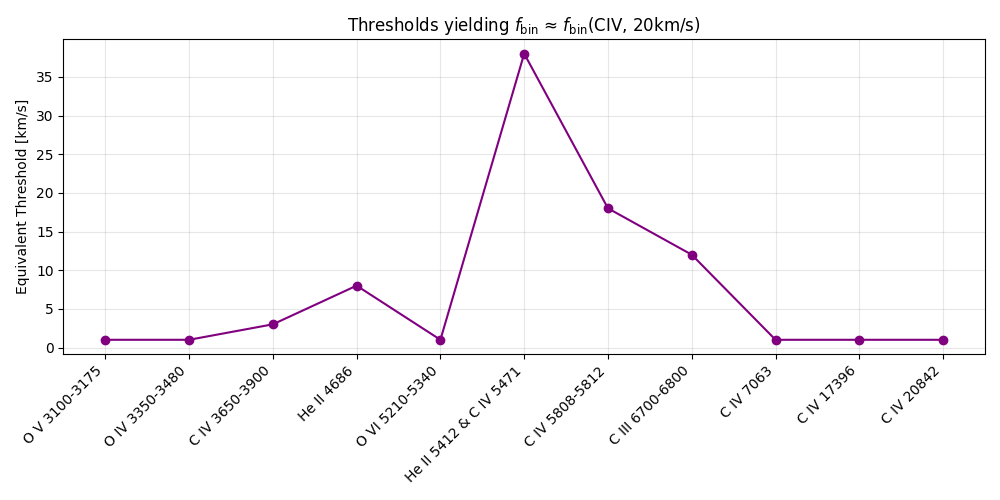

In [27]:
# --- Graph 3: Equivalent Thresholds ---
# This plot compares all lines, so no specific line selector is needed.
def plot_graph_3():
    lines_plot = []
    thresholds_plot = []
    for lk in ordered_lines:
        t = equiv_thresholds_map.get(lk, np.nan)
        lines_plot.append(lk)
        thresholds_plot.append(t)
    if len(lines_plot) > 0:
        plt.figure(figsize=FIGSIZE_THRESH_PLOT)
        plt.plot(lines_plot, thresholds_plot, marker='o', linestyle='-', color='purple')
        plt.xticks(rotation=45, ha='right')
        plt.ylabel("Equivalent Threshold [km/s]")
        plt.title(f"Thresholds yielding $f_{{\mathrm{{bin}}}}$ ≈ $f_{{\mathrm{{bin}}}}$(CIV, 20km/s)")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

plot_graph_3()

### Graph 4 - Corner Plot Matrix

In [25]:
# --- Interactive Graph 4: Corner Plot ---
def plot_graph_4(show_names, use_log, use_equiv):
    # Masking logic
    base = df.copy()[ordered_cols]
    masked = base.copy()
    for col in [c for c in masked.columns if c.startswith("dRV | ")]:
        line_key = col.replace("dRV | ", "")
        for i in range(len(masked)):
            sname = masked.at[i, "Star"]
            if not isinstance(sname, str) or sname == "f_bin": continue
            n_fail, n_cons, frac = ew_fail_stats.get((sname, line_key), (0, 0, 0.0))
            if (n_cons > 0) and (frac > FAIL_FRAC_THRESH):
                masked.at[i, col] = np.nan

    n_lines = len(ordered_lines)
    # Pre-calc ranges
    line_ranges = {}
    for lk in ordered_lines:
        col = f"dRV | {lk}"
        vals = []
        if use_equiv: t_val = equiv_thresholds_map.get(lk, THRESH_KMS)
        else: t_val = THRESH_KMS
        if np.isfinite(t_val): vals.append(t_val)
        if col in masked.columns:
            for i in range(len(masked)):
                sname = masked.at[i, "Star"]
                v = masked.at[i, col]
                if pd.notna(v) and np.isfinite(float(v)): vals.append(float(v))
        
        if not vals: line_ranges[lk] = (0.1, 100); continue
        
        vmin, vmax = min(vals), max(vals)
        if use_log:
            pos_vals = [x for x in vals if x > 0]
            if pos_vals:
                vmin = min(pos_vals)
                log_min, log_max = np.log10(vmin), np.log10(vmax)
                span = log_max - log_min if log_max > log_min else 0.5
                vmin = 10**(log_min - 0.05*span); vmax = 10**(log_max + 0.05*span)
            else: vmin, vmax = 0.1, 100
        else:
            span = vmax - vmin if vmax > vmin else 5.0
            vmin = vmin - 0.05*span; vmax = vmax + 0.05*span
            if vmin < 0: vmin = 0 
        line_ranges[lk] = (vmin, vmax)

    if n_lines > 1:
        dim = max(16, 3 * n_lines)
        fig, axes = plt.subplots(n_lines, n_lines, figsize=(dim, dim), sharex='col')
        plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05, wspace=0, hspace=0)
        if n_lines == 1: axes = np.array([[axes]]) 
        trans_diagonal = mtransforms.Affine2D().rotate_deg(-45)
        
        for i in range(n_lines): 
            line_y_key = ordered_lines[i]
            y_min, y_max = line_ranges.get(line_y_key, (0.1, 100))
            thresh_y = equiv_thresholds_map.get(line_y_key, THRESH_KMS) if use_equiv else THRESH_KMS
            
            for j in range(n_lines):
                ax = axes[i, j]
                line_x_key = ordered_lines[j]
                x_min, x_max = line_ranges.get(line_x_key, (0.1, 100))
                thresh_x = equiv_thresholds_map.get(line_x_key, THRESH_KMS) if use_equiv else THRESH_KMS
                
                if use_log:
                    ax.set_xscale('log')
                    if i != j: ax.set_yscale('log')
                ax.set_xlim(x_min, x_max)
                if i != j: ax.set_ylim(y_min, y_max)
                if i < n_lines - 1: ax.tick_params(axis='x', labelbottom=False, length=0)
                if j > 0: ax.tick_params(axis='y', labelleft=False, length=0) 
                
                if j > i: ax.axis('off'); continue
                
                # Diagonal
                if i == j:
                    col_name = f"dRV | {line_y_key}"
                    if col_name in masked.columns:
                        vals_hist = [float(masked.at[k, col_name]) for k in range(len(masked)) if pd.notna(masked.at[k, col_name])]
                        if len(vals_hist) > 0:
                            if use_log:
                                hv_min = max(x_min, min([v for v in vals_hist if v > 0]) if any(v>0 for v in vals_hist) else x_min)
                                hv_max = max(x_max, max(vals_hist))
                                bins = np.geomspace(hv_min, hv_max, 15)
                            else: bins = 15
                            ax.hist(vals_hist, bins=bins, color='gray', alpha=0.7, histtype='stepfilled', edgecolor='black')
                    ax.yaxis.set_visible(False) 
                    continue
                
                # Scatter
                x_vals, y_vals, x_errs, y_errs, c_tl, c_br, names = [], [], [], [], [], [], []
                col_x = f"dRV | {line_x_key}"; col_y = f"dRV | {line_y_key}"
                
                if (col_x in masked.columns) and (col_y in masked.columns):
                    for idx in range(len(masked)):
                        vx = masked.at[idx, col_x]; vy = masked.at[idx, col_y]
                        if pd.notna(vx) and pd.notna(vy):
                            vx = float(vx); vy = float(vy)
                            if use_log and (vx <= 0 or vy <= 0): continue
                            x_vals.append(vx); y_vals.append(vy)
                            sname = masked.at[idx, "Star"]
                            names.append(sname)
                            err_x = drverr_map.get((sname, line_x_key), 0); x_errs.append(err_x if np.isfinite(err_x) else 0)
                            err_y = drverr_map.get((sname, line_y_key), 0); y_errs.append(err_y if np.isfinite(err_y) else 0)
                            c_tl.append('green' if _is_significant_binary(sname, line_y_key, vy, thresh_y) else 'red')
                            c_br.append('green' if _is_significant_binary(sname, line_x_key, vx, thresh_x) else 'red')

                if len(x_vals) > 0:
                    x_arr = np.array(x_vals); y_arr = np.array(y_vals)
                    x_err_arr = np.array(x_errs); y_err_arr = np.array(y_errs)
                    
                    ax.axvline(thresh_x, color='black', linestyle=':', alpha=0.6, linewidth=1)
                    ax.axhline(thresh_y, color='black', linestyle=':', alpha=0.6, linewidth=1)
                    diag_min = max(x_min, y_min); diag_max = min(x_max, y_max)
                    ax.plot([diag_min, diag_max], [diag_min, diag_max], ls='--', color='gray', alpha=0.5, linewidth=1, zorder=0)

                    ax.hlines(y_arr, x_arr - x_err_arr, x_arr + x_err_arr, colors=c_br, lw=0.8, zorder=1)
                    ax.vlines(x_arr, y_arr - y_err_arr, y_arr + y_err_arr, colors=c_tl, lw=0.8, zorder=1)
                    ax.scatter(x_vals, y_vals, c=c_br, marker=MarkerStyle('o', fillstyle='right', transform=trans_diagonal), s=80, edgecolors='black', linewidth=0.5, zorder=2)
                    ax.scatter(x_vals, y_vals, c=c_tl, marker=MarkerStyle('o', fillstyle='left', transform=trans_diagonal), s=80, edgecolors='black', linewidth=0.5, zorder=3)
                    
                    if len(x_vals) > 1:
                        r_val, p_val = pearsonr(x_vals, y_vals)
                        ax.text(0.05, 0.85, f"r={r_val:.2f}\np={p_val:.2g}\nn={len(x_vals)}", transform=ax.transAxes, fontsize=8, verticalalignment='top', bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.8))

                    if show_names:
                        for k, nm in enumerate(names):
                            ax.text(x_vals[k], y_vals[k], nm, fontsize=8, alpha=0.8, clip_on=True, rotation=25)
                ax.grid(True, alpha=0.2, which='both')
                
        for i in range(n_lines):
            if i > 0: axes[i, 0].set_ylabel(ordered_lines[i], fontsize=10, rotation=90)
            axes[n_lines-1, i].set_xlabel(ordered_lines[i], fontsize=10)
        plt.show()

# Widgets
ui_names = widgets.Checkbox(value=False, description='Show Names')
ui_log = widgets.Checkbox(value=True, description='Log Scale')
ui_equiv_4 = widgets.Checkbox(value=False, description='Use Equiv Thresh')

ui_4 = widgets.HBox([ui_log, ui_names, ui_equiv_4])
# FIXED: interactive_output
out_4 = widgets.interactive_output(plot_graph_4, {'show_names': ui_names, 'use_log': ui_log, 'use_equiv': ui_equiv_4})
display(ui_4, out_4)

Output()

### Graph 5 - Agreement Ranking

In [28]:
# --- Interactive Graph 5: Agreement ---
# Helper to get fbin string
def _get_fbin_simple_local(base_with, line_key, use_equiv_thresh):
    colname = f"dRV | {line_key}"
    if colname not in base_with.columns: return "—"
    thresh_to_use = THRESH_KMS
    if use_equiv_thresh:
        t = equiv_thresholds_map.get(line_key, THRESH_KMS)
        if np.isfinite(t): thresh_to_use = t

    vals = base_with[colname]
    idx_with_drv = []
    for i in range(0, len(base_with)):
        star_name = base_with.at[i, "Star"]
        if not isinstance(star_name, str) or star_name == "f_bin": continue
        _, _, frac = ew_fail_stats.get((star_name, line_key), (0, 0, 0.0))
        if frac > FAIL_FRAC_THRESH: continue
        try:
            v = vals.iat[i]
            if pd.notna(v) and np.isfinite(float(v)): idx_with_drv.append(i)
        except Exception: pass

    n_total = len(idx_with_drv)
    if n_total == 0: return "0/0 (—)"
    n_above = 0
    for i in idx_with_drv:
        star_name = base_with.at[i, "Star"]
        dval = float(vals.iat[i])
        if _is_significant_binary(star_name, line_key, dval, thresh_to_use): n_above += 1
    n_total_adj = n_total + EXTRA_ABOVE
    n_above_adj = n_above + EXTRA_ABOVE
    frac_adj = n_above_adj / n_total_adj
    return f"{n_above_adj}/{n_total_adj} ({frac_adj:.0%})"

def plot_graph_5(show_friends, use_equiv):
    # Prepare Masked DF
    base = df.copy()[ordered_cols]
    masked = base.copy()
    for col in [c for c in masked.columns if c.startswith("dRV | ")]:
        line_key = col.replace("dRV | ", "")
        for i in range(len(masked)):
            sname = masked.at[i, "Star"]
            if not isinstance(sname, str) or sname == "f_bin": continue
            n_fail, n_cons, frac = ew_fail_stats.get((sname, line_key), (0, 0, 0.0))
            if (n_cons > 0) and (frac > FAIL_FRAC_THRESH):
                masked.at[i, col] = np.nan

    drv_cols = [f"dRV | {lk}" for lk in ordered_lines if f"dRV | {lk}" in masked.columns]
    
    if len(drv_cols) > 1:
        cols_names = [c for c in drv_cols]
        adj_corr_df = pd.DataFrame(np.nan, index=cols_names, columns=cols_names)
        adj_pval_df = pd.DataFrame(np.nan, index=cols_names, columns=cols_names)
        adj_n_df    = pd.DataFrame(np.nan, index=cols_names, columns=cols_names)
        
        for i, c1 in enumerate(cols_names):
            data1 = masked[c1]
            for j, c2 in enumerate(cols_names):
                if i == j: continue 
                data2 = masked[c2]
                valid = data1.notna() & data2.notna()
                n_dots = valid.sum()
                if n_dots < MIN_STARS_FOR_CORR: 
                    adj_corr_df.at[c1, c2] = np.nan
                    adj_pval_df.at[c1, c2] = np.nan
                    adj_n_df.at[c1, c2] = np.nan
                else:
                    r, p = pearsonr(data1[valid], data2[valid])
                    adj_corr_df.at[c1, c2] = r; adj_pval_df.at[c1, c2] = p; adj_n_df.at[c1, c2] = n_dots
        
        w_df = adj_n_df / MAX_POSSIBLE_STARS
        r_weighted_terms = adj_corr_df * w_df
        avg_scores_user = r_weighted_terms.sum(axis=1) / r_weighted_terms.count(axis=1)
        
        p_times_n = adj_pval_df * adj_n_df
        sum_n = adj_n_df.sum(axis=1)
        avg_pvals_std_weighted = p_times_n.sum(axis=1) / sum_n.replace(0, np.nan)

        best_friends, best_scores, second_best_friends, second_best_scores, stats_texts = [], [], [], [], []
        
        for idx_row, col in enumerate(cols_names):
            line_nm = col.replace("dRV | ", "")
            row_series = adj_corr_df.loc[col].sort_values(ascending=False)
            valid_friends = row_series.dropna()
            
            def _fmt_friend(friend_col, r_val):
                v = (masked[col].notna() & masked[friend_col].notna())
                n_count = v.sum()
                if n_count < 2: return "Err", np.nan
                _, p_val = pearsonr(masked[col][v], masked[friend_col][v])
                nm = friend_col.replace("dRV | ", "")
                return f"{nm}\nr={r_val:.2f} (p={p_val:.2g}, n={n_count})", r_val

            if len(valid_friends) > 0: b_lbl, b_val = _fmt_friend(valid_friends.index[0], valid_friends.iloc[0])
            else: b_val, b_lbl = np.nan, "None"

            if len(valid_friends) > 1: s_lbl, s_val = _fmt_friend(valid_friends.index[1], valid_friends.iloc[1])
            else: s_val, s_lbl = np.nan, ""
            
            best_scores.append(b_val); best_friends.append(b_lbl)
            second_best_scores.append(s_val); second_best_friends.append(s_lbl)
            
            fbin_txt = _get_fbin_simple_local(masked, line_nm, use_equiv)
            ew_succ, ew_mn, ew_sem = _calc_ew_stats_for_line(line_nm)
            stat_blk = (r"$f_{\mathrm{bin}}$: " + f"{fbin_txt}\n" + f"EW%: {ew_succ:.0%}\n" + f"EW: {ew_mn:.2f}±{ew_sem:.2f}")
            stats_texts.append(stat_blk)

        plot_data = pd.DataFrame({
            "Line": [c.replace("dRV | ", "") for c in cols_names],
            "Score": avg_scores_user.values,
            "Avg_P_Weighted": avg_pvals_std_weighted.values,
            "Best_Score": best_scores, "Best_Friend": best_friends,
            "Second_Score": second_best_scores, "Second_Friend": second_best_friends,
            "Stats": stats_texts
        }).sort_values("Score", ascending=False, na_position='last').reset_index(drop=True)
        
        plt.figure(figsize=FIGSIZE_AGREEMENT)
        valid_plot = plot_data.dropna(subset=["Score"])
        if not valid_plot.empty:
            plt.plot(valid_plot.index, valid_plot["Score"], marker='o', linestyle='-', color='teal', linewidth=2, markersize=8, label=f"Avg Score")
        
        if show_friends:
            plt.scatter(plot_data.index, plot_data["Best_Score"], color='orange', s=80, marker='D', zorder=3, label="Max Corr")
            plt.scatter(plot_data.index, plot_data["Second_Score"], color='lightgreen', s=70, marker='s', edgecolors='green', zorder=2, label="2nd Best")
        
        plt.xticks(plot_data.index, plot_data["Line"], rotation=45, ha="right")
        plt.ylabel("Agreement Score")
        plt.title(f"Agreement Ranking (Logic: r * n/25, N >= {MIN_STARS_FOR_CORR})")
        plt.grid(True, alpha=0.3, linestyle='--')
        
        for i in plot_data.index:
            score = plot_data.at[i, "Score"]
            avg_p_w = plot_data.at[i, "Avg_P_Weighted"]
            stat_txt = plot_data.at[i, "Stats"]
            if pd.notna(score):
                p_text = f"(p_w={avg_p_w:.2g})" if pd.notna(avg_p_w) else ""
                plt.text(i, score - 0.02, f"{score:.3f}\n{p_text}", ha='center', va='top', fontsize=9, color='teal', fontweight='bold')
            if show_friends:
                if pd.notna(plot_data.at[i, "Best_Score"]):
                    plt.text(i, plot_data.at[i, "Best_Score"] + 0.01, plot_data.at[i, "Best_Friend"], ha='center', va='bottom', fontsize=8, color='darkorange', rotation=25)
                if pd.notna(plot_data.at[i, "Second_Score"]):
                    plt.text(i, plot_data.at[i, "Second_Score"] - 0.01, plot_data.at[i, "Second_Friend"], ha='center', va='top', fontsize=8, color='green', rotation=25)
            
            ylim_min, ylim_max = plt.ylim()
            y_txt_pos = ylim_min + (ylim_max - ylim_min) * 0.05
            plt.text(i, y_txt_pos, stat_txt, ha='center', va='bottom', fontsize=7, bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="gray", alpha=0.7))

        plt.legend(loc='upper right')
        plt.tight_layout()
        plt.show()

# Widgets
ui_friends = widgets.Checkbox(value=True, description='Show Correlation Info')
ui_equiv_5 = widgets.Checkbox(value=False, description='Use Equiv Thresh')

ui_5 = widgets.HBox([ui_friends, ui_equiv_5])
# FIXED: interactive_output
out_5 = widgets.interactive_output(plot_graph_5, {'show_friends': ui_friends, 'use_equiv': ui_equiv_5})
display(ui_5, out_5)

Output()

### Graph 6 - Binary Fraction per Line

### Confidence Grading & Binarity Pie Charts

## showing the final results with errors and fraction on the nice background of a normalized spectra

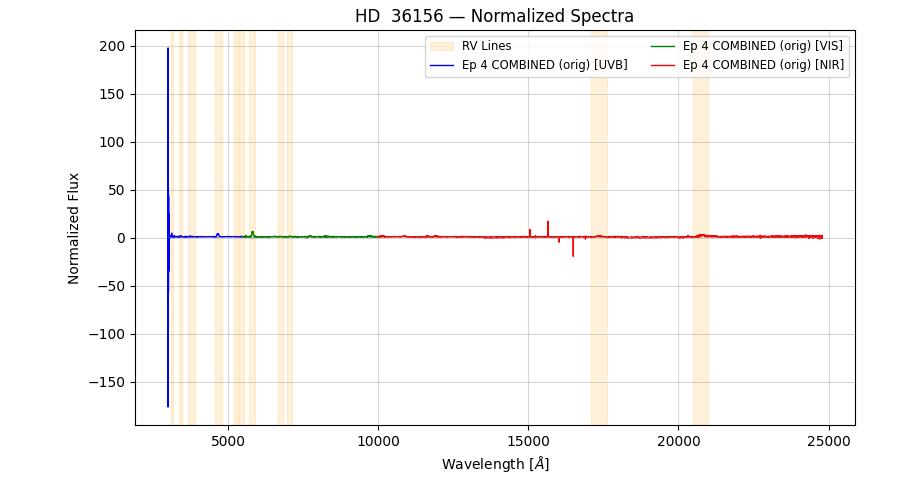

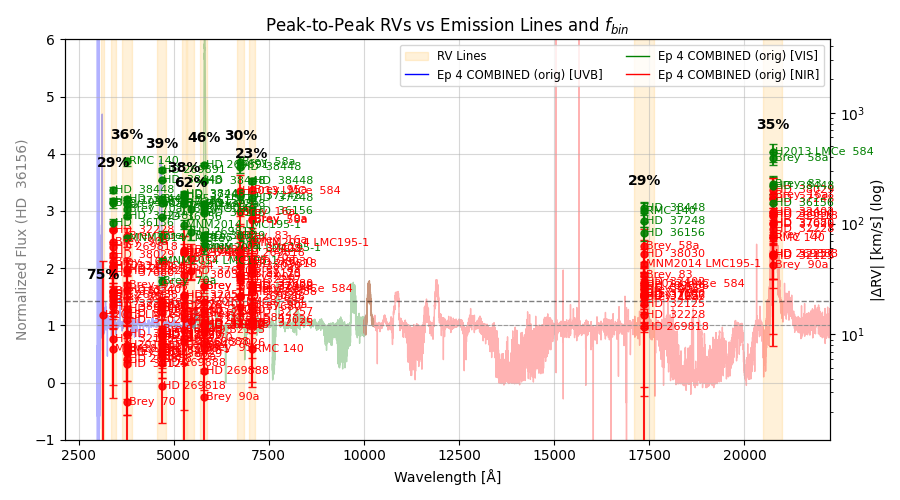

In [8]:
%matplotlib widget
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from itertools import cycle

# ----------------------------------------------------------------------
#  1. SETUP & CONFIG
# ----------------------------------------------------------------------
SETTINGS_PATH = "ccf_settings_with_global_lines.json"
try:
    with open(SETTINGS_PATH, "r") as f:
        SETTINGS = json.load(f)
except FileNotFoundError:
    SETTINGS = {}

STAR_CFG = {s["star_name"]: s for s in SETTINGS.get("stars", [])}
LINES_DEFAULT = SETTINGS.get("emission_lines_default", {}) 

# Analysis Constants
THRESH_KMS = 20.0
EXTRA_ABOVE = 3
FAIL_FRAC_THRESH = 0.40
KNOWN_ERR_KEYS = ("full_RV_err", "full_err", "sigma", "err", "RV_err", "RV_sigma")

# Plotting Constants
line_centre = {tag: 10.0 * np.mean(rng) for tag, rng in LINES_DEFAULT.items()}
epoch_ew_data = {}        
ew_fail_stats = {}   
drverr_map = {} 

# ----------------------------------------------------------------------
#  2. DATA PROCESSING HELPERS
# ----------------------------------------------------------------------

def _extract_full_rv(cell):
    try:
        if isinstance(cell, dict): return cell.get('full_RV', None)
        if hasattr(cell, "item"):
            v = cell.item()
            if isinstance(v, dict): return v.get('full_RV', None)
        if hasattr(cell, "get"): return cell.get('full_RV', None)
    except Exception: pass
    return None

def _extract_full_rv_err(cell):
    try:
        if isinstance(cell, dict):
            for k in KNOWN_ERR_KEYS:
                if k in cell and cell[k] is not None: return float(cell[k])
        if hasattr(cell, "item"):
            v = cell.item()
            if isinstance(v, dict):
                for k in KNOWN_ERR_KEYS:
                    if k in v and v[k] is not None: return float(v[k])
        if hasattr(cell, "get"):
            for k in KNOWN_ERR_KEYS:
                val = cell.get(k, None)
                if val is not None: return float(val)
    except Exception: pass
    return np.nan

def _is_epoch_skipped_for_line(star_name, line_key, ep):
    cfg = STAR_CFG.get(star_name, {})
    if ep in set(cfg.get("skip_epochs", [])): return True
    sl = cfg.get("skip_emission_lines", {})
    if line_key in sl:
        skip_eps = sl[line_key]
        if isinstance(skip_eps, (int, np.integer)): skip_eps = [skip_eps]
        if 0 in skip_eps or ep in skip_eps: return True
    return False

def _ew_record_for(star, epoch_num, line_key):
    try: EWs = star.load_property('EWs', epoch_num, 'COMBINED')
    except Exception: return None
    if EWs is None: return None
    rec = EWs.get(line_key)
    if rec is None: return None
    if hasattr(rec, 'item'): rec = rec.item()
    if not isinstance(rec, dict): return None
    return {"detected": rec.get("detected")}

def _compute_ew_fail_stats(star, line_key):
    sname = star.star_name
    considered = []
    failed = 0
    for ep in star.get_all_epoch_numbers():
        if _is_epoch_skipped_for_line(sname, line_key, ep): continue
        considered.append(ep)
        rec = _ew_record_for(star, ep, line_key)
        if rec and rec.get("detected") is False:
            failed += 1
    n_considered = len(considered)
    frac = (failed / n_considered) if n_considered > 0 else 0.0
    return failed, n_considered, frac

def _line_delta_rv_for_star(star, line_key):
    rv_vals = []
    sname = star.star_name
    for ep in star.get_all_epoch_numbers():
        if _is_epoch_skipped_for_line(sname, line_key, ep): continue
        RVs = star.load_property('RVs', ep, 'COMBINED')
        if not RVs or line_key not in RVs: continue
        cell = RVs[line_key]
        rv = _extract_full_rv(cell)
        if rv is None: continue
        try: rv = float(rv)
        except Exception: continue
        err = _extract_full_rv_err(cell)
        rv_vals.append((ep, rv, err))

    if len(rv_vals) < 2:
        drverr_map[(sname, line_key)] = np.nan
        return np.nan, np.nan

    t_min = min(rv_vals, key=lambda t: t[1])
    t_max = max(rv_vals, key=lambda t: t[1])
    dRV = abs(t_max[1] - t_min[1])
    if dRV <= 0: dRV = 1e-3

    if np.isfinite(t_min[2]) and np.isfinite(t_max[2]):
        sigma_A = float(np.sqrt(t_min[2]**2 + t_max[2]**2))
    else:
        sigma_A = np.nan

    drverr_map[(sname, line_key)] = sigma_A
    return dRV, sigma_A

def _is_significant_binary(star_name, line_key, drv_val):
    if not (pd.notna(drv_val) and np.isfinite(drv_val)): return False
    sigma_A = drverr_map.get((star_name, line_key), np.nan)
    if not np.isfinite(sigma_A): return False
    return (float(drv_val) >= THRESH_KMS) and ((float(drv_val) - THRESH_KMS) >= 4.0 * float(sigma_A))

# ----------------------------------------------------------------------
#  3. MAIN PROCESSING
# ----------------------------------------------------------------------
records = []
target_list = list(STAR_CFG.keys())
ordered_lines = list(LINES_DEFAULT.keys())

for star_name in target_list:
    try:
        star = obs.load_star_instance(star_name, to_print=False)
    except Exception: continue
    
    for lk in ordered_lines:
        _, _, fail_frac = _compute_ew_fail_stats(star, lk)
        if fail_frac > FAIL_FRAC_THRESH: continue

        dRV, dRV_err = _line_delta_rv_for_star(star, lk)
        if pd.isna(dRV): continue
        
        is_bin = _is_significant_binary(star_name, lk, dRV)
        records.append({
            'star': star_name, 'emission': lk, 'λ_Å': line_centre.get(lk, np.nan),
            'ΔRV_km_s': dRV, 'ΔRV_err': dRV_err, 'is_binary': is_bin
        })

df = pd.DataFrame(records)

# ----------------------------------------------------------------------
#  4. PLOTTING
# ----------------------------------------------------------------------
try:
    s16_name = target_list[16] if len(target_list) > 16 else target_list[0]
    s16 = obs.load_star_instance(s16_name)
    s16.plot_normalized_spectra(bands='COMBINED', compare=False, separation=0, bin_window=0,
                                bary_correction=False, epoch_nums=[4], add_RV_emission_lines=True,
                                color_combined=True, add_continuum=True)
    ax_spec = plt.gca()
    
    # --- TITLE FIX: Clear the auto-generated title immediately ---
    ax_spec.set_title("")

    # Unit Fix (nm -> Å)
    lines = ax_spec.get_lines()
    unit_fixed = False
    for line in lines:
        x_data = line.get_xdata()
        if len(x_data) > 0 and np.max(x_data) < 3000:
            line.set_xdata(x_data * 10.0)
            unit_fixed = True
    if unit_fixed:
        ax_spec.relim(); ax_spec.autoscale_view()
        
    ax_spec.set_ylim(-1, 6)
    ax_spec.set_ylabel(f"Normalized Flux ({s16_name})", color='gray')
    ax_spec.set_xlabel("Wavelength [Å]")
    for line in lines:
        line.set_alpha(0.3); line.set_zorder(0)
except Exception:
    fig, ax_spec = plt.subplots(figsize=(14,8)); ax_spec.set_ylim(-1, 6)
    ax_spec.set_title("")

# --- Foreground RVs ---
ax_rv = ax_spec.twinx()
ax_rv.set_yscale('log')

for _, row in df.iterrows():
    x, y, yerr, star = row['λ_Å'], row['ΔRV_km_s'], row['ΔRV_err'], row['star']
    c = 'green' if row['is_binary'] else 'red'
    ax_rv.errorbar(x, y, yerr=yerr, fmt='o', color=c, ecolor=c, 
                   elinewidth=1.5, capsize=3, alpha=0.9, zorder=10, ms=5)
    ax_rv.text(x + 50, y, star, fontsize=8, color=c, ha='left', va='center', zorder=11)

ax_rv.axhline(THRESH_KMS, ls='--', lw=1, color='black', alpha=0.5)

# --- Stats & Labels ---
frac_dict = {}
for tag, grp in df.groupby('emission'):
    stars_this_line = grp['star'].unique()
    binary_stars = grp.loc[grp['is_binary'] == True, 'star'].unique()
    n_above = len(binary_stars)
    n_total = len(stars_this_line)
    frac = (n_above + EXTRA_ABOVE) / (n_total + EXTRA_ABOVE) if n_total else 0
    frac_dict[tag] = frac

if not df.empty:
    rv_min, rv_max = df['ΔRV_km_s'].min(), df['ΔRV_km_s'].max()
    log_min, log_max = np.log10(rv_min), np.log10(rv_max)
    pad = (log_max - log_min) * 0.15
    ax_rv.set_ylim(10**(log_min - pad), 10**(log_max + pad * 3))

for tag, frac in frac_dict.items():
    if tag not in line_centre: continue
    x = line_centre[tag]
    col_max = df[df['emission'] == tag]['ΔRV_km_s'].max()
    y_text = max(col_max, THRESH_KMS) * 1.5
    ax_rv.text(x, y_text, f"{frac*100:.0f}%", ha='center', va='bottom', 
               fontsize=10, fontweight='bold', color='black', zorder=12)

all_centers = list(line_centre.values())
if all_centers: ax_spec.set_xlim(min(all_centers)-1000, max(all_centers)+1500)

ax_rv.set_ylabel("|ΔRV| [km/s] (log)", fontsize=10)
# This title will now be the ONLY one
ax_rv.set_title("Peak-to-Peak RVs vs Emission Lines and $f_{bin}$")

plt.tight_layout()
plt.show()

# Plotting the normalized flux when trying to take the 2D image and throw the top and bottom panes, sun along the vertical axis and normalized using what I chose for the 1D flux. And comparing to my normalization

In [2]:
obs = obsm()
star_name = specs.star_names[12]
print(star_name)
star = obs.load_star_instance(star_name)
epoch_num = 4

Brey  58a


In [6]:
data = []
for star_name in specs.star_names:
    star = obs.load_star_instance(star_name)
    data.append([star_name])

df = pd.DataFrame(data, columns=["Star Name"])
print(df)

           Star Name
0           Brey  70
1           Brey  83
2          HD  38029
3          HD  37248
4          Brey  95a
5   MNM2014 LMC195-1
6          HD  32125
7          HD  37026
8          HD 269818
9          HD  38448
10         HD  38030
11         HD  37680
12         Brey  58a
13         HD  32228
14         HD  32257
15         HD 269888
16         HD  36156
17   H2013 LMCe  584
18           RMC 140
19         HD  32402
20         Brey  70a
21         Brey  16a
22          Brey  93
23         Brey  90a
24         HD 269891


In [ ]:
%matplotlib widget
obs = obsm()
star_name = specs.star_names[0]
star = obs.load_star_instance(star_name)
try:
    for epoch_num in range(1,8):
        for band in ['UVB','VIS','NIR']:
            star.clean_flux_and_normalize_interactive(epoch_num,band)

In [19]:
%matplotlib widget
star.clean_flux_and_normalize(epoch_num,'VIS')

Data/Brey  58a/epoch4/VIS/2D image/ADP.2021-09-20T20:03:20.595.fits
Data loaded from Data/Brey  58a/epoch4/VIS/2D image/ADP.2021-09-20T20:03:20.595.fits
Data/Brey  58a/epoch4/VIS/ADP.2021-09-20T20_03_20.594.fits
Data loaded from Data/Brey  58a/epoch4/VIS/ADP.2021-09-20T20_03_20.594.fits
The top lines is: -30, and the bottom line is: -68
 anchor_points_in_range: [538.34 567.54 606.62 650.3  747.8  808.78 872.5  892.58 995.48]
found points from wavelngth_2D: [538.34 567.54 606.62 650.3  747.8  808.78 872.5  892.58 995.48]


ValueError: operands could not be broadcast together with shapes (38,) (24318,) 

Data/Brey  83/epoch2/NIR/2D image/ADP.2020-12-07T08:55:14.104.fits
Data loaded from Data/Brey  83/epoch2/NIR/2D image/ADP.2020-12-07T08:55:14.104.fits
Data/Brey  83/epoch2/NIR/ADP.2020-12-07T08_55_14.103.fits
Data loaded from Data/Brey  83/epoch2/NIR/ADP.2020-12-07T08_55_14.103.fits
The top lines is: -24, and the bottom line is: -52
 anchor_points_in_range: [1032.3  1042.62 1068.66 1224.36 1295.94 1534.5  1562.1  1592.1  1626.18
 1660.68 1715.34 1772.04 1987.62 2037.36 2153.76 2187.12 2208.42 2250.
 2305.86 2395.02 2477.4 ]
found points from wavelngth_2D: [1032.3  1042.62 1068.66 1224.36 1295.94 1534.5  1562.1  1592.1  1626.18
 1660.68 1715.34 1772.04 1987.62 2037.36 2153.76 2187.12 2208.42 2250.
 2305.86 2395.02 2477.4 ]


/Users/guyshtainer/Library/CloudStorage/OneDrive-mail.tau.ac.il/תואר שני!/Thesis/Thesis-codes/StarClass.py:1640: RuntimeWarning: invalid value encountered in divide
  relative_difference = flux_difference / external_normalized_flux_band


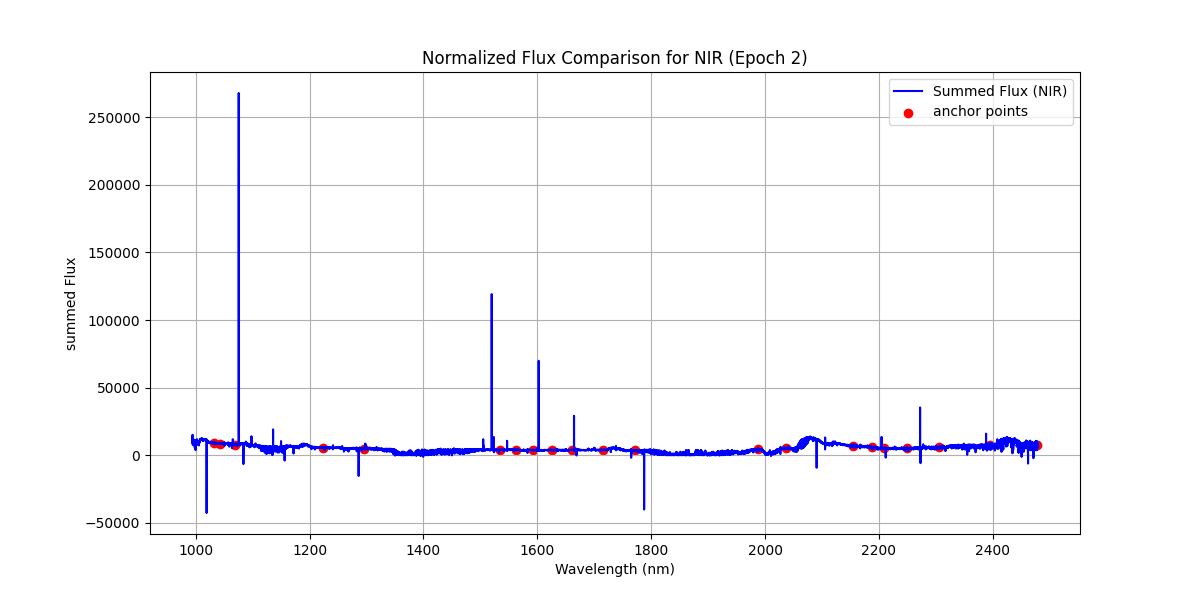

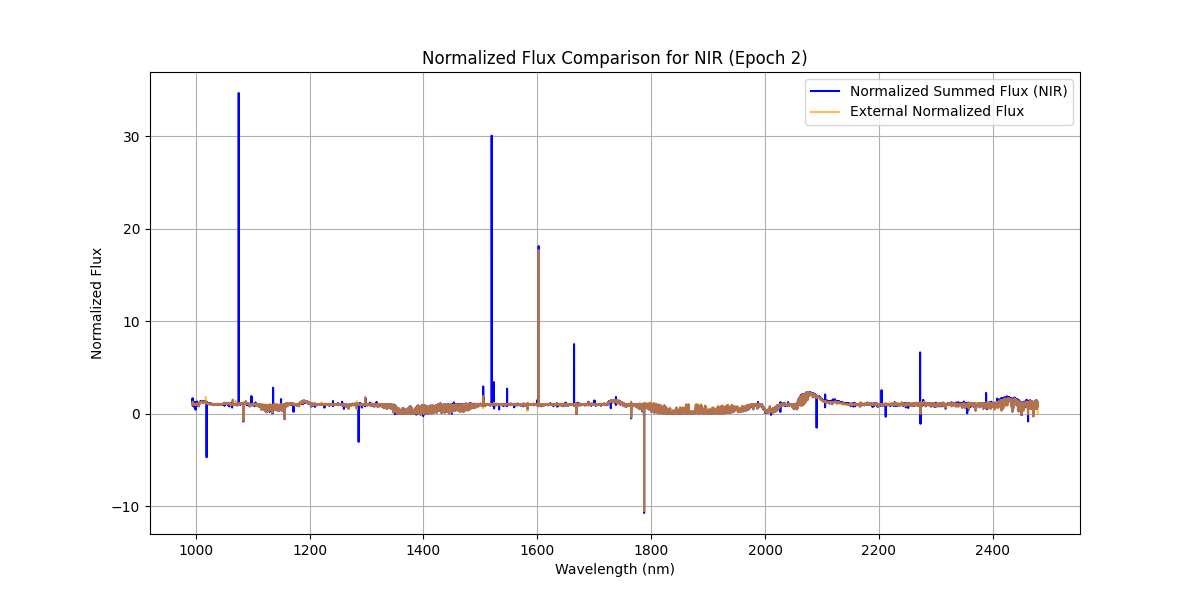

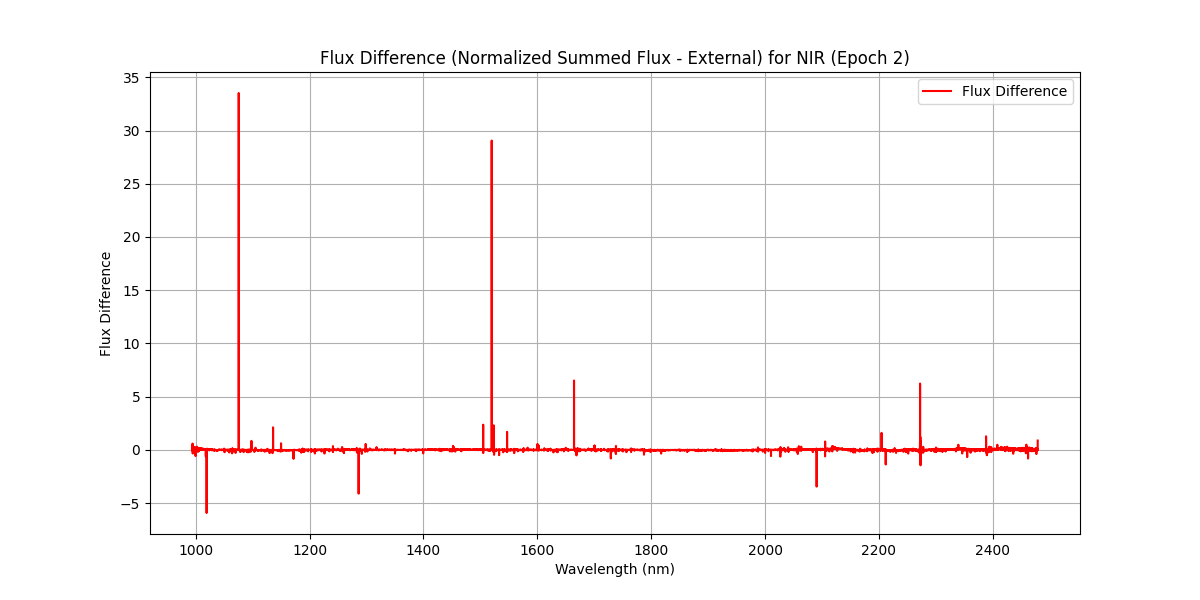

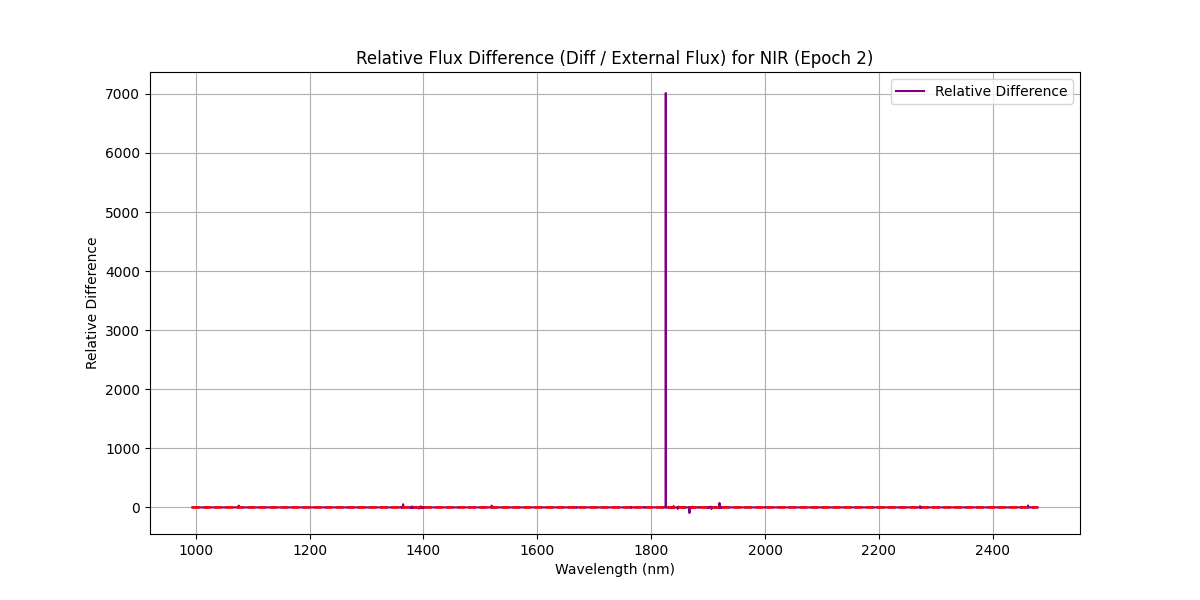

(array([1.16068533, 1.27398004, 1.38727474, ..., 0.91448187, 0.88017143,
        0.87559338]),
 array([ 994.02,  994.04,  994.06, ..., 2478.84, 2478.9 , 2478.96],
       dtype='>f8'),
 (-52, -24))

In [5]:
%matplotlib widget
star.clean_flux_and_normalize(epoch_num,'NIR')